### IMMUN 306QC Python Bootcamp / Session 3
# Math and plotting with NumPy and Matplotlib
*Ralph Estanboulieh (2026)*

*This notebook was created **without** the use of AI.*

In the last session we learned about reading and handling tabular data using Panda's, Python's flagship data wrangling library. In this session, we first explore NumPy, Python's fundamental math and linear algebra library, and then look at how data can be visualized in Python with Matplotlib. 

## Basic math with NumPy

Now that we can read and clean numerical data, we need a way to do advanced calculations with it. However, while Python lists and dictionaries can be useful at storing data, doing math with them is highly inefficient. NumPy, which stands for numerical Python, is an extremely popular and widely used open-source library that can help us do just that, and then some, like generating random numbers. You might point out that Pandas already has efficient numerical capabilities, but those are actually all built off of NumPy.

As always, I recommend you browse through the [NumPy docs](https://numpy.org/doc/stable/user/absolute_beginners.html) to familiarize yourself with its powerful features. Another very helpful resource (especially for visual learners) is [The Visual Guide to NumPy](https://medium.com/better-programming/numpy-illustrated-the-visual-guide-to-numpy-3b1d4976de1d) by Lex Maximov.

First, let's import it.

In [2]:
import numpy as np
print(np.__version__) # version should be > 2.5

2.5.3


In [932]:
import pandas as pd

### The NumPy array

The cornerstone of NumPy is the array. NumPy Arrays can surprisingly contain up to 32 dimensions! Hopefully, you will only need to deal with one-, two-, and very rarely three-dimensional ones in the vast majority of applications. 

There are many ways to create an array, the most basic of which is to start with a simple list and feed it to `np.array()` to create a **one-dimensional** array:

In [18]:
a1 = np.array([1,2,3,4,5,6,7])
a1

array([1, 2, 3, 4, 5, 6, 7])

If we wish to create a two-dimensional array, we can use a list of lists:

In [73]:
a2 = np.array(
    [[1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16],
    [17, 18, 19, 20]]
)
a2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

And if we stack 2D arrays into an array, we can get a 3D array! (Notice the triple brackets!)

In [74]:
a3 = np.array([a2,a2,a2])
a3

array([[[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]],

       [[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]],

       [[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16],
        [17, 18, 19, 20]]])

### Array attributes

Attributes are constant values that are properites of an object/class and can be accessed via the dot notation. Important attributes of an array include:

1) `ndim`: the number of dimensions

In [75]:
for a in [a1,a2,a3]:
    print(a.ndim)

1
2
3


2) `shape`: The shape of the array, the number of elements along each dimension (for 2D, it's `nrows, ncols`)

In [76]:
for a in [a1,a2,a3]:
    print(a.shape)

(7,)
(5, 4)
(3, 5, 4)


3) `size`: the total number of elements in the array

In [77]:
for a in [a1,a2,a3]:
    print(a.size)

7
20
60


4) `dtype`: the type of the data in the array, which mimics the `dtypes` attribute of a Pandas DataFrame. (Usually, arraus are **homogeneous**, meaning they can only contain one data type.)

In [78]:
for a in [a1,a2,a3]:
    print(a.dtype)

int64
int64
int64


### Functions that create basic arrays

NumPy has other ways of creating arrays:

1) `np.zeros()`: returns an array of zeros with a given shape

In [79]:
np.zeros((3,7)) # try changing the shape!

array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.]])

2) `np.ones()`: returns an array of ones with a given shape

In [80]:
np.ones((3,2,4))

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

3) `np.arange()`: extremely useful, is the NumPy equivalent of Python's `range()`, creates a range of numbers given `(start, stop, step)`

In [81]:
print(np.arange(12))
print(np.arange(3, 12))
print(np.arange(1, 30, 2))

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 3  4  5  6  7  8  9 10 11]
[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]


4) `np.linspace()`: creates an array of values that are linearly interspaced between two given (and included) boundary values

In [82]:
np.linspace(3, 10, num=5)

array([ 3.  ,  4.75,  6.5 ,  8.25, 10.  ])

5) `np.eye`: creates the identity matrix given the length of the diagonal

In [83]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [84]:
np.eye(3,5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [86]:
np.eye(8,k=3) # try negative k

array([[0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

### Indexing and slicing NumPy arrays

<center><img src="figures/np_indexing.png"></center>

Indexing (accessing individual elements) and slicing (viewing slices) NumPy arrays is (almost) as simple as indexing and slicing basic Python lists. For 1D array, it is the same:

In [87]:
print(a1)
print(a1[2]) # 3rd element
print(a1[:4]) # first 4 elements
print(a1[3:]) # elements after (and including) 4th element
print(a1[2:6]) # 3rd to 6th elements
print(a1[0:7:2]) # start 0, end 7, step 2 (every other element)
print(a1[::3]) # every 3rd element
print(a1[::-1]) # every element, reversed
print(a1[4::-1]) # reversed, starting from 5th element

[1 2 3 4 5 6 7]
3
[1 2 3 4]
[4 5 6 7]
[3 4 5 6]
[1 3 5 7]
[1 4 7]
[7 6 5 4 3 2 1]
[5 4 3 2 1]


For 2D arrays, it's the same, except we first index/slice the rows, then the columns:

In [114]:
print(a2)
print(f"> a2[2]\n{a2[2]}") # 3rd row
print(f"> a2[2, :]\n{a2[2, :]}") # also 3rd row
print(f"> a2[2:4]\n{a2[2:4]}") 
print(f"> a2[1:3]\n{a2[1:3]}") 
print(f"> a2[3,2]\n{a2[3, 2]}") # 4th row, 3rd column
print(f"> a2[:, 1]\n{a2[:, 1]}") # 2nd column
print(f"> a2[:, :3]\n{a2[:, :3]}") # first 3 columns
print(f"> a2[1:-1, 1:-1]\n{a2[1:-1, 1:-1]}") # middle sub-matrix
print(f"> a2[::2, ::2]\n{a2[::2, ::2]}") # every other element in both dimesions

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]
> a2[2]
[ 9 10 11 12]
> a2[2, :]
[ 9 10 11 12]
> a2[2:4]
[[ 9 10 11 12]
 [13 14 15 16]]
> a2[1:3]
[[ 5  6  7  8]
 [ 9 10 11 12]]
> a2[3,2]
15
> a2[:, 1]
[ 2  6 10 14 18]
> a2[:, :3]
[[ 1  2  3]
 [ 5  6  7]
 [ 9 10 11]
 [13 14 15]
 [17 18 19]]
> a2[1:-1, 1:-1]
[[ 6  7]
 [10 11]
 [14 15]]
> a2[::2, ::2]
[[ 1  3]
 [ 9 11]
 [17 19]]


Note: indexing and slicing arrays returns a **non-copy view** of the sliced array, which means that altering the view will alter the original array. If you wish to only alter the array slice without affecting the original array, copy the slice using `.copy()`. 

Another useful way to select values in an array is indexing using a boolean array, that is an array where every value is either `True` or `False`. The boolean array has to be of the same shape as the source array. Say we want to select all the values that are greater than 7:

In [365]:
a2 > 7

array([[False, False, False, False],
       [False, False, False,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [366]:
a2[a2 > 7]

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

We can also use more complex conditions using the and-operator `&` and or-operator `|`:

In [368]:
a2[(a2 <= 5) | (a2 > 10)]

array([ 1,  2,  3,  4,  5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [370]:
a2[(a2 > 6) & (a2 <= 12)]

array([ 7,  8,  9, 10, 11, 12])

### Looping through arrays 

When for-looping through a 2D NumPy array, we loop through the *rows* of the array. When for-looping through a 1D array, we loop through the elements inside the array.  

In [1308]:
for row in a2:
    print(f"row: {row}")
    for element in row:
        print(f"element: {element}")

row: [1 2 3 4]
element: 1
element: 2
element: 3
element: 4
row: [5 6 7 8]
element: 5
element: 6
element: 7
element: 8
row: [ 9 10 11 12]
element: 9
element: 10
element: 11
element: 12
row: [13 14 15 16]
element: 13
element: 14
element: 15
element: 16
row: [17 18 19 20]
element: 17
element: 18
element: 19
element: 20


### Note on array dimensions

Always pay attention to the dimensions and shapes of your arrays. Very importantly, a 1D array is **not** the same as a single row in a 2D array. You can tell the difference by the number of square brackets `[]` flanking the array.

In [266]:
a1d = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [241]:
a2d = np.array([[0,1,2,3,4,5,6,7,8,9]])
a2d

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

You can also tell the difference by looking at the shapes and number of dimensions:

In [242]:
print(a1d.ndim, a2d.ndim)
print(a1d.shape, a2d.shape)

1 2
(10,) (1, 10)


While `a1d` is a 1D array of shape `(10,)`, `a2d` is a 2D array of shape `(1,10)` (1 row, 10 columns). This distinction is very important in a lot of contexts, including many math operations, such as matrix multiplication.

Moreover, keep in mind that slicing a single row or column of a 2D array will usually return a 1D array:

In [250]:
a2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [251]:
a2[:, 1] # the second column of a2

array([ 2,  6, 10, 14, 18])

To get back a proper 2D array, there are at least two methods: (1) slice using the `[start:end]` notation:

In [252]:
a2[:, 0:1]

array([[ 1],
       [ 5],
       [ 9],
       [13],
       [17]])

Or (2) put the index in a list:

In [254]:
a2[:, [1]]

array([[ 2],
       [ 6],
       [10],
       [14],
       [18]])

If you already have a 1D array, you can turn it into a 2D array using `np.newaxis`:

In [256]:
a1d[:, np.newaxis] # makes it a 2D column

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5],
       [6],
       [7],
       [8],
       [9]])

In [270]:
a1d[np.newaxis, :] # makes it a 2D row

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

(Notice the double brackets.)

Or you could use `reshape()` or `expand_dims()`:

In [268]:
a1d.reshape((1, 10))

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

In [269]:
np.expand_dims(a1d, axis=0)

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

### Reshaping arrays

You can easily change the shape of an array via `ravel()`, which unravels multi-dimensional arrays, and `reshape()`, takes an array and reshapes it to your desired shape (of course, shape must match the array size, otherwise expect an error).

In [117]:
a = np.arange(1, 21)
a

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [123]:
a.reshape(4,5) # also try (5,4), (20, 1), and (1,20)

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20]])

In [126]:
a2.ravel() # to unravel

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

Of course, no need to un`ravel()` an array before reshaping it

In [127]:
a2.reshape(2, 10)

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]])

Don't forget about transposition:

In [128]:
a2.T

array([[ 1,  5,  9, 13, 17],
       [ 2,  6, 10, 14, 18],
       [ 3,  7, 11, 15, 19],
       [ 4,  8, 12, 16, 20]])

### Stacking arrays

NumPy also offers easy ways to join arrays together. This can be done with `concatenate()`, which requires arrays with the same number of dimensions, or `vstack()` and `hstack()`, which can stack 1D and 2D arrays vertically and horizontally, respectively (as long as the shapes match).

In [164]:
a = np.arange(1, 5)
b = np.arange(5, 9)
print(a, b)

[1 2 3 4] [5 6 7 8]


In [165]:
np.concatenate([a,b])

array([1, 2, 3, 4, 5, 6, 7, 8])

In [166]:
np.vstack([a,b])

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [167]:
np.hstack([a, b])

array([1, 2, 3, 4, 5, 6, 7, 8])

Doing the same with 2D arrays:

In [172]:
np.concatenate([a2, a2], axis=0) # try axis=1

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [173]:
np.vstack([a2, a2])

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [174]:
np.hstack([a2, a2])

array([[ 1,  2,  3,  4,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  5,  6,  7,  8],
       [ 9, 10, 11, 12,  9, 10, 11, 12],
       [13, 14, 15, 16, 13, 14, 15, 16],
       [17, 18, 19, 20, 17, 18, 19, 20]])

Stacking a 1D array on top of a 2D array:

In [175]:
np.vstack([a, a2])

array([[ 1,  2,  3,  4],
       [ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

You can also tile arrays with `np.tile()`, which takes an array and a desired tiling shape, and returns an array where each element of the tiling shape is replaced by the array itself:

In [204]:
a

array([1, 2, 3, 4])

In [207]:
print(np.tile(a, 3))
print(np.tile(a, (2,3)))

[1 2 3 4 1 2 3 4 1 2 3 4]
[[1 2 3 4 1 2 3 4 1 2 3 4]
 [1 2 3 4 1 2 3 4 1 2 3 4]]


In [208]:
b = np.array([[1,2,3], [4,5,6]])
b

array([[1, 2, 3],
       [4, 5, 6]])

In [214]:
np.tile(b, 2)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6]])

In [212]:
np.tile(b, (3,1))

array([[1, 2, 3],
       [4, 5, 6],
       [1, 2, 3],
       [4, 5, 6],
       [1, 2, 3],
       [4, 5, 6]])

### Splitting arrays

Splitting arrays is also possible via `split()`, `hsplit()`, and `vsplit()`.

In [178]:
x = np.arange(20)
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [184]:
np.split(x, 2) # split in half

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])]

In [196]:
np.split(x, [3, 12, 17]) # split at indexes 3, 12, and 17

[array([0, 1, 2]),
 array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([12, 13, 14, 15, 16]),
 array([17, 18, 19])]

Note how using $N$ split indexes generates $N+1$ subarrays. Now trying this on 2D arrays:

In [197]:
np.hsplit(a2, 2) # split horizontally, in half

[array([[ 1,  2],
        [ 5,  6],
        [ 9, 10],
        [13, 14],
        [17, 18]]),
 array([[ 3,  4],
        [ 7,  8],
        [11, 12],
        [15, 16],
        [19, 20]])]

In [198]:
np.hsplit(a2, [1,3])

[array([[ 1],
        [ 5],
        [ 9],
        [13],
        [17]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11],
        [14, 15],
        [18, 19]]),
 array([[ 4],
        [ 8],
        [12],
        [16],
        [20]])]

In [199]:
np.vsplit(a2, [1,3])

[array([[1, 2, 3, 4]]),
 array([[ 5,  6,  7,  8],
        [ 9, 10, 11, 12]]),
 array([[13, 14, 15, 16],
        [17, 18, 19, 20]])]

### Basic operations

Now the cool math. Like we saw with Pandas (because it is built around NumPy), we can do math extremely efficiently with NumPy arrays thanks to NumPy's vectorized implementation of these operations, which is incredibly faster than having a for loop iterate over each element of an array.

The simplest operation is that between an array and a scalar (a single number), which applies the same operation independently to every element in the array:

In [305]:
a = np.array([[1,2,3], [4,5,6]])
a

array([[1, 2, 3],
       [4, 5, 6]])

In [306]:
print(a + 20)
print(a - 10)
print(a / 2)
print(a * 3.4)
print(a ** 2)
print(a % 3)
print(1/a)

[[21 22 23]
 [24 25 26]]
[[-9 -8 -7]
 [-6 -5 -4]]
[[0.5 1.  1.5]
 [2.  2.5 3. ]]
[[ 3.4  6.8 10.2]
 [13.6 17.  20.4]]
[[ 1  4  9]
 [16 25 36]]
[[1 2 0]
 [1 2 0]]
[[1.         0.5        0.33333333]
 [0.25       0.2        0.16666667]]


The same thing applies to comparison functions:

In [307]:
print(a == 4)
print(a > 3)

[[False False False]
 [ True False False]]
[[False False False]
 [ True  True  True]]


When it comes to doing math with arraws only, the logic is also very intuitive. Usually, operations will also be down element-wise:

In [308]:
b = np.array([[10, 20, 30], [40, 50, 60]])
b

array([[10, 20, 30],
       [40, 50, 60]])

In [309]:
print(a + b)
print(a - b)
print(a * b)
print(b / a)
print(a < b)

[[11 22 33]
 [44 55 66]]
[[ -9 -18 -27]
 [-36 -45 -54]]
[[ 10  40  90]
 [160 250 360]]
[[10. 10. 10.]
 [10. 10. 10.]]
[[ True  True  True]
 [ True  True  True]]


What if the arrays don't match exactly in shape? Then, if the shapes allow, **broadcasting** is done. Broadcasting is a mechanism that carries out element-wise operations with arrays of different (but compatible) shapes by essentially tiling at least one of the arrays so that the shapes can match. For example, say we want to add a $1\times 3$ single row array to a $3\times 3$ array. Broadcasting replicates the single row 3 times so that it matches the shape of the other array, which then makes the element-wise addition straightforward:

In [310]:
a2

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20]])

In [231]:
a2 + np.array([100, 200, 300, 400])

array([[101, 202, 303, 404],
       [105, 206, 307, 408],
       [109, 210, 311, 412],
       [113, 214, 315, 416],
       [117, 218, 319, 420]])

Broadcasting is also technically what happens when carrying out an operation between an array and a scalar. Here is a helpful schematic from the visual guide to NumPy I mentioned at the start of this tutorial:

<center><img src="figures/broadcasting.png"></center>

What if we wanted to add by broadcasting columnwise?

In [271]:
a2 + np.array([100, 200, 300, 400, 500])[:, np.newaxis]

array([[101, 102, 103, 104],
       [205, 206, 207, 208],
       [309, 310, 311, 312],
       [413, 414, 415, 416],
       [517, 518, 519, 520]])

The outer product case, which also applies to other basic operations, is especially fascinating:

In [282]:
a = np.array([[1,2,3]])
b = np.array([1,2,3])[:, np.newaxis]

In [283]:
b

array([[1],
       [2],
       [3]])

In [289]:
a + b # try other basic operations!

array([[2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

For broadcasting to work, generally, the two arrays must share shapes in any one of the dimensions (e.g same number of rows or columns) while the other dimension is 1 for at least one of the arrays.

### Universal functions

Actually, it turns out that the functions above are member of a family of functions NumPy calls **universal functions**. These are all functions that operate ultra-efficiently on arrays in an element-wise manner (while also supporting broadcasting). These functions cover a lot of ground, mathematically speaking. In addition to the basic operations mentioned above (addition, multiplication, etc.), they include exponents, logarithms, square root, matrix multiplication, trigonometry, rounding, and so many more. A comprehensive list of universal functions can be found [here](https://numpy.org/doc/stable/reference/ufuncs.html). Here are a few examples:

In [297]:
x = np.arange(1, 10)
x

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [298]:
np.power(x, 3)

array([  1,   8,  27,  64, 125, 216, 343, 512, 729])

In [299]:
np.sqrt(x)

array([1.        , 1.41421356, 1.73205081, 2.        , 2.23606798,
       2.44948974, 2.64575131, 2.82842712, 3.        ])

In [300]:
np.log2(x)

array([0.        , 1.        , 1.5849625 , 2.        , 2.32192809,
       2.5849625 , 2.80735492, 3.        , 3.169925  ])

In [326]:
np.exp(x)

array([2.71828183e+00, 7.38905610e+00, 2.00855369e+01, 5.45981500e+01,
       1.48413159e+02, 4.03428793e+02, 1.09663316e+03, 2.98095799e+03,
       8.10308393e+03])

In [316]:
rads = np.radians(x*20) # degrees to radians
rads

array([0.34906585, 0.6981317 , 1.04719755, 1.3962634 , 1.74532925,
       2.0943951 , 2.44346095, 2.7925268 , 3.14159265])

In [320]:
sinuses = np.sin(rads)
sinuses

array([3.42020143e-01, 6.42787610e-01, 8.66025404e-01, 9.84807753e-01,
       9.84807753e-01, 8.66025404e-01, 6.42787610e-01, 3.42020143e-01,
       1.22464680e-16])

In [324]:
np.round(sinuses, 3)

array([0.342, 0.643, 0.866, 0.985, 0.985, 0.866, 0.643, 0.342, 0.   ])

In [325]:
np.arcsin(sinuses)

array([3.49065850e-01, 6.98131701e-01, 1.04719755e+00, 1.39626340e+00,
       1.39626340e+00, 1.04719755e+00, 6.98131701e-01, 3.49065850e-01,
       1.22464680e-16])

In [329]:
y = np.array([2,5,1,3,7,6,3,12,4])
y

array([ 2,  5,  1,  3,  7,  6,  3, 12,  4])

In [330]:
np.maximum(x, y) # takes the maximum between x and y at each index

array([ 2,  5,  3,  4,  7,  6,  7, 12,  9])

### Other useful functions

NumPy arrays also have other very useful methods, like `min()` and `max()` and `mean()`, a comprehensive list of which can be found [here](https://numpy.org/doc/stable/reference/arrays.ndarray.html#calculation). Many of these functions take the `axis` argument, which when set to `0` carries out the operation down the rows (which yields one result per column), and when set to `1` carries out the operation down the columns (which yields one result per row).

In [331]:
x.sum()

np.int64(45)

In [338]:
a2.sum()

np.int64(210)

In [334]:
a2.sum(axis=0) 

array([45, 50, 55, 60])

Also, did you know that you can easily count the number of `True` values using sum? This is because the bools `True` and `False` have implicit values 1 and 0.

In [374]:
(a2 > 10).sum() # the number of values > 10

np.int64(10)

In [337]:
a2.max(axis=1)

array([ 4,  8, 12, 16, 20])

In [339]:
a2.mean() 

np.float64(10.5)

In [340]:
a2.mean(axis=1)

array([ 2.5,  6.5, 10.5, 14.5, 18.5])

In [342]:
a2.var(axis=0)

array([32., 32., 32., 32.])

In [343]:
x.cumsum()

array([ 1,  3,  6, 10, 15, 21, 28, 36, 45])

In [344]:
x.cumprod()

array([     1,      2,      6,     24,    120,    720,   5040,  40320,
       362880])

### Sorting arrays

Sorting arrays can be easily done with `np.sort()`, which returns a sorted copy of the array without modifying the original array:

In [358]:
a = np.array([11,3,5,1,8,2,9,4,12,0,10,6,7])
print(np.sort(a))
print(a)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[11  3  5  1  8  2  9  4 12  0 10  6  7]


To sort the original array in-place, use `array.sort()`

In [359]:
a.sort()
print(a)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]


Another useful NumPy sorting function is `argsort()`, which indirectly sorts an array and returns **not** the sorted array but the indexes corresponding to the sorted elements!

In [360]:
a = np.array([11,3,5,1,8,2,9,4,12,0,10,6,7])
np.argsort(a)

array([ 9,  3,  5,  1,  7,  2, 11, 12,  4,  6, 10,  0,  8])

This means that the smallest element in `a` is the one at index `8` (the 9th element), the second smallest one is the one at index `3` (the 4th element), and so on. To illustrate this point, let's list the elements of `a` according to the `argsort`ed indexes: 

In [361]:
for i in np.argsort(a):
    print(a[i], end=' < ')

0 < 1 < 2 < 3 < 4 < 5 < 6 < 7 < 8 < 9 < 10 < 11 < 12 < 

Two other functions related to `argsort()` are `argmax()` and `argmin()`, which return the **index** of the maximum and minimum values in the array, respectively:

In [363]:
imax = np.argmax(a)
imin = np.argmin(a)
print(f"argmax index: {imax} | corresponding element: {a[imax]}")
print(f"argmin index: {imin} | corresponding element: {a[imin]}")

argmax index: 8 | corresponding element: 12
argmin index: 9 | corresponding element: 0


### Random number generation

One very important tool in scientific computation is random number generation, which can be useful in various settings including simulation and optimization algorithms that use random sampling. NumPy offers a way to generate random numbers through the `numpy.random` module. 

To generate random numbers with NumPy, we must first create a `Generator` instance with `default_rng()` (`rng` stands for random number generator). The `Generator` class contains all the methods we might need, including generating random integers, shuffling arrays, and sampling from the distributions you fancy. More information about the `Generator` class, including a comprehensive list of the methods and tools it offers, can be found [here](https://numpy.org/doc/stable/reference/random/generator.html#numpy.random.Generator). 

In [377]:
rng = np.random.default_rng()
type(rng)

numpy.random._generator.Generator

In [381]:
rng.integers(low=0, high=10, size=20) # included low, excluded high

array([1, 2, 7, 0, 2, 9, 2, 8, 7, 6, 6, 5, 9, 9, 8, 6, 9, 5, 5, 3])

In [382]:
rng.random(size=10) # uniform [0, 1)

array([0.69708893, 0.60552349, 0.83471439, 0.69767064, 0.9614606 ,
       0.89914205, 0.75068369, 0.36150384, 0.28870029, 0.82980732])

In [390]:
a = np.arange(10, 20)
a

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

`Generator.choice()` generates a random sample from a given array. Other than specifying the input array `a`, you can specify the `size` (how many samples), whether sampling is done with or without `replace`ment, and even `p`, an array of probabilities associated with each element of `a`, in case some elements are more likely to be sampled than others.

In [395]:
rng.choice(a, size = 10, replace = True)

array([12, 12, 19, 14, 15, 17, 15, 10, 18, 18])

Let's try making the sampling biased towards the first half of the array!

In [404]:
biased_p = np.array(([0.8/5] * 5)+ ([0.2/5] * 5))
print(biased_p)
print(biased_p.sum()) # must sum up to 1

[0.16 0.16 0.16 0.16 0.16 0.04 0.04 0.04 0.04 0.04]
1.0


In [407]:
sample = rng.choice(a, size = 5000, replace = True, p = biased_p)

`np.unique()` primarily returns the unique values in an array, but can also return their counts when `return_counts` is set to `True`.

In [412]:
values, counts = np.unique(sample, return_counts = True) 
[print(f"{v}: {c}") for v, c in zip(values, counts)];

10: 829
11: 794
12: 832
13: 802
14: 764
15: 192
16: 176
17: 205
18: 209
19: 197


The sampling is clearly biased!

In [413]:
counts/counts.sum()

array([0.1658, 0.1588, 0.1664, 0.1604, 0.1528, 0.0384, 0.0352, 0.041 ,
       0.0418, 0.0394])

We can also permute a sequence with `permutation()` (which is the same as sampling without replacement the same number of times as the size of the array)

In [417]:
rng.permutation(a)

array([13, 10, 19, 16, 11, 18, 17, 14, 15, 12])

The `Generator` instance also offers a very convenient way to sample from discrete and 
continuous probability distributions (the comprehensive list can be found [here](https://numpy.org/doc/stable/reference/random/generator.html#distributions)), you just generally need to provide the parameter of the distribution and the desired size of the sample. Let's try it with the Normal distribution (aka the Gaussian), which looks like a bell:

In [428]:
rng.normal(loc=10, scale=1, size=10)

array([10.30969756, 10.5327897 , 11.87587329, 10.24560672,  8.38656761,
       10.10267293,  9.61586408,  9.97988526, 10.4757203 ,  9.84871534])

I know we haven't covered data visualization yet, but let's just cheat for a moment and check the shape of the distrbution!

In [429]:
x = rng.normal(loc=10, scale=1, size=5000)

In [430]:
import matplotlib.pyplot as plt

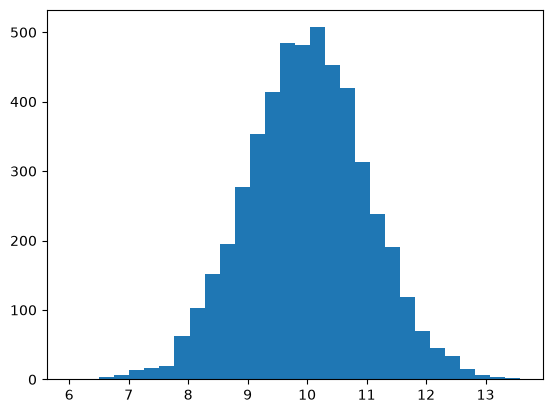

In [432]:
plt.hist(x, bins=30);

Looks great! Let's try it with the Poisson distribution:

In [441]:
x = rng.poisson(lam=1, size=5000)

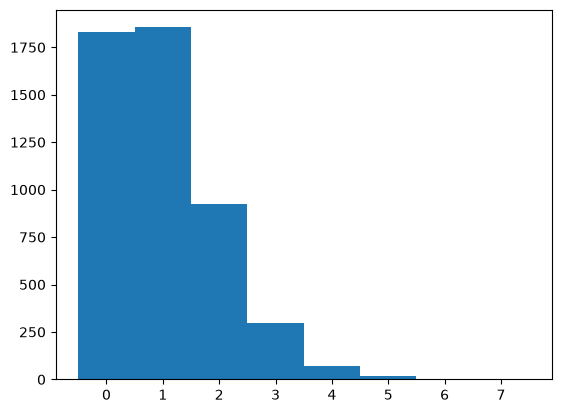

In [442]:
plt.hist(x, bins = np.arange(-0.5, 8, 1));

### Linear Algebra

Why have vectors and matrices if not to do linear algebra with them! NumPy offers a wide range of highly optimized linear algebra functions that cover matrix multiplication, the dot product, the cross product, matrix QR factorization, singular value decomposition, eigenvalues, eigenvectors, matrix and vector norms, matrix inversion, determinants, and trace, and it even has routines to solve linear matrix equations!

These functions are accessed through the `np.linalg` submodule, and a comprehensive list of them can be found [here, in the NumPy docs](https://numpy.org/doc/stable/reference/routines.linalg.html). Let's dig into a few examples. 

First, matrix multiplication. While it can be done with `np.linalg.matmul()`, we can also use the `@` operator!

In [445]:
A = rng.integers(low=0, high=11, size = (3,4))
B = rng.integers(low=0, high=11, size = (4,5))

In [447]:
A

array([[ 6,  0,  5, 10],
       [ 8,  6,  5,  5],
       [ 2,  0,  3, 10]])

In [448]:
B

array([[ 5,  1,  3,  3,  7],
       [10,  3,  5,  3,  9],
       [ 2, 10,  4, 10,  8],
       [ 4,  7,  6,  2,  8]])

In [449]:
A @ B

array([[ 80, 126,  98,  88, 162],
       [130, 111, 104, 102, 190],
       [ 56, 102,  78,  56, 118]])

Sanity check: the shape makes sense! 

Next, let's compute the norm of `A` both manually and with `np.linalg.norm()`:

In [451]:
np.sqrt((A**2).sum())

np.float64(20.591260281974)

In [450]:
np.linalg.norm(A)

np.float64(20.591260281974)

We can also try computing an eigenvector $\textbf{v}$ of a square array $M$ and verify that $M\textbf{v} = \lambda\textbf{v}$:

In [457]:
M = rng.integers(low=0, high=11, size = (5,5))
M

array([[ 7,  7,  8,  5,  3],
       [ 5,  5,  3,  8,  4],
       [10,  7,  2,  1,  2],
       [ 8,  7,  4,  8,  1],
       [ 9,  0,  3,  2,  3]])

To avoid complex eigenvectors and eigenvalues (which NumPy easily deals with, I just want to simplify the example), let's make `M` symmetric by adding it to its own transpose:

In [468]:
M = M + M.T

In [474]:
eigvals, eigvecs = np.linalg.eig(M)
eigvals

array([103.66854614+0.j,  23.05987666+0.j, -23.32922386+0.j,
        -5.8855681 +0.j,   2.48636916+0.j])

In [476]:
np.real(eigvecs) # only show the real components, since the imaginary ones are all 0

array([[ 0.58049614,  0.35972459,  0.62540413, -0.37019048, -0.07383175],
       [ 0.45738707, -0.31727345,  0.17886151,  0.76496968, -0.27011957],
       [ 0.391934  ,  0.31895492, -0.68158207, -0.12434338, -0.51443183],
       [ 0.47900914, -0.66101594, -0.24260521, -0.3742486 ,  0.3669998 ],
       [ 0.26600617,  0.48089651, -0.23122895,  0.34965284,  0.72267235]])

Checking the left side of the characteristic equation:

In [488]:
lhs = M @ eigvecs[:, [0]]
lhs

array([[60.17919127+0.j],
       [47.41665233+0.j],
       [40.63122761+0.j],
       [49.65818128+0.j],
       [27.57647284+0.j]])

And now the right side:

In [489]:
rhs = eigvecs[:, [0]] * eigvals[0]
rhs

array([[60.17919127+0.j],
       [47.41665233+0.j],
       [40.63122761+0.j],
       [49.65818128+0.j],
       [27.57647284+0.j]])

They look the same! Another way to check computationally is to use `np.allclose()`:

In [493]:
np.allclose(lhs, rhs, rtol=1, atol=0)

True

Or you could simply divide the arrays by each other and make sure the resulting array is all 1:

In [497]:
lhs/rhs

array([[1.+0.j],
       [1.+0.j],
       [1.+0.j],
       [1.+0.j],
       [1.+0.j]])

Now let's try `np.linalg.solve()` to solve the simple linear matrix equation $Ax=B$. Since we're just testing the function, we can start with $A$ and $x$, compute $B$, and see if `np.linalg.solve()` can truly find $x$.

In [483]:
A = rng.integers(0, 11, (3,3))
x = rng.integers(0, 11, (3,1))
A

array([[ 9,  7,  1],
       [ 4,  5,  2],
       [10,  5,  4]])

In [487]:
x

array([[1],
       [5],
       [1]])

In [485]:
B = A @ x
B

array([[45],
       [31],
       [39]])

In [486]:
np.linalg.solve(A, B)

array([[1.],
       [5.],
       [1.]])

Works like magic!

## Data visualization

Now that we've learned how to deal with data and do math with it, let's learn how to make pretty pictures with it!

The three most relevant data visualization libraries in Python are the following:
1) `Matplotlib`: the bread and butter of plotting in Python. It is designed to emulate plotting with MATLAB (hence the name).
2) `Pandas` itself, in addition to be a data processing library, possesses data plotting functions that directly use `Matplotlib`.
3) `Seaborn`, while also built with and on top of `Matplotlib`, offers a fancier array of plotting capabilities. However, because it is high-level, it is not as customizable as `Matplotlib`. 
There are of course other libraries that one can use (`Plotly` comes to mind) that are out of the scope of this bootcamp, but by all means, feel free to explore them as well!

Since `Matplotlib` is the bread and butter of mainsteam Python plotting and the foundation of many common visualization libraries, we will mainly deal with `Matplotlib` in this session to really understand the mechanics of plotting with Python. 

##### Goals:
- figures and axes
- line plot
- scatter plot
- figure resolution
- color, line style, marker style
- colormaps and colorbars
- legend

### Getting started

First let's import the `matplotlib.pyplot` library and give it the alias `plt` to make it easier to call it. 

In [506]:
import matplotlib.pyplot as plt
import matplotlib as mpl
print(mpl.__version__)

3.11.1


Now let's get right to plotting a simple line plot, just to get a sense of what we're dealing with.

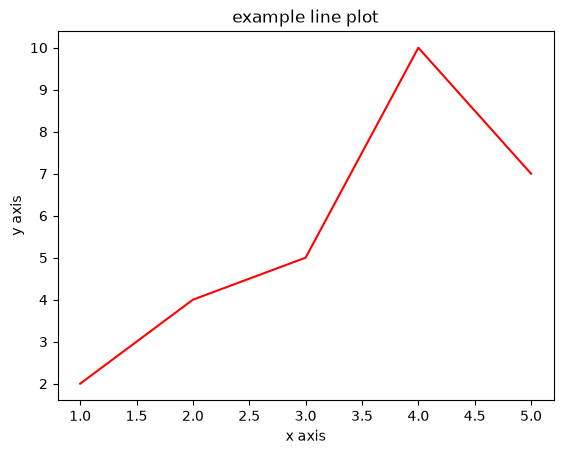

In [507]:
fig, ax = plt.subplots()
ax.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
ax.set_title("example line plot")
plt.show()

Easy! Now let's break it down:
* `plt.subplots()` creates a Figure object (`fig`) that contains a single Axes object (`ax`), more on what this means later.
* `ax.plot()` calls the `plot()` method inside the Axes object, which takes the x coordinates first, then the y coordinates, then any optional styling arguments (like `color`) in this case.
* `ax.set_xlabel()`, `ax.set_ylabel()`, and `ax.set_title()` are all methods that change the x and y axis labels and the title of the Axes object.
* `plt.show()` usually displays all active figures, which in a Jupyter notebook is simply the figure that was just coded. However, it is not a necessary call because Jupyter automatically calls it when running a code cell, so we'll drop it from now on.


### The anatomy of a figure

Here is an amazingly helpful schematic pulled straight from the [Matplotlib docs](https://matplotlib.org/stable/users/explain/quick_start.html#parts-of-a-figure).

<center><img src='figures/anatomy.png'></center>

The `Figure` is essentially the big rectangular patch that contains everything that is drawn. However, a Figure is basically nothing without an `Axes` object, which is the rectangular area that actually contains the x and y axes, the plot itself, as well as most text drawn on the plot (x and y labels, the title, and more). The x and y axes are represented by `Axis` objects (different from the `Axes`, which is the class that contains them), which set the scale (how the data is distributed on a plot), the limits, and generate the ticks.   

Thus, the (oversimplified) hierarchy of objects in Matplotlib is the following:
```
Figure
    > Axes
        > XAxis, YAxis
```

This layout of `Figures` that contains one or many `Axes` (or even more subfigures, which we will not explore here) enables a lot of customization, most importantly the ability to draw a figure with multiple subplots using the `subplots()` function, which first takes two numbers: the number of rows and then the number of columns.


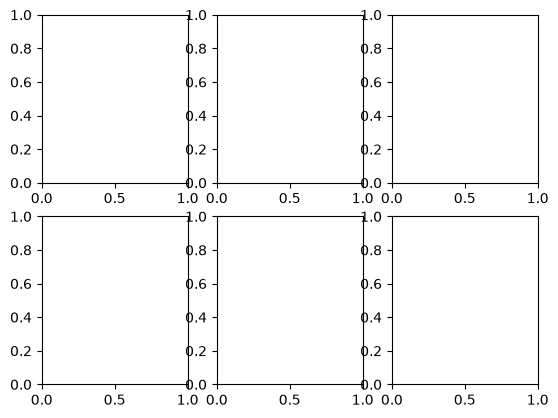

In [508]:
fig, ax = plt.subplots(2,3)

Bothere by the overlapping tick labels and spines? Me too. This is because the font sizes are set to a default value that might be too big when the figures get too crowded. There are at least two ways to deal with it. (1) You could use `layout="constrained"`, which is an algorithm that goes over the elements in the figure and shrinks them so there is no overlab:

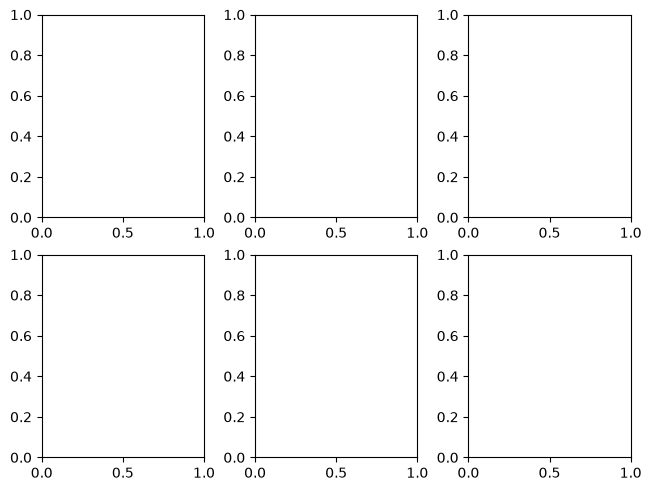

In [509]:
fig, ax = plt.subplots(2,3, layout='constrained')

Or (2) you could simply make the figure larger using the `figsize` argument, which takes a tuple containing the width, the height, and then optionally the units (`"in"` \[the default value\] or `"cm"` or `"px"`; but only in the latest version of `matplotlib`), then adding the subplots:

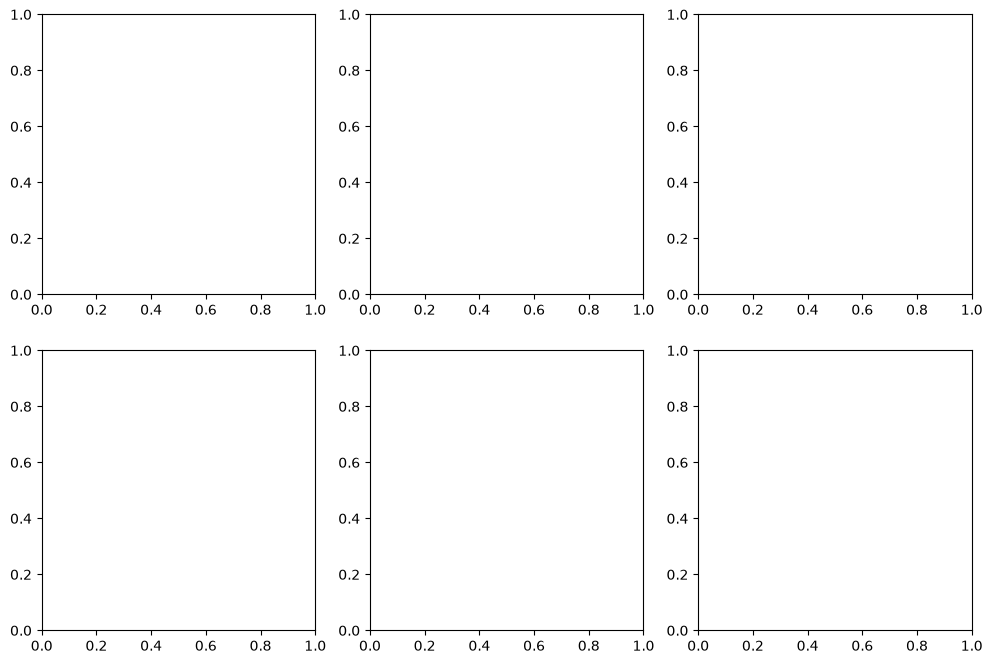

In [510]:
fig, axes = plt.subplots(2,3, figsize=(12,8, 'in'))

To access each of these suplots, we simply index our way through the `axes` variable (which you could call anything you want, but `axes` is the cannon), which is a matrix in which each element is an `Axes` object ready to be used. The way we access an element in an array is also with square brackets containing first the row index and second the column index of the element: `[row, col]`.

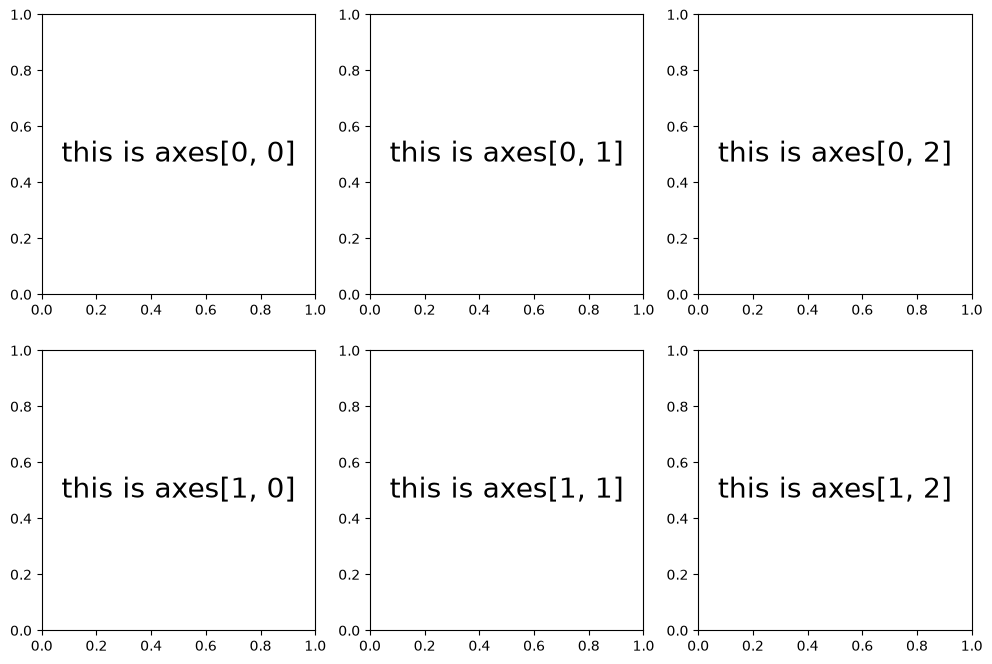

In [511]:
fig, axes = plt.subplots(2,3,figsize=(12,8))

for i in range(2):
    for j in range(3):
        axes[i, j].text(0.5, 0.5, 
                        f"this is axes[{i}, {j}]", 
                        ha='center', va='center', # (h)orizontal/(v)ertical (a)lignment
                        fontsize=20)

(Note that when adding text to a plot, all you need are the x and y coordinates, and the text itself. You can also specify the horizontal and vertical alignment using the `ha` and `va` arguments, which I set to `"center"` here.)

To illustrate this point further, here's another cool function that can also divide the `Figure` in a much more sophisticated way:

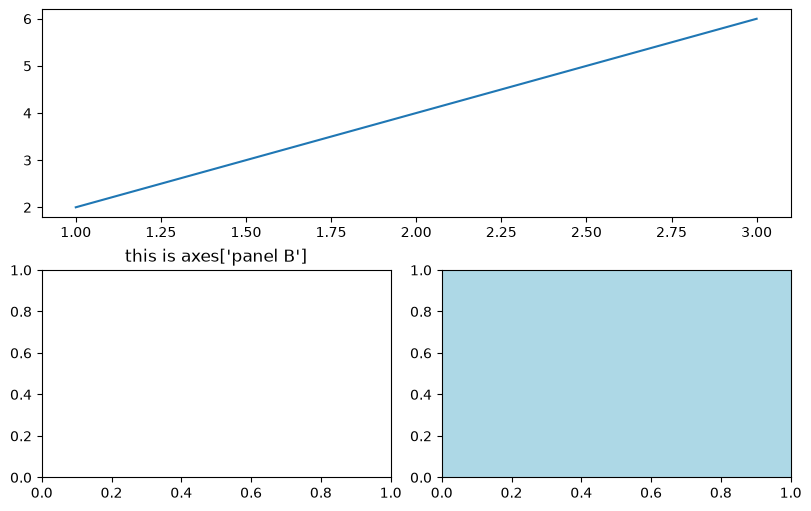

In [512]:
fig, axes = plt.subplot_mosaic([
    ['panel A', 'panel A'],
    ['panel B', 'panel C']
], figsize=(8, 5), layout="constrained")

axes['panel A'].plot([1,2,3], [2,4,6])
axes['panel B'].set_title("this is axes['panel B']")
axes['panel C'].set_facecolor('lightblue')

### The pyplot coding style

The coding style above, where we directly manipulate `Figure` and `Axes` objects, is called the **object-oriented approach**. There is another, perhaps slightly simpler (but also slightly messier) style called the pyplot style. This style was design to emulate MATLAB plotting, so it can also be called the MATLAB style.  

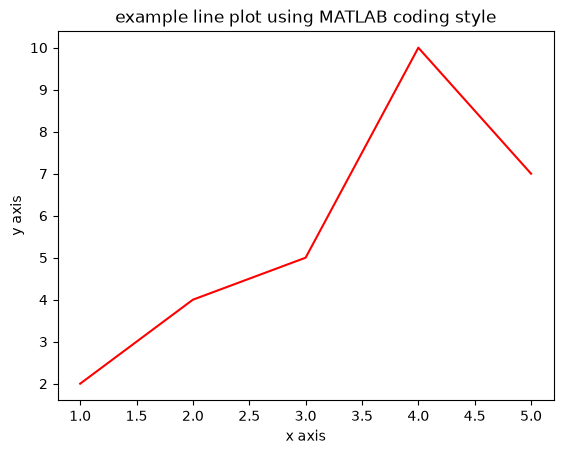

In [513]:
plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('example line plot using MATLAB coding style');

Some main differences to be pointed out:
* We did not first need to create a subplot using `plt.subplots()`; we just used `plot()` directly. Notice that this is `pyplot.plot()`, not `Axes.plot()` (which we used in the very first example). Here, `pyplot.plot()` automatically creates the Figure and Axes objects, making reasonable assumptions about what we want them to look like.
* The function names are shorter: simply `xlabel`, `ylabel`, and `title` instead of `set_xlabel`, `set_ylabel`, and `set_title`

This extra convenience is.. well, very convenient, especially for quick and dirty data exploration. However, it does come at a cost, as it does not yield full power and customization over plotting as seamlessly as the object-oriented style. And very importantly, since we do not specify which Axes to plot in, this code makes assumptions about which Axes is "active" and which are "inactive", and only draws on active plots. (Just like MATLAB!) This also why this coding style is also called **state-based**, because it depends on the active/inactive states of the plots. If you are coding in a development environment that allows for multiple active plots at the same time (i.e. not Jupyter), this can get very confusing.

To concretize this idea of an "active" plot, here's how we create a figure with multiple subplots using state-based, pyplot/MATLAB-style coding. We first call `pyplot.subplot()`, which creates and activates one subplot (**not the same as** `pyplot.subplots()`, which creates multiple subplots at the same time). `pyplot.subplot()` takes at least 3 arguments in this order: the number of rows, the number of columns, and then the index of the subplot to activate (`1` for the first one, `2` for the second one, and so on, going left to right, top to bottom): 

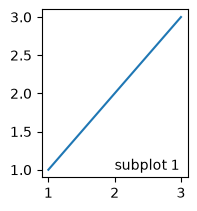

In [514]:
plt.subplot(2,3,1) # 2 rows, 3 columns, start with the first subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 1');

Notice how the subplot is smaller, but there are no other subplots waiting to be populated like the examples above. We have to activate them manually, and in any order we want:

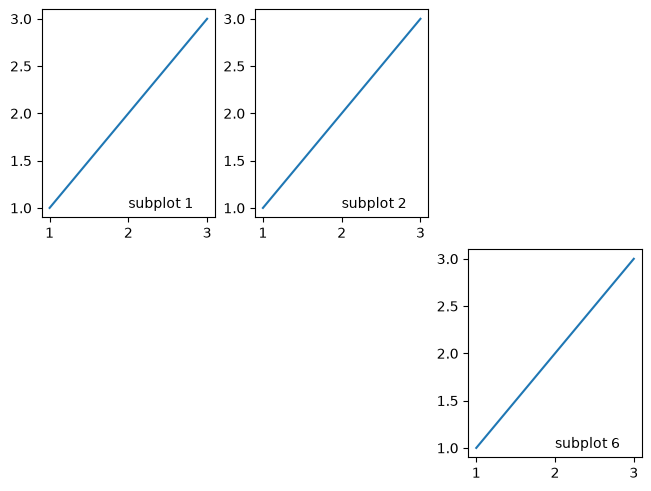

In [515]:
plt.figure(layout='constrained')
plt.subplot(2,3,1) # 2 rows, 3 columns, start with the first subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 1')

plt.subplot(2,3,2) # 2 rows, 3 columns, start with the second subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 2')

plt.subplot(2,3,6) # 2 rows, 3 columns, start with the sixth subplot
plt.plot([1,2,3], [1,2,3])
plt.text(2,1,'subplot 6');

To reiterate, while `subplots()` (plural) creates all the subplots at the same time, `subplot()` only creates one at a time and figures out on the go where to place that subplot. (One might say it kind of wings it!)

Here is a table that briefly recapitulates and compares the two coding styles:

|| Pyplot-style (MATLAB-like) | Object-oriented programming (OOP) style |
|---|:-:|:-:|
|Use case|Quick and rough plotting|More complicated figures with many subplots|
|Internal mechanism|State-based: tracks latest active plot and modifies it|Object-based: requires explicit call to specific objects,<br>so any object that has been drawn can be modified|
|Pattern|Direct plotting using `plt.plot()` (or other),<br>which implicity defines Figure and Axes| Explicitly define Figure and Axes objects using `fig, ax = plt.subplots()`,<br>then plotting by calling `ax.plot()`|
|Adding subplots|On-the-go, by calling `plt.subplot()` (singular)|Done at first, when calling `plt.subplots()` (plural)|

From now on, we will use both coding styles depending on the situation. MATLAB style for quick and dirty plotting and exploration, and object-oriented style for more complex plots.

### Figure resolution

Before we continue, I want to briefly address figure resolution. You might have noticed, like me, that the figures above are not as crispy as one would like, especially for papers, which usually require figures to have a resolution of at least 300 dpi (dots per inch). The fix is easy. Either specify `dpi=300` every time you create a figure, or if you want a more permanent and global fix, change Matplotlib's runtime confifuration parameters (`rcParams`):

In [516]:
mpl.rcParams['figure.dpi'] = 300

And now see the difference:

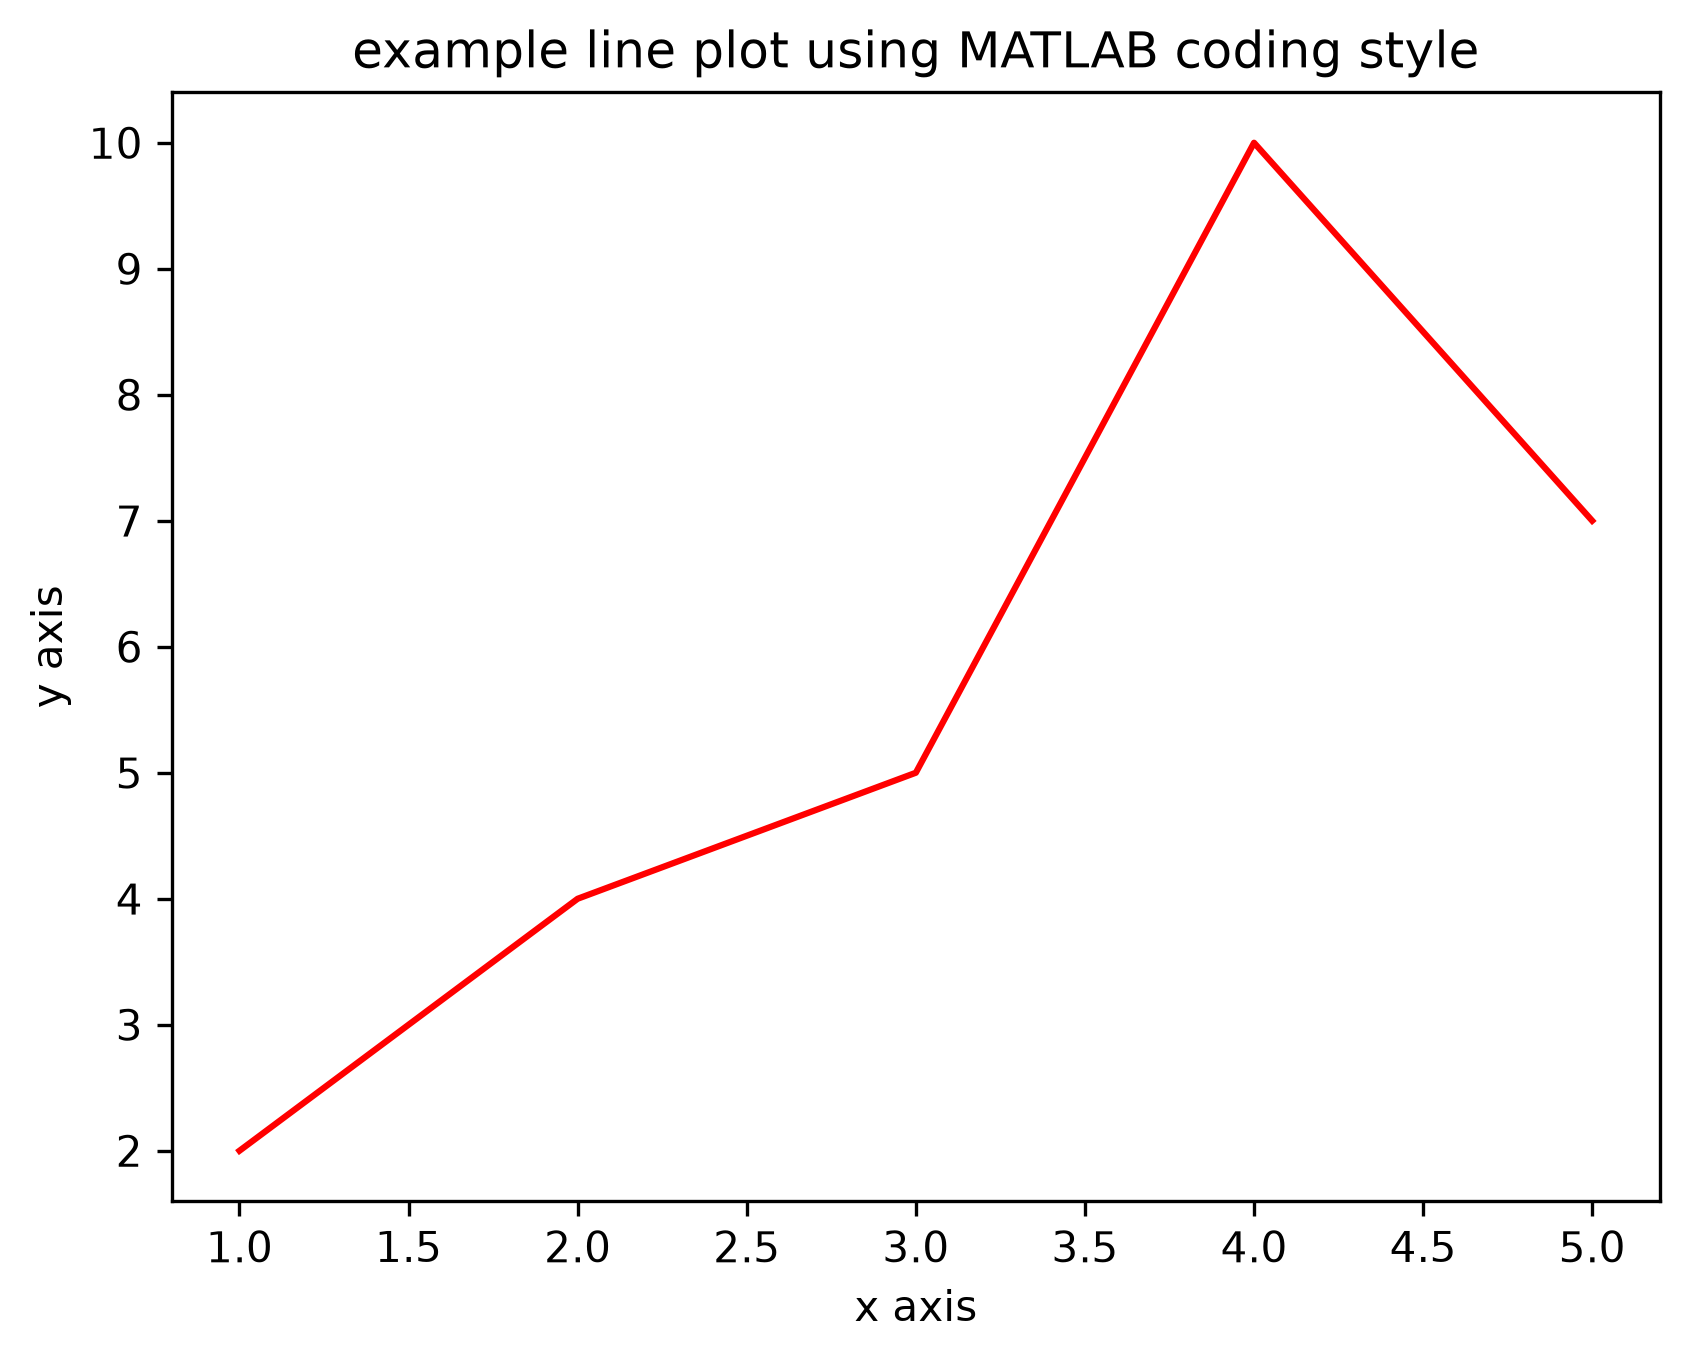

In [624]:
plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
plt.xlabel('x axis')
plt.ylabel('y axis')

plt.title('example line plot using MATLAB coding style');

Beautiful!

### Ticks and labels, grids and limits

In addition to changing the x and y axis labels with `plt.xlabel()` and `plt.ylabel()`, there is much more that you can do to customize your axes.

First, the ticks: these are the tiny dashes that punctuate the axes. You can easily change them and their labels with `plt.xticks()` and `plt.yticks()`, to which you pass:
- `ticks`: the list of ticks of your choice, and
- optionally, `labels`: the list of labels corresponding to the ticks of your choice. (Needless to say, the two lists must have the same length.)

To add a grid, simply call `plt.grid()`, which takes the following arguments:
- `axis`: the axis along which the grid lines are added, could be `x`, `y` or `both`
- `which`: whether to add the `major` gridlines, `minor` gridlines, or `both`. Major gridlines follow the ticks you set, and since setting minor gridlines is more complicated, they are usually the only gridlines you will be adding to your plots.

To adjust the x and y axis limits, simply call `plt.xlim(low, high)` and `plt.ylim(low, high)`.

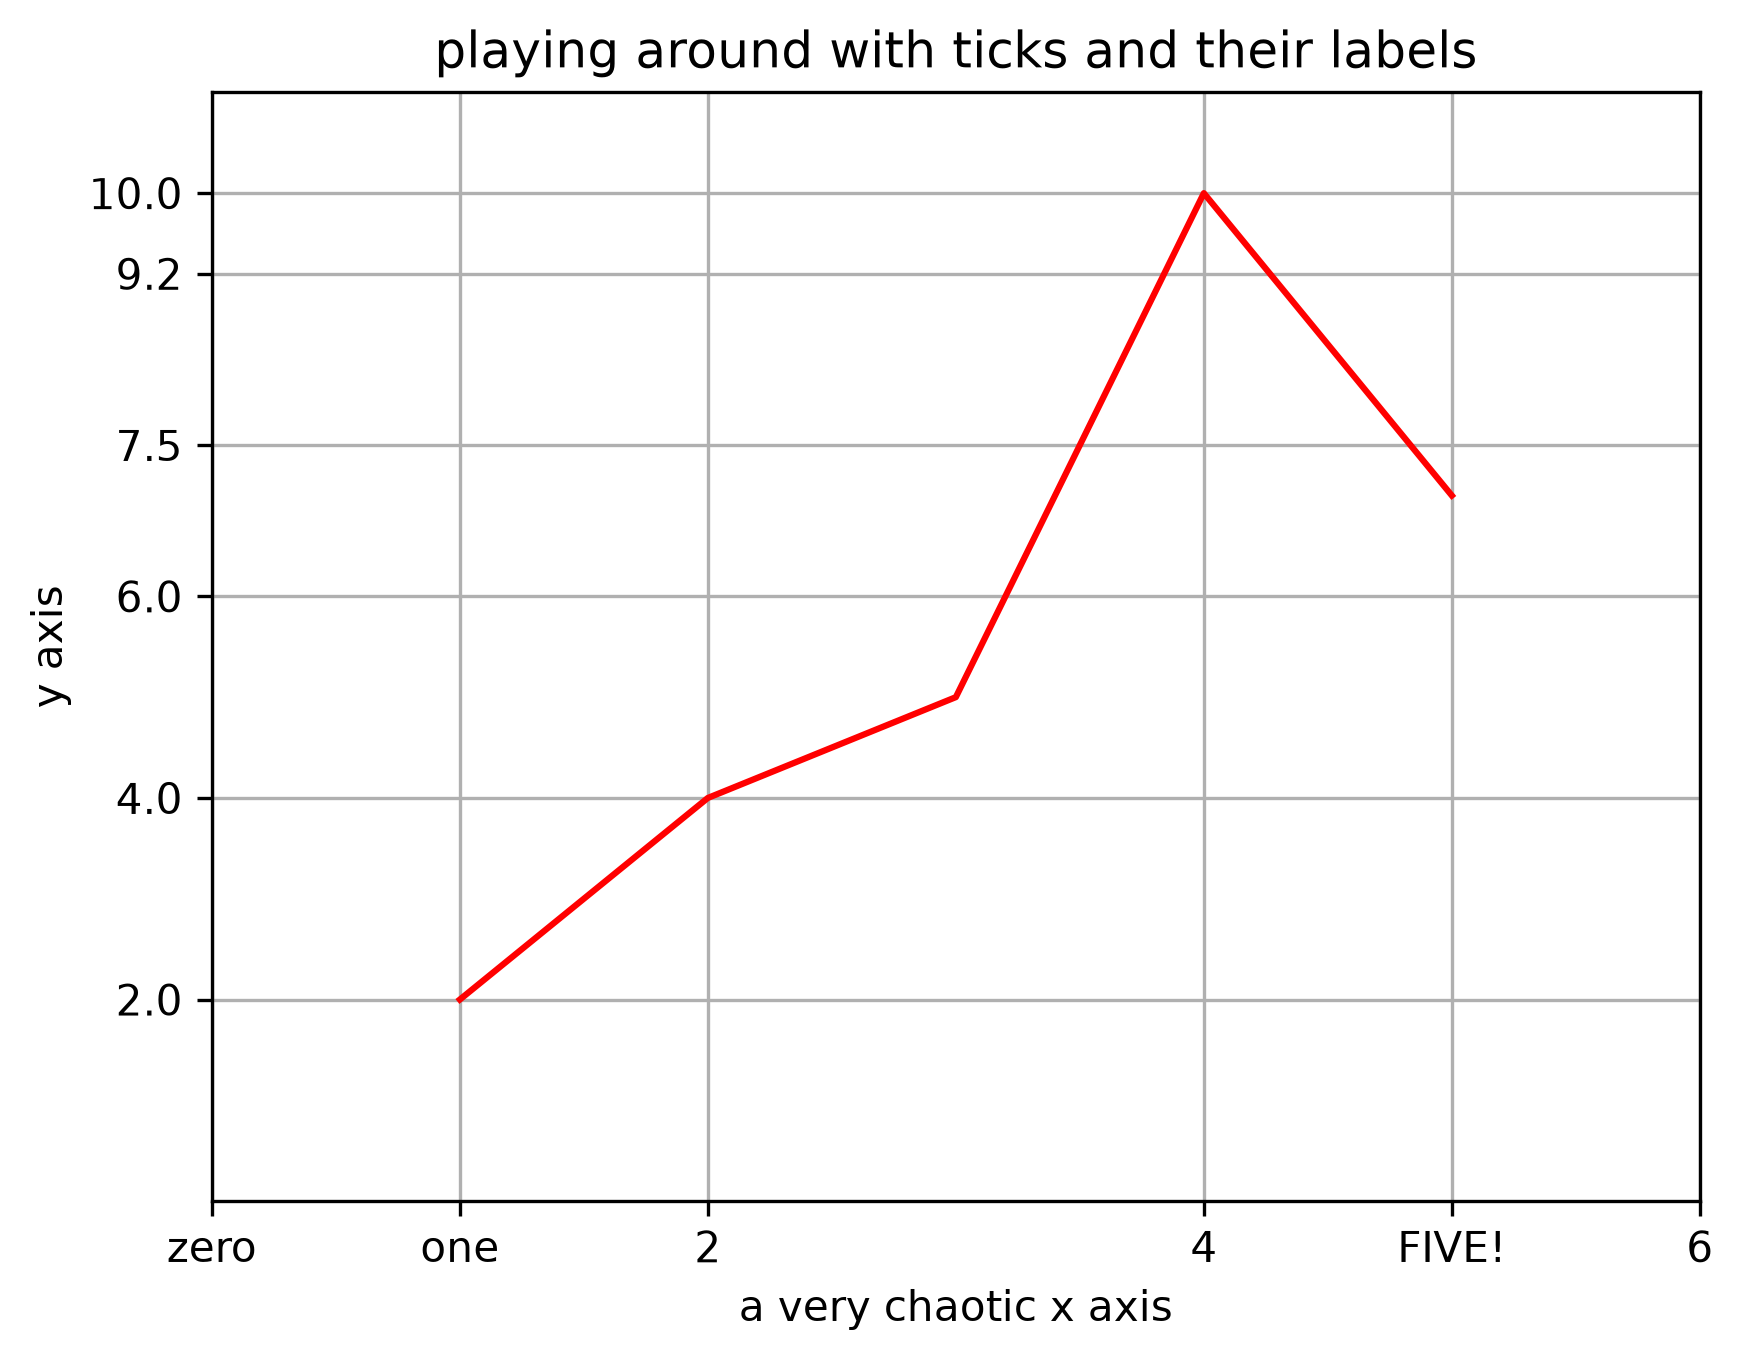

In [809]:
plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
plt.xlabel('a very chaotic x axis')
plt.ylabel('y axis')

# set the ticks and their labels
plt.xticks([0,1,2,4,5,6], labels = ['zero','one', 2, '4', 'FIVE!', 6])
plt.yticks([2,4,6,7.5,9.2,10])

# change the grid
plt.grid(axis='both', which='both')

# adjust the limits
plt.xlim(0, 6)
plt.ylim(0, 11)


plt.title('playing around with ticks and their labels');

Remember the two coding styles we discussed above? Turns out the functions that we just discussed do not always have the same name in both styles. In the example above, I use the Pyplot style. Usually, the same function in the OOP will have `set_` precede the Pyplot-style function name. Some examples:
|Pyplot style|OOP style|
|:-:|:-:|
|`plt.xlim()`|`ax.set_xlim()`|
|`plt.ylim()`|`ax.set_ylim()`|
|`plt.title()`|`ax.set_title()`|
|`plt.xlabel()`|`ax.set_xlabel()`|
|`plt.ylabel()`|`ax.set_ylabel()`|
|`plt.xticks()`|`ax.set_xticks()`|
|`plt.yticks()`|`ax.set_yticks()`|

Another way to set these variables in the OOP style is to use the `ax.set()` function:
```
ax.set(xlim=...,ylim=...,title=...,xlabel=...,ylabel=...)
```

### Plotting functions return useful stuff

When calling a plotting function (like `plt.plot()`), not only does it modify the figure, but it also usually returns something very useful: references to the object or the collection of objects it just drew. These references are powerful because they allow us to easily customize the figure further before it is plotted.

For instance, if you look at [the documentation for `plt.plot()` here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html), you will notice that it is usually organized as follows:
1. A general explanation of the function
2. The input parameters
3. What the function returns — that's what I'm talking about here
4. Other parameters and examples

Usually, the documentation will say what sort of object is returned. To better understand how to modify that object, you could either read the documentation for it (which is usually linked right there), or you could use Python's `dir()` to see what funtions and parameters are available.

Let's try that with `plot()`:

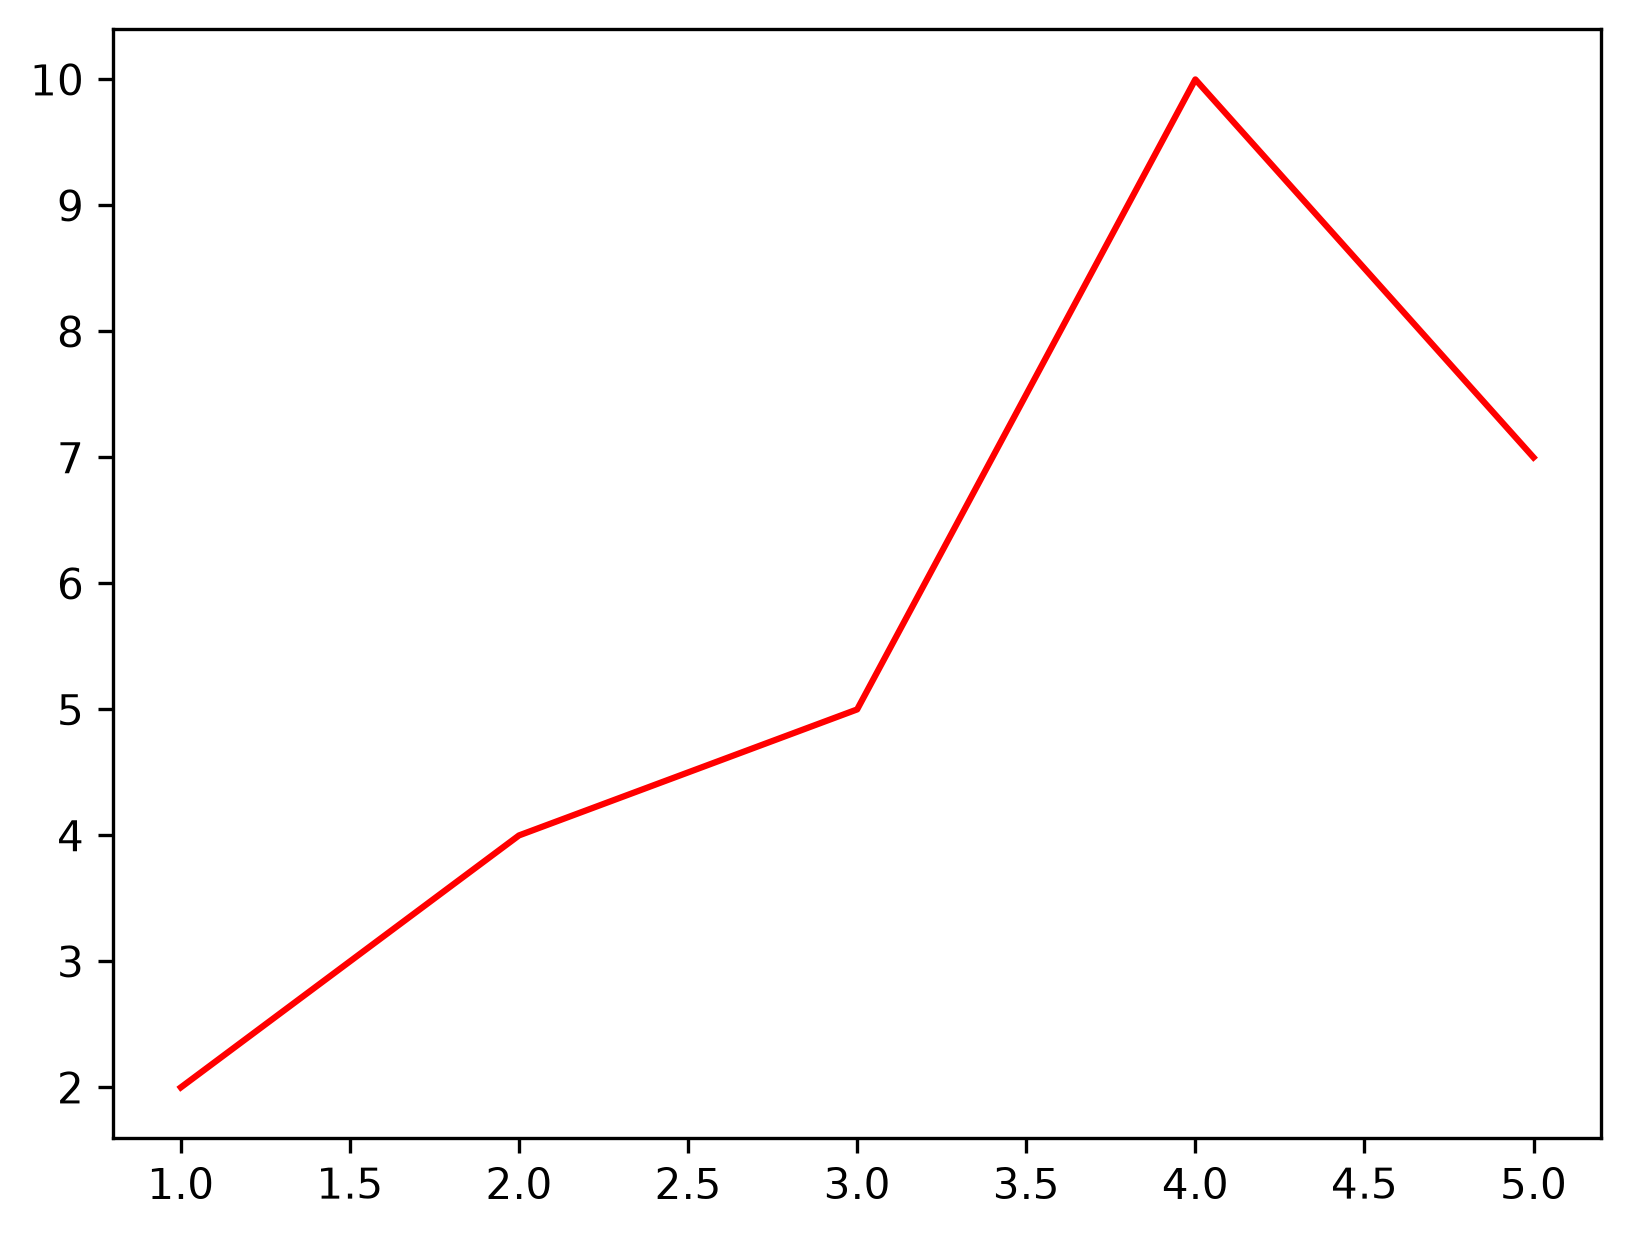

In [1209]:
p = plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')

Now let's explore what is in `p`:

In [1212]:
p

Okay, so `p` is a list of `Line2D` objects. A `Line2D` objects is the Matplotlib class for standard 2D lines. The reason it's a list is because `plot()` can actually plot many lines at the same time if the inputs are 2D arrays (in that case, the columns are the individual lines). 

Now let's see what `Line2D` has under its hood:

In [1213]:
dir(p[0])

['_PROPERTIES_EXCLUDED_FROM_SET',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_agg_filter',
 '_alias_to_prop',
 '_alpha',
 '_animated',
 '_antialiased',
 '_axes',
 '_callbacks',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_color',
 '_dash_pattern',
 '_dashcapstyle',
 '_dashjoinstyle',
 '_different_canvas',
 '_drawStyles_l',
 '_drawStyles_s',
 '_drawstyle',
 '_fully_clipped_to_axes',
 '_gapcolor',
 '_get_in_autoscale',
 '_get_markerfacecolor',
 '_get_transformed_path',
 '_gid',
 '_in_autoscale',
 '_in_layout',
 '_internal_update',
 '_invalidx',
 '_invalidy',
 '_label',
 '_lineStyles',
 '_linestyle',
 '_line

That's a very, very long list of parameters and methods! The methods with leading and/or trailing underscores (like `__class__` and `_alpha`) are for internal use, so you should not worry about them. Everything else is up for grabs. For instance, let's look at one function that seems promising:

In [1218]:
print(p[0].get_xydata())
print(p[0].get_color())

[[ 1.  2.]
 [ 2.  4.]
 [ 3.  5.]
 [ 4. 10.]
 [ 5.  7.]]
red


Wow! It spits back the original plotting data! 

The functions that start with `set_` are especially useful too, as they allow us to manipulate the objects post-hoc — after they were created. This allows for a lot of customization!

The example below shows a trivial application of this feature, but we will see much more natural and non-trivial uses of this trick as we go through this workshop.

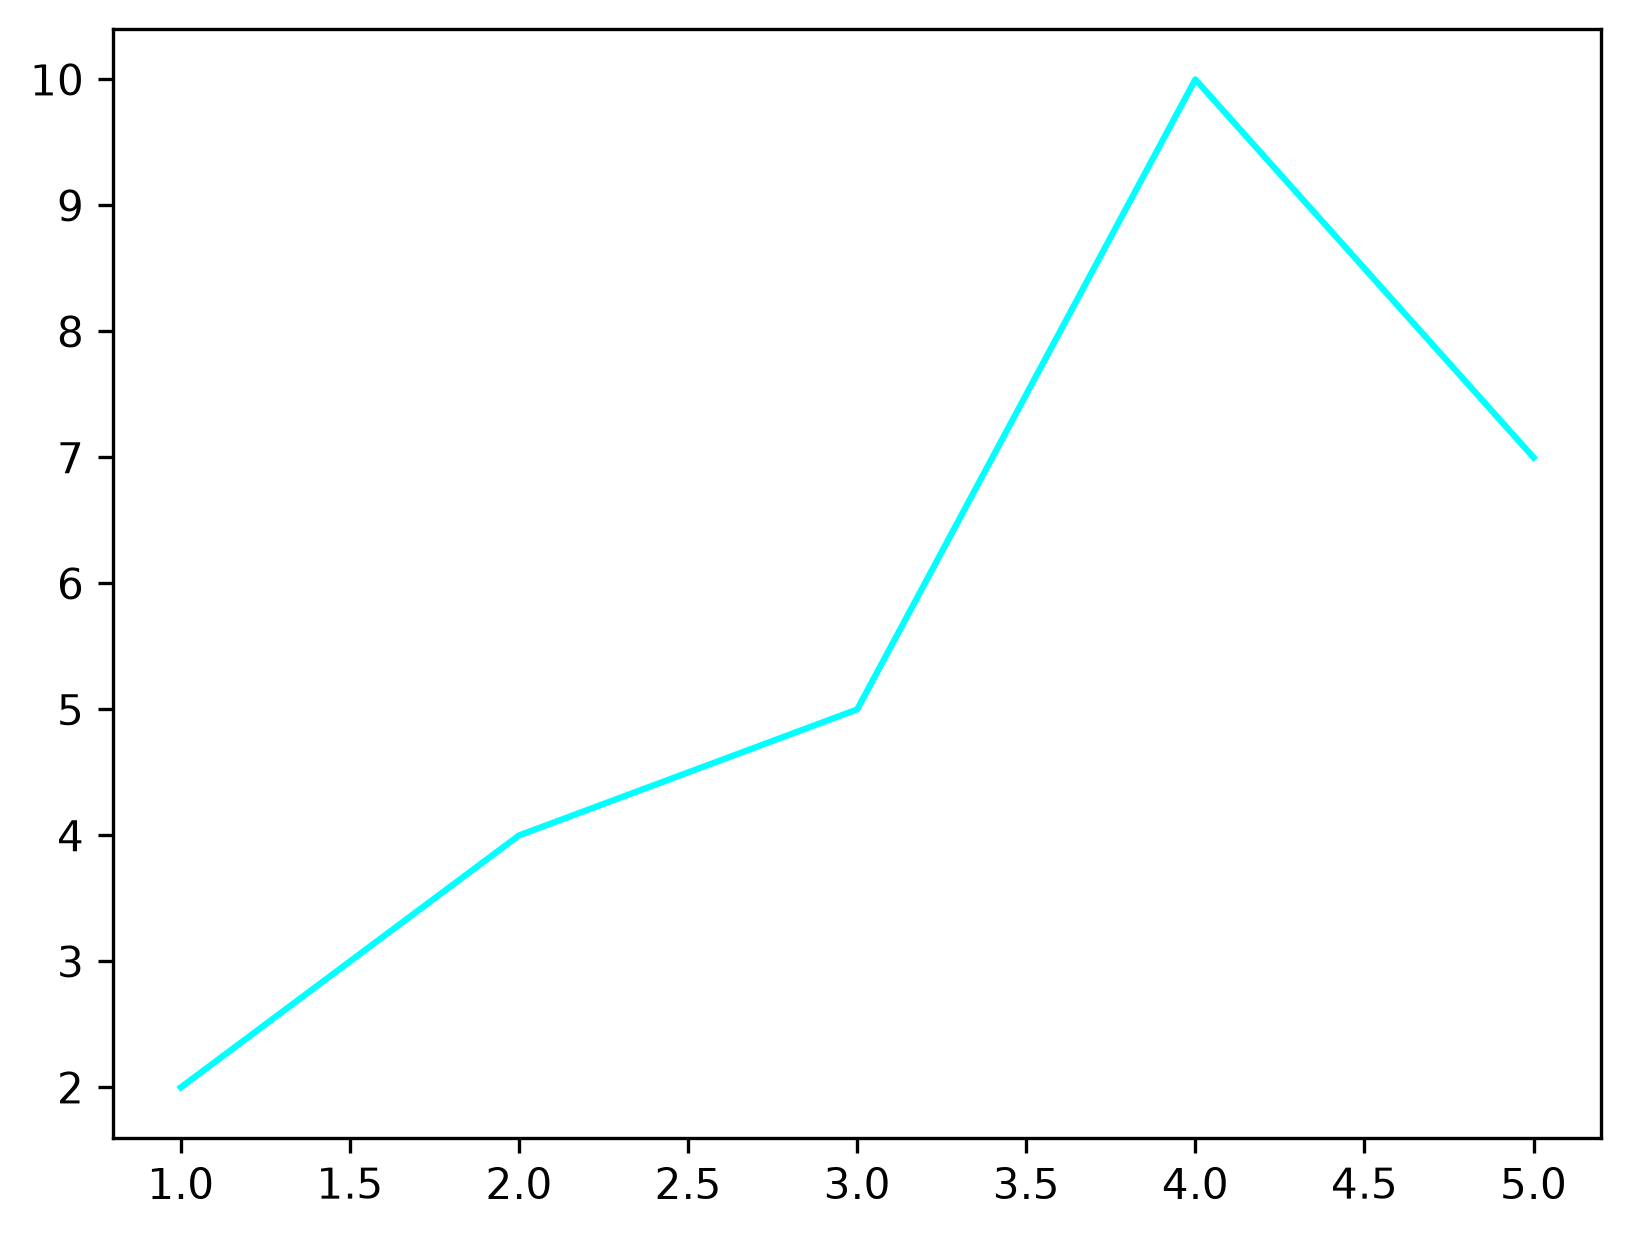

In [1221]:
p = plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
p[0].set_color('cyan') # oops, we changed our mind

### Colors

Before we dive into the myriad plot types that Matplotlib offers, let's first talk about some of the fundamental features they all share: styling and colors. Matplotlib provides a very wide range of styling choices (like line width, line style, and marker style), and an even wider range of colors. 



Let's start with adjusting colors. When you draw multiple lines on a plot, Matplotlib automatically cycles through a preset color "cycler":

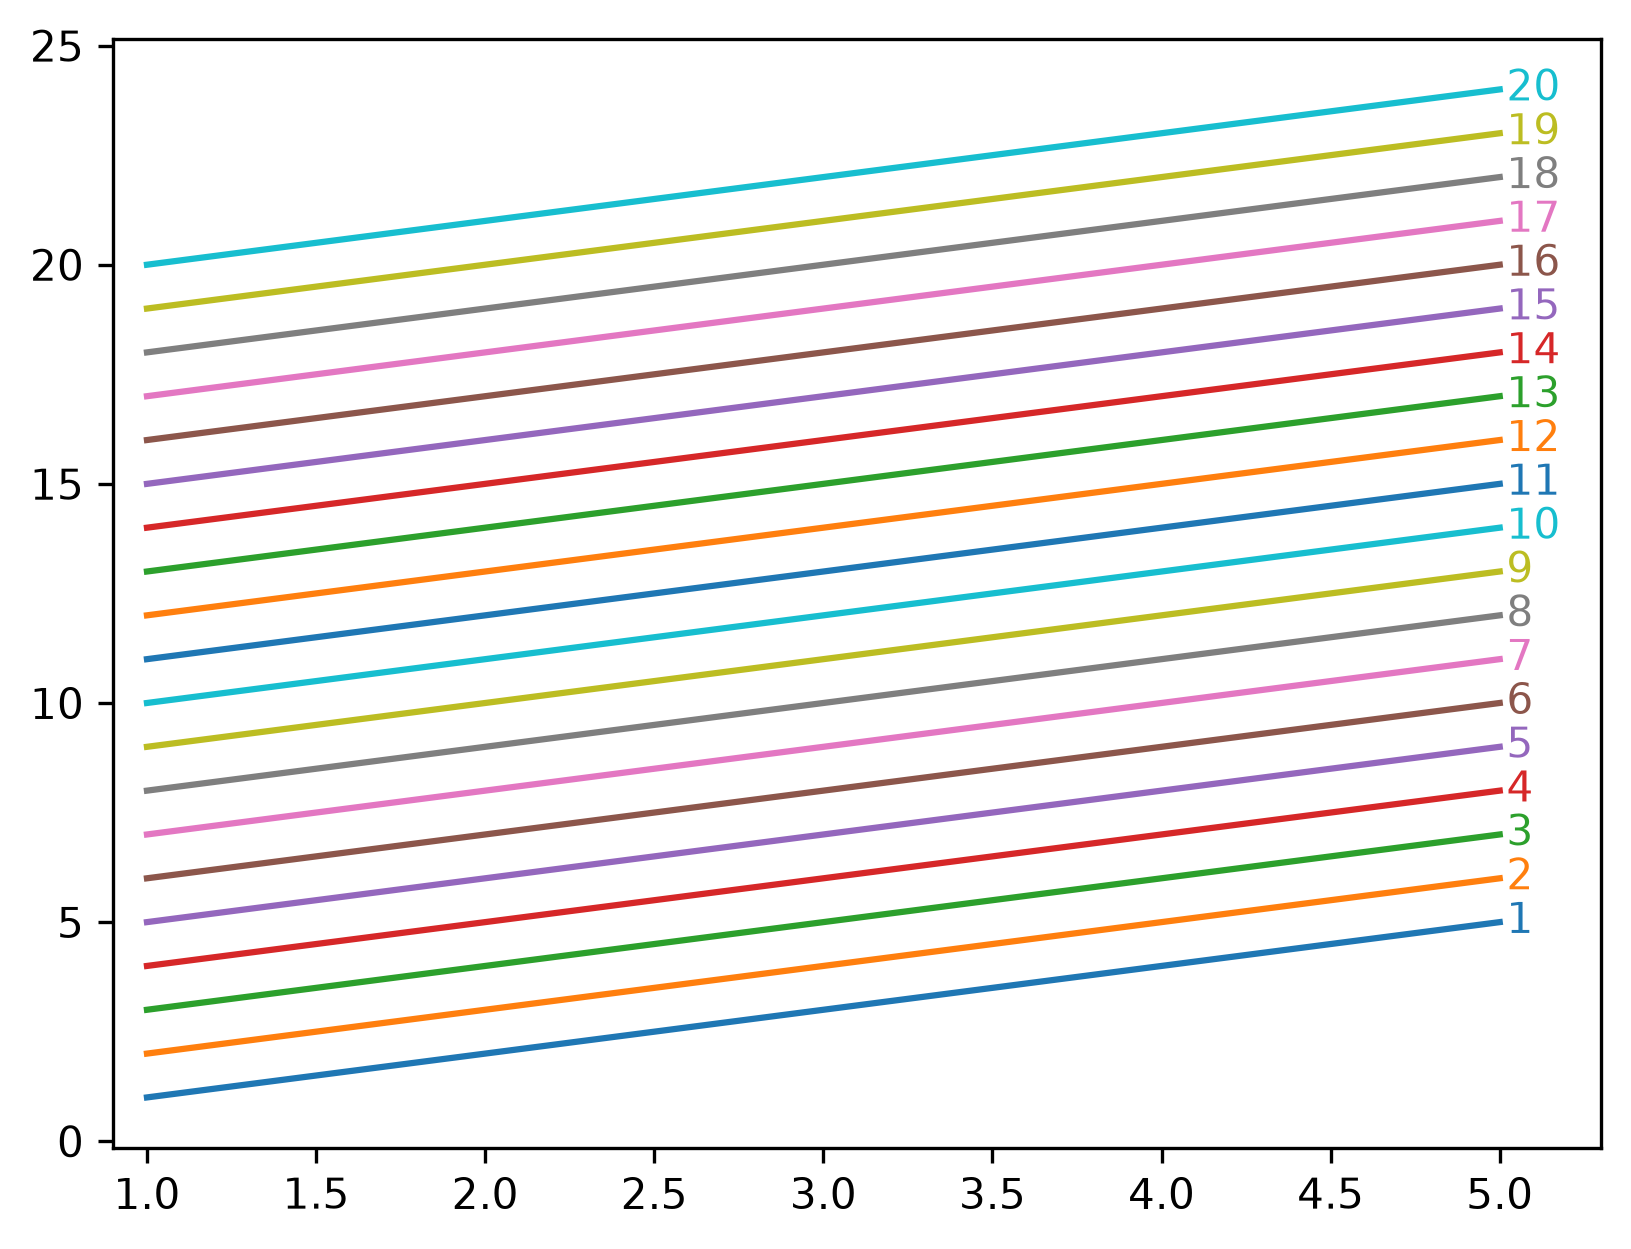

In [792]:
for i in range(20):
    a = plt.plot([1,5], [1+i, 5+i])                # plot the line
    c = a[0].get_color()                           # retrieve the color
    plt.text(5.02, 5+i, i+1, color=c, va='center') # assign the color to the text
plt.xlim(0.9, 5.3);

This shows us that the preset color cycler contains 10 colors. That's very convenient! So no need to worry about colors when doing some quick plotting — Matplotlib will do that for you.

However, in case you wanted to set up your very own palette, there is almost an infinite number of colors you can choose from, and so many ways to define them! Here are a few:
- Single-character shorthand notation for a few basic colors: `rgbcmykw` for red, green, blue, cyan, magenta, yellow, black, and white.
- Named preset colors from Tableau, CSS4, and XKCD like `'lightcoral'`, `'darkturquoise'`, and `'peachpuff'`. A comprehensive list can found [here](https://matplotlib.org/stable/gallery/color/named_colors.html).
- Tuple of RGB or RGBA code, where A is the alpha, or the transparency (0 for fully transparent to 1 for fully opaque)
- HEX code for RGB or RGBA (i.e. `"#DC143C"` for crimson), where the "A" stands for the `alpha` parameter. The alpha is simply the transparency; an alpha of 1 is fully opaque, and an alpha of 0 is fully transparent (invisible)
- A string representation of a number between 0 and 1 representing a grayscale (0 is black, 1 is white, everything in between is the proverbial gray area)

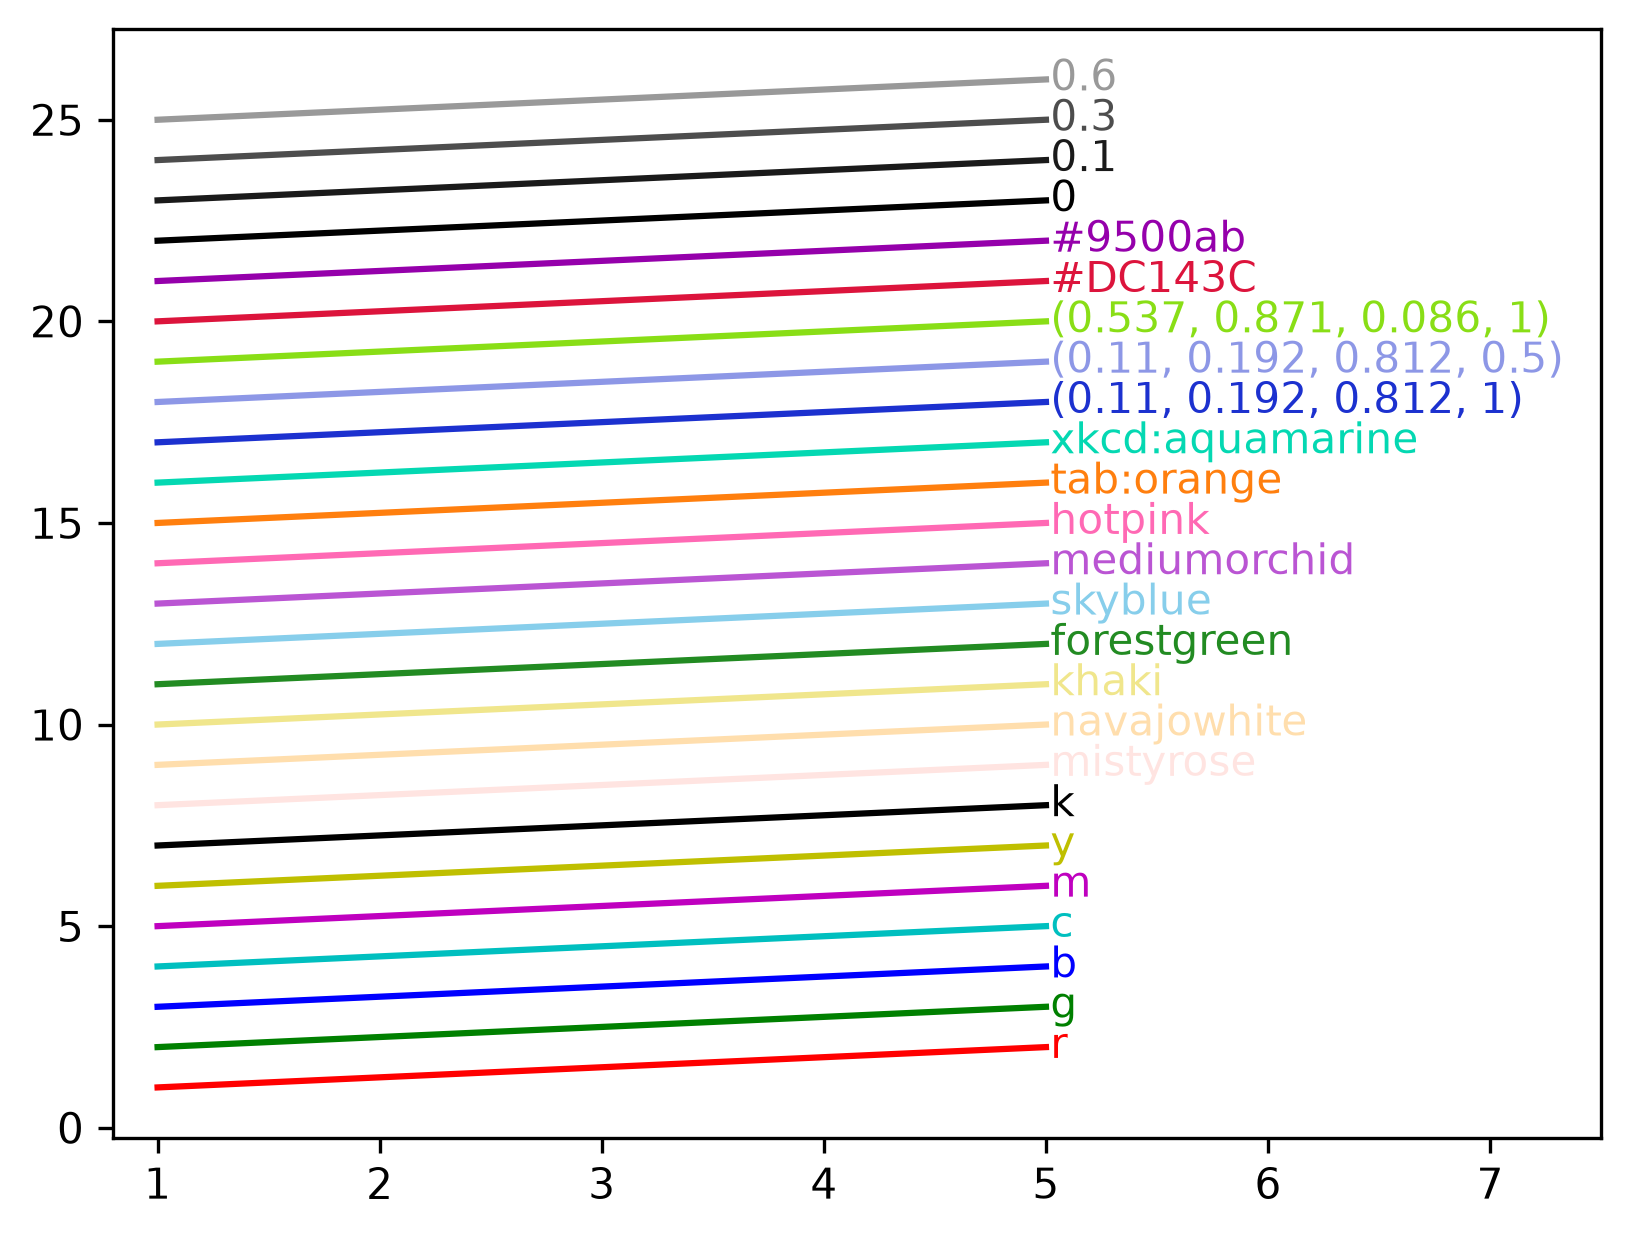

In [519]:
color_list = list('rgbcmyk') + ['mistyrose', 'navajowhite', 'khaki', 'forestgreen', 'skyblue', 'mediumorchid', 'hotpink', 'tab:orange', 'xkcd:aquamarine', (0.11, 0.192, 0.812, 1), (0.11, 0.192, 0.812, 0.5), (0.537, 0.871, 0.086, 1), '#DC143C', '#9500ab', '0', '0.1', '0.3', '0.6']

for i, color in enumerate(color_list):
    plt.plot([1,5], [1+i, 2+i], color=color)
    plt.text(5.02, 2+i, color, color=color, va='center')
plt.xlim(0.8, 7.5);

### Lines

In addition to the infinite palette of colors to choose from, Matplotlib also offers customization with its lines styles! Specifically, you can change a line's width with `linewidth` (or `lw`) and a line's style (solid, dotted, dashed, dashdotted, and more) with `linestyle` (or `ls`).

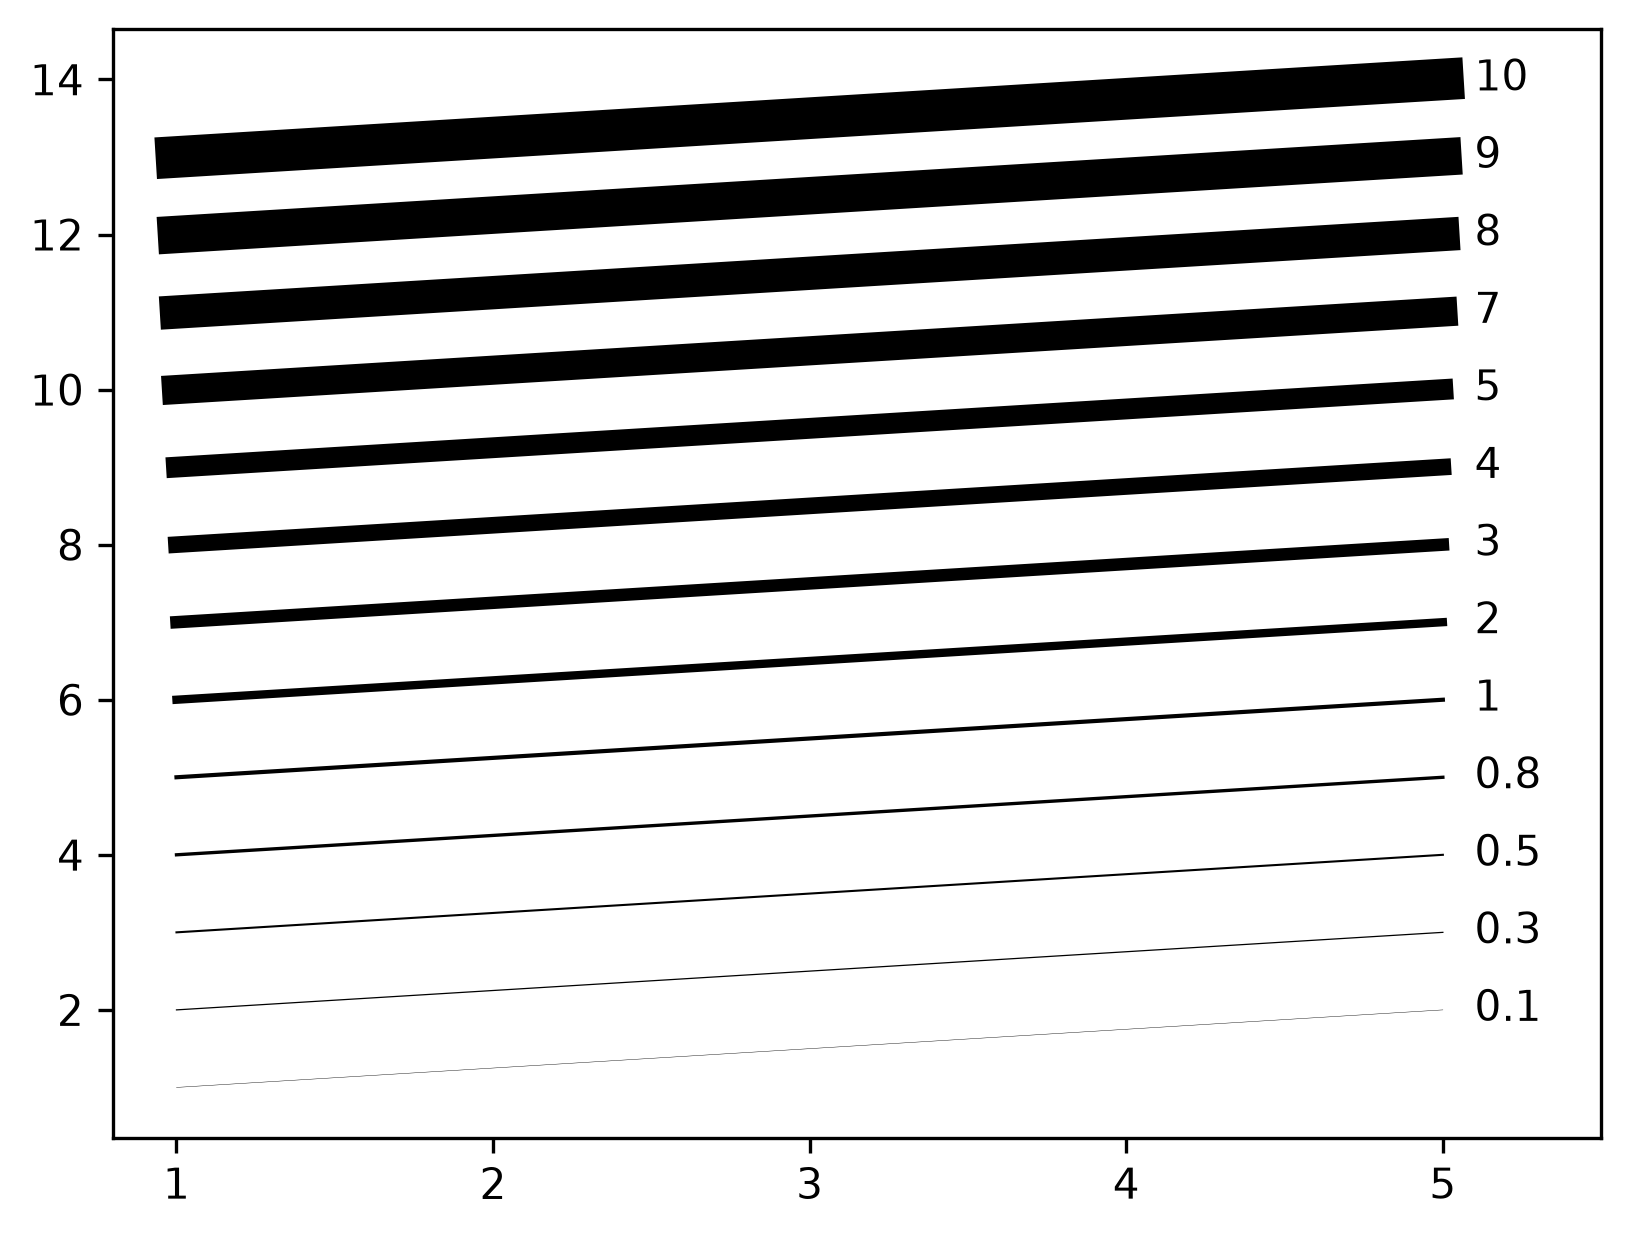

In [660]:
widths = [0.1, 0.3, 0.5, 0.8, 1, 2, 3, 4, 5, 7, 8, 9, 10]

for i, w in enumerate(widths):
    plt.plot([1, 5], [1+i, 2+i], lw=w, c='k')
    plt.text(5.1, 2+i, w, color='k', va='center')
plt.xlim(0.8, 5.5);

As mentioned above, line styles can be solid, dashed, dotted, dash-dotted, or customized using the following tuple: `(offset, (on, off, on, off,...))` — reminds me of Morse code!

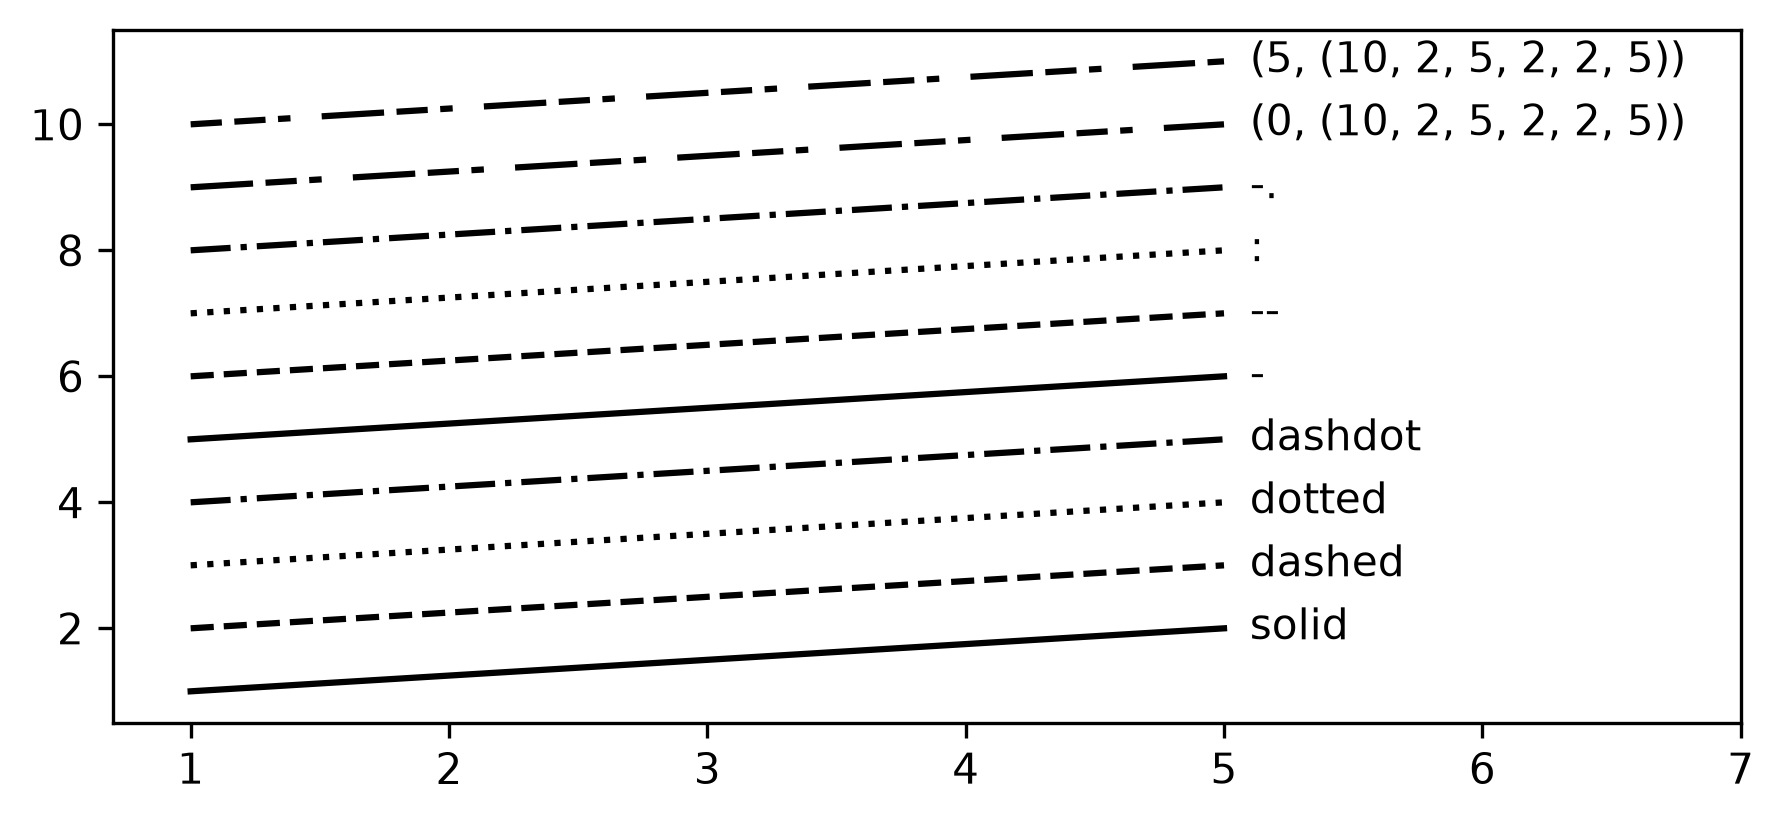

In [767]:
styles = ['solid', 'dashed', 'dotted', 'dashdot', '-', '--', ':', '-.', (0, (10,2,5,2,2,5)), (5, (10,2,5,2,2,5))]
plt.figure(figsize=(7,3))
for i, s in enumerate(styles):
    plt.plot([1, 5], [1+i, 2+i], ls=s, c='k')
    plt.text(5.1, 2+i, s, color='k', va='center')
plt.xlim(0.7, 7);

Let's talk about a couple types of special lines:
- Grids, since they are also lines, can be stylized just like lines by setting arguments like `color`, `linestyle`, and `linewidth`
- If you want to plot a horizontal or vertical line that spans the entire graph (to indicate a threshold value, for instance), you can use `plt.axhline()` and `plt.axvline()`, which can also be stylized the same way as lines!

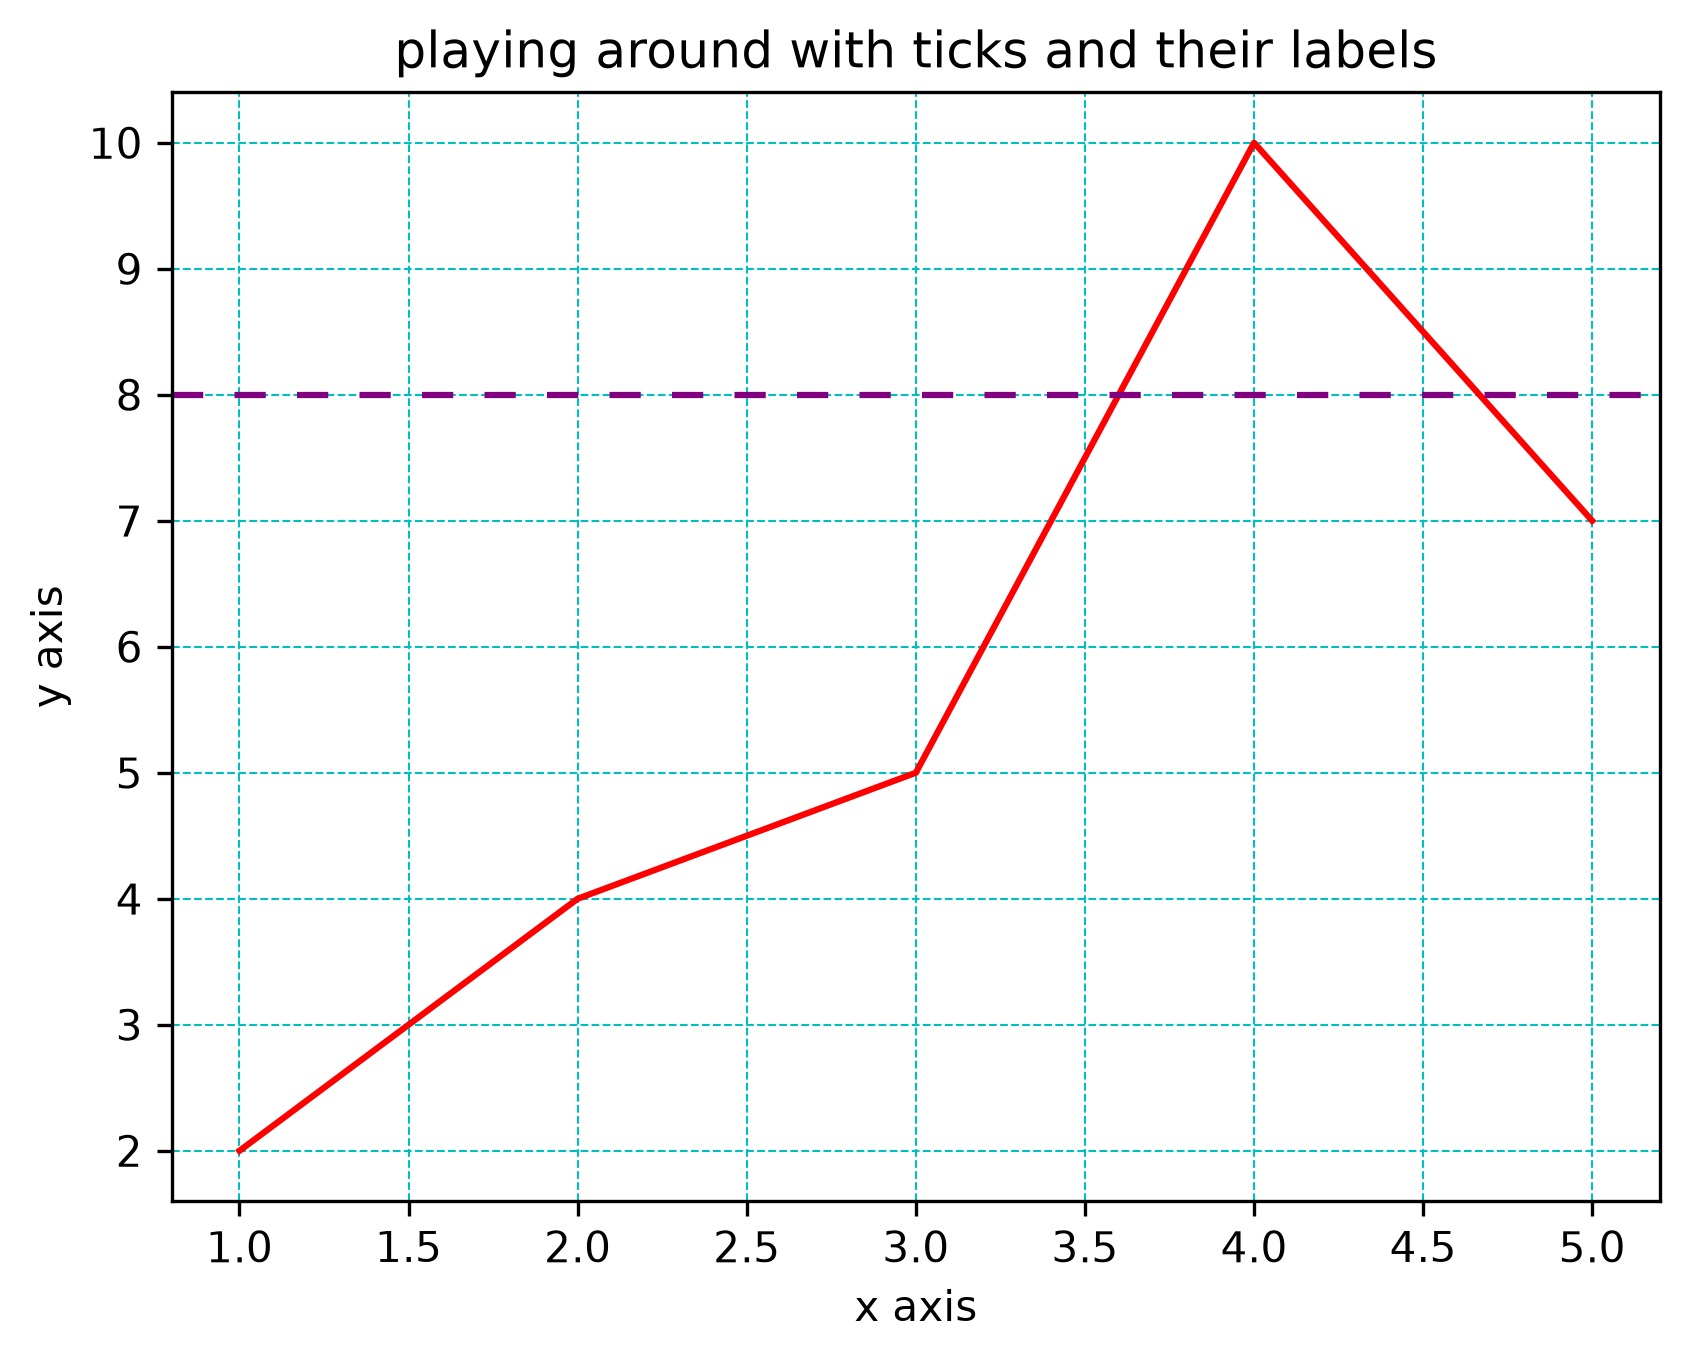

In [826]:
plt.plot([1,2,3,4,5], [2,4,5,10,7], color='red')
plt.xlabel('x axis')
plt.ylabel('y axis')

# add a horizontal line
plt.axhline(y=8, c='purple', linestyle=(0, (5,5)))


# stylize the grid
plt.grid(axis='both', which='both', color='c', linestyle='--', linewidth=0.5)


plt.title('playing around with ticks and their labels');

### Markers

To embellish your line plots, you can also pepper them markers at every data point! This is done with the `marker` argument, which can be set to any of a wide selection of marker styles, which come either filled (with potentially different edge and face colors) or unfilled (with a single color). Marker face color can be set using either `markerfacecolor` or `mfc`, and marker edge color can be set with either `marker edge color` or `mec`. Marker size can also be set using `markersize` or `ms`, and marker edge width can be set with `markeredgewidth` or `mew`.

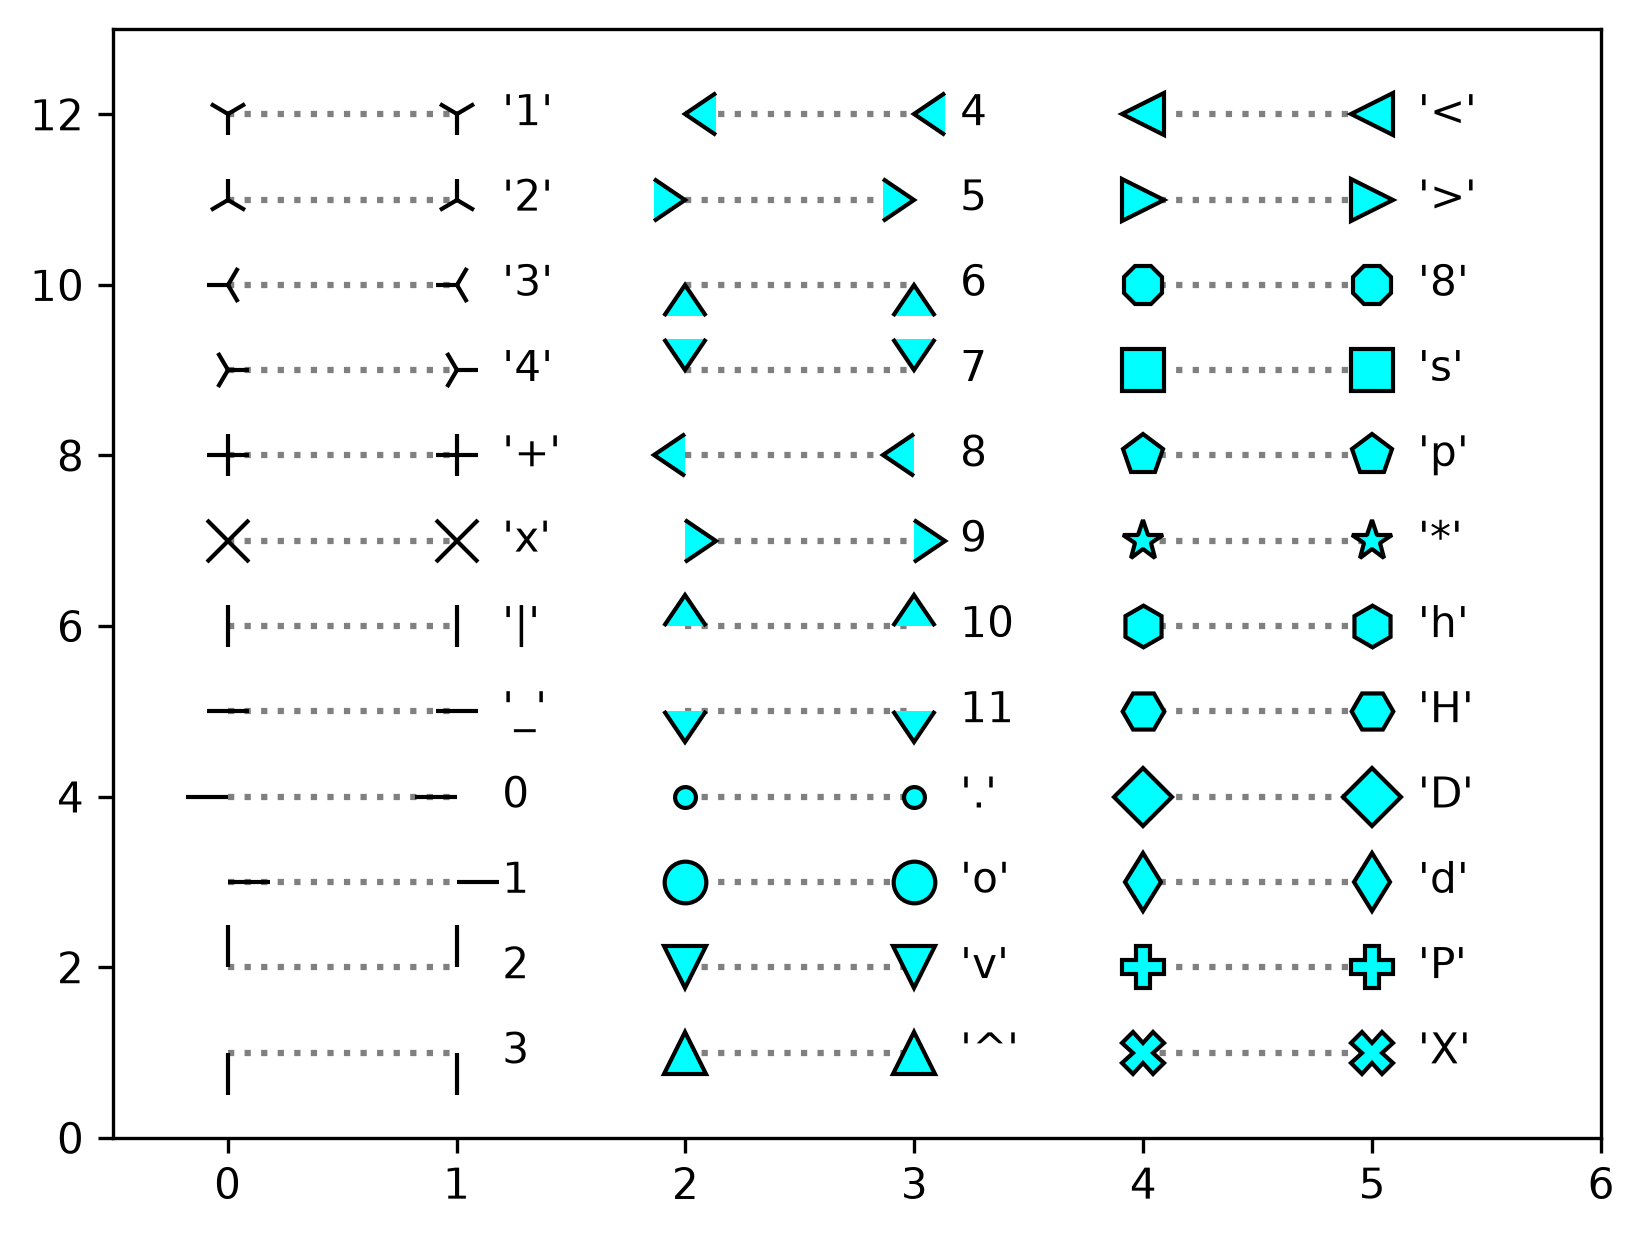

In [706]:
marker_styles = list('1234+x|_') + list(range(12)) + list('.ov^<>8sp*hHDdPX')
marker_x = np.repeat([0,2,4], 12)
marker_y = np.tile(np.arange(12,0, -1), 3)

for x,y,ms in zip(marker_x, marker_y, marker_styles):
    plt.plot([x, x+1], [y, y], ls=':', color='0.5', 
             marker=ms, mec='k', mfc='cyan', ms=10, mew=1)
    plt.text(x+1.2, y, repr(ms), va='center')
plt.xlim(-0.5, 6)
plt.ylim(0, 13);

### Shorthand format strings

If you're **really** in a rush, Matplotlib has an awesome shortcut for you: **format strings**. These strings are a quick and dirty way to provide the marker style, line style, and color you want in a single short string. The format string typically looks like this:

```
fmt = "[marker][line][color]"
```
Where the marker style can be any of the string characters shown above, the line styles can be any one of `-`, `--`, `-.`, and `:`, and the color can be any one color from `rgbcmykw`. Each element of these is optional (e.g. if you don't want a line or marker to be drawn at all), and while some other orderings are also supported (like `[color][marker][line]`), not all are, so try to stick to either of these two. Feel free to test it all out below!

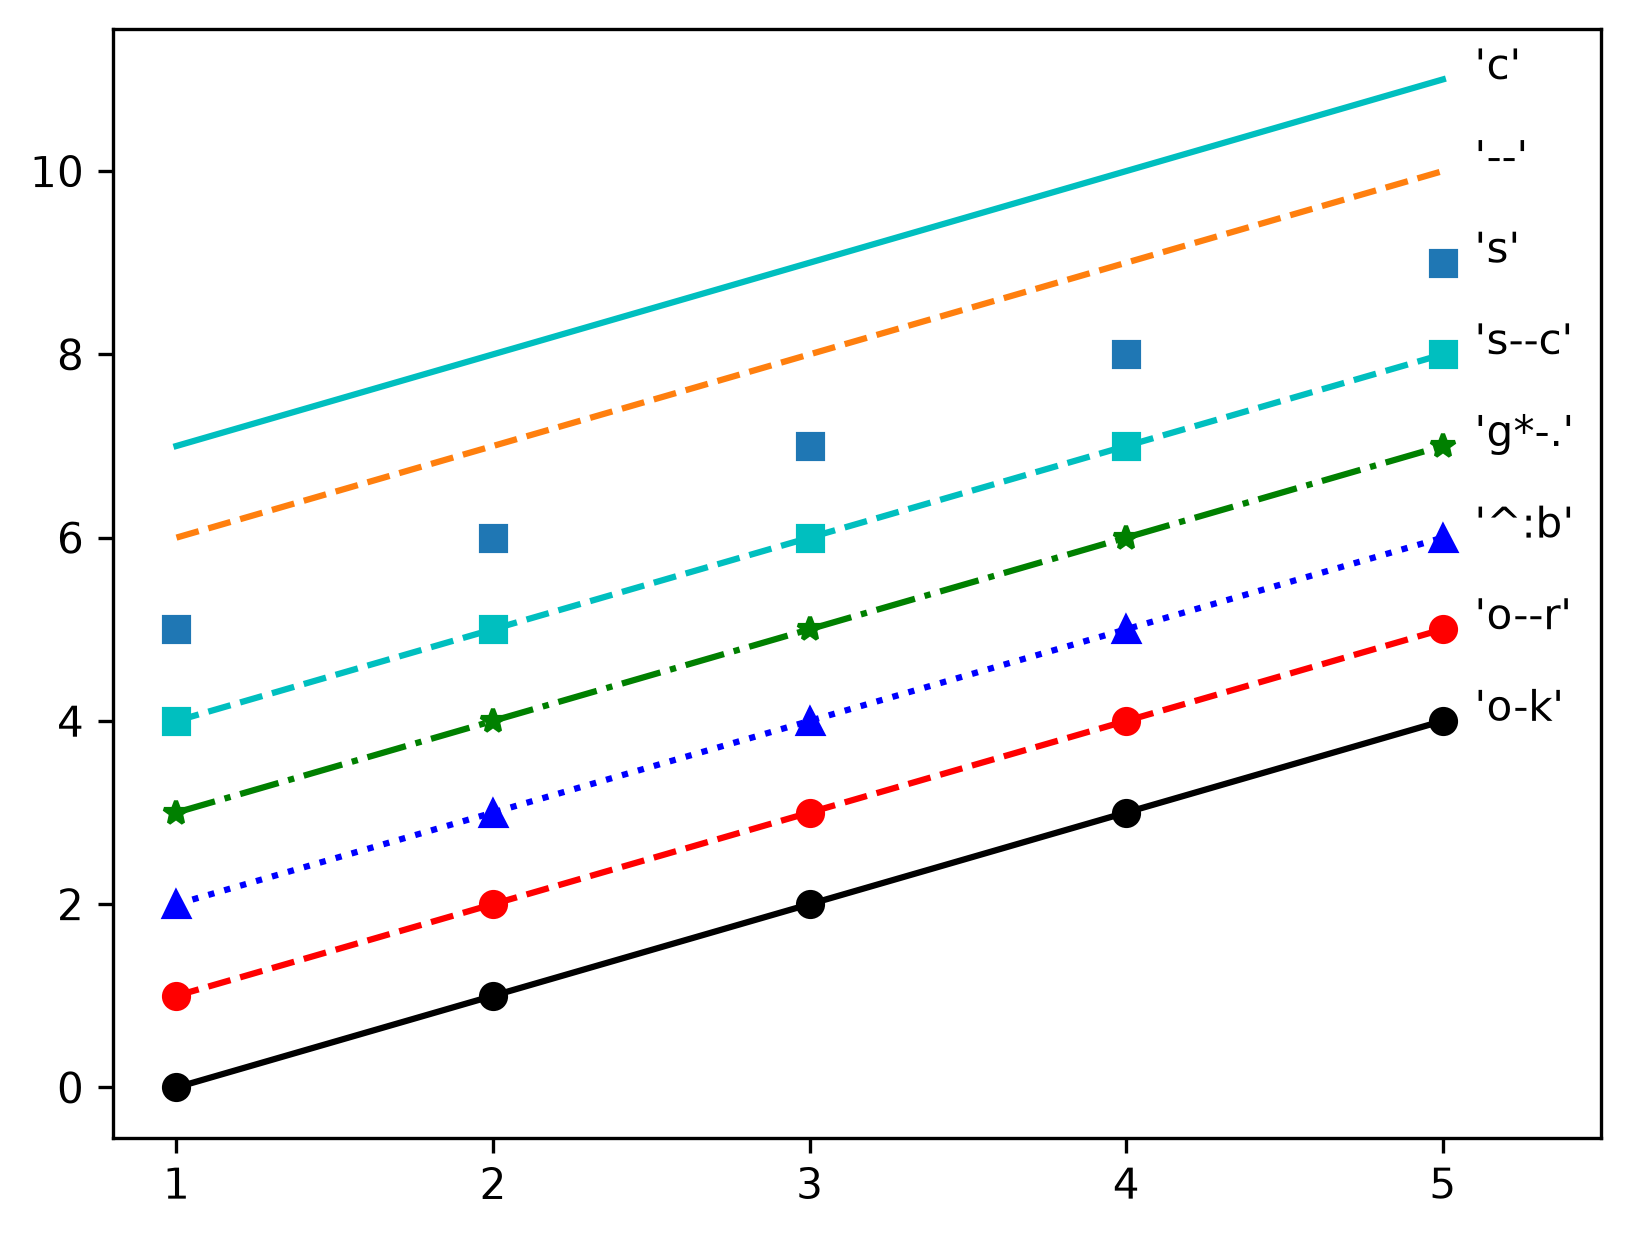

In [1180]:
fmt_strings = ['o-k','o--r', '^:b', 'g*-.', 's--c', 's', '--', 'c']

for i, fmt in enumerate(fmt_strings):
    plt.plot([1,2,3,4,5], np.arange(5)+i, fmt)
    plt.text(5.1, i+4, repr(fmt))

plt.xlim(0.8, 5.5);

### Scatter plots

Scatter plots are another very common plot type: they simply plot $(x,y)$ pairs as individual dots on a graph. `plt.scatter()`, like `plt.plot()`, also takes `x` and `y` inputs, which we will generate using a few Normal and Uniform distributions using the NumPy RNG we just learned about:

In [668]:
xy1 = rng.normal(0,1,(100, 2))
xy2 = rng.normal(6,2,(100, 2))
x3, y3 = rng.normal(-3,3,(100, 1)), rng.normal(10,3,(100,1))
x4, y4 = rng.uniform(5, 10, 100), rng.uniform(12, 20, 100)
xy1[:10]

array([[ 0.27363211, -0.38922067],
       [ 0.74448202, -0.82024868],
       [-0.46672854,  0.11995952],
       [-0.0201418 ,  1.32210997],
       [-0.5509052 , -0.73671909],
       [-0.83513443,  2.35337425],
       [-0.8620369 , -1.65031722],
       [-1.99023709,  0.87779663],
       [-0.69126678, -0.68220915],
       [ 1.06544711,  1.3350303 ]])

When making a scatter plot, a marker style can be specified using the `marker` argument:

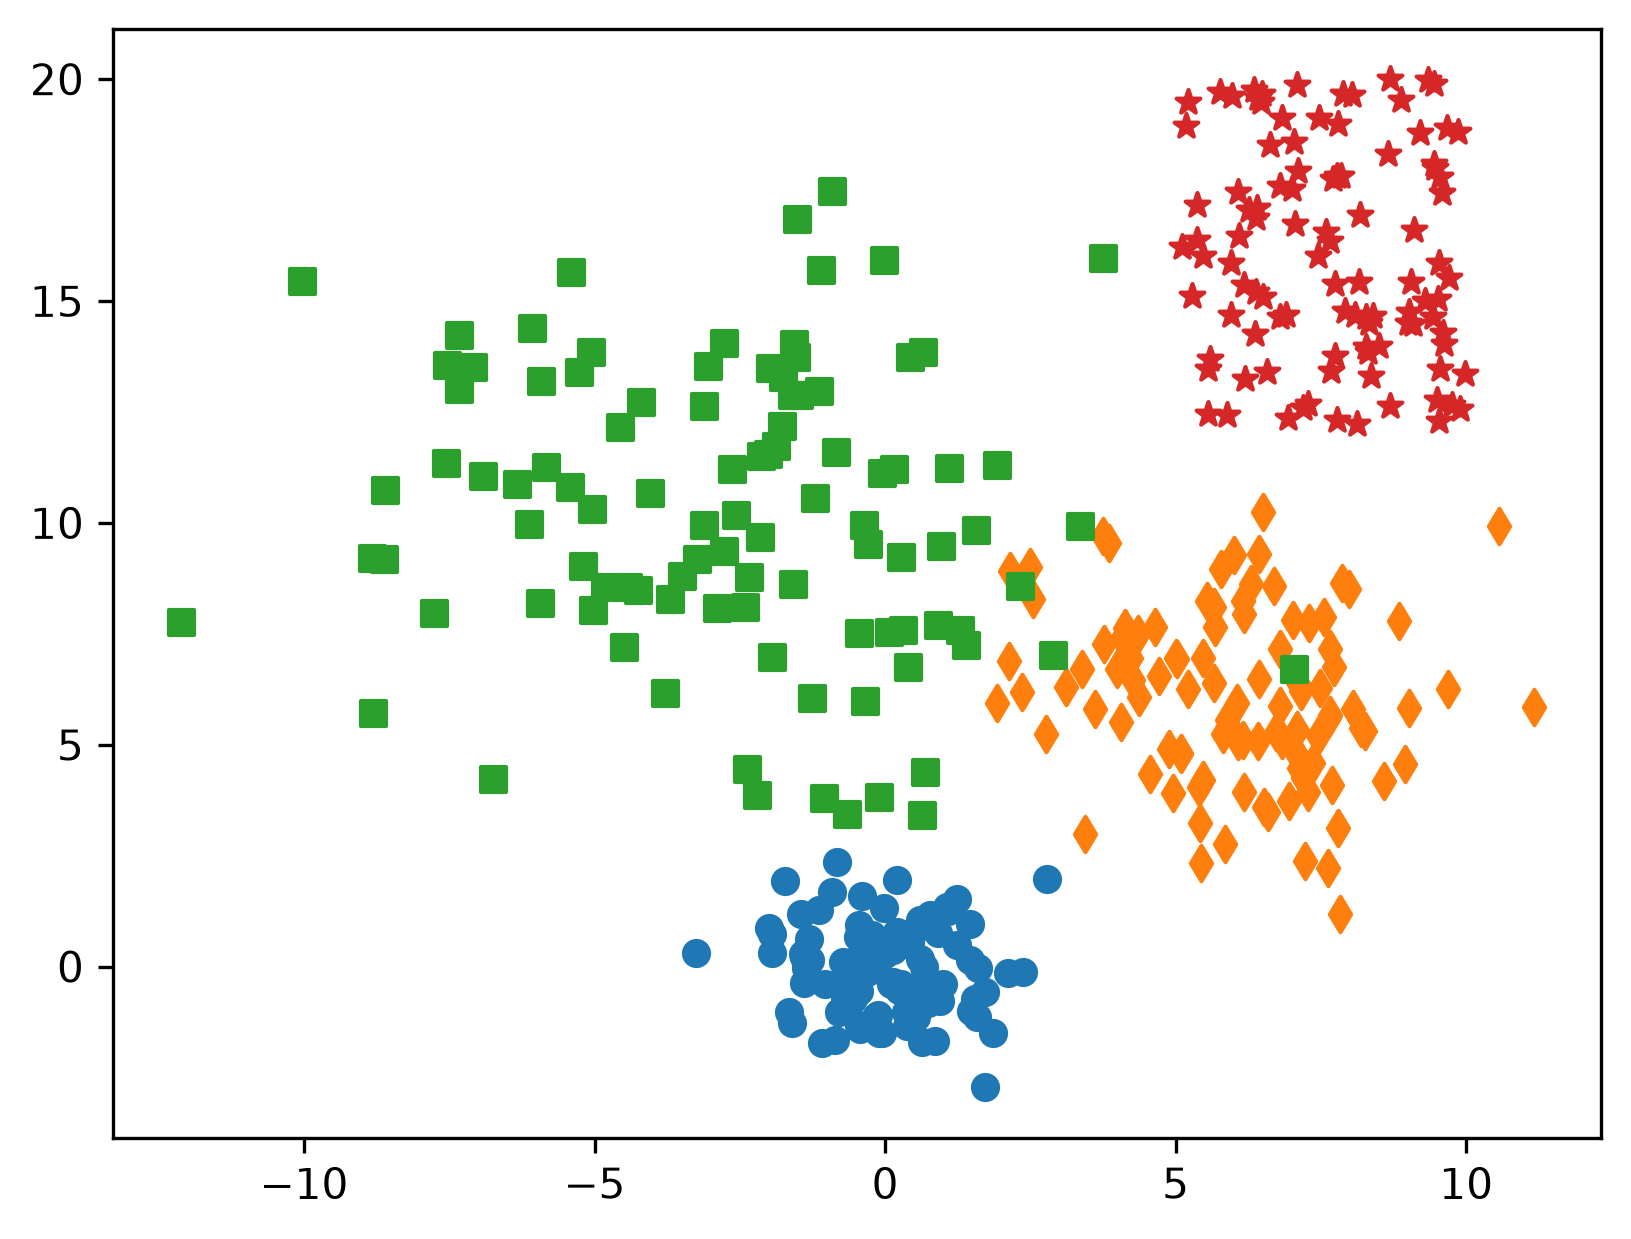

In [712]:
plt.scatter(xy1[:, 0], xy1[:, 1])
plt.scatter(xy2[:, 0], xy2[:, 1], marker='d')
plt.scatter(x3, y3, marker='s')
plt.scatter(x4, y4, marker='*');

Notice how, just like with lines, Matplotlib automatically cycled through a 10-color palette with every call of a plotting function (not with every data point, though!). 

But what can be done about all these overlapping points? Here are a few workarounds:
* Make the points smaller by setting the size `s` to a small number (some trial and error might be needed)
* Set the marker edge color `edgecolor` (or `ec`) to a different, darker color
* Change the alpha

Let's try the latter two methods:

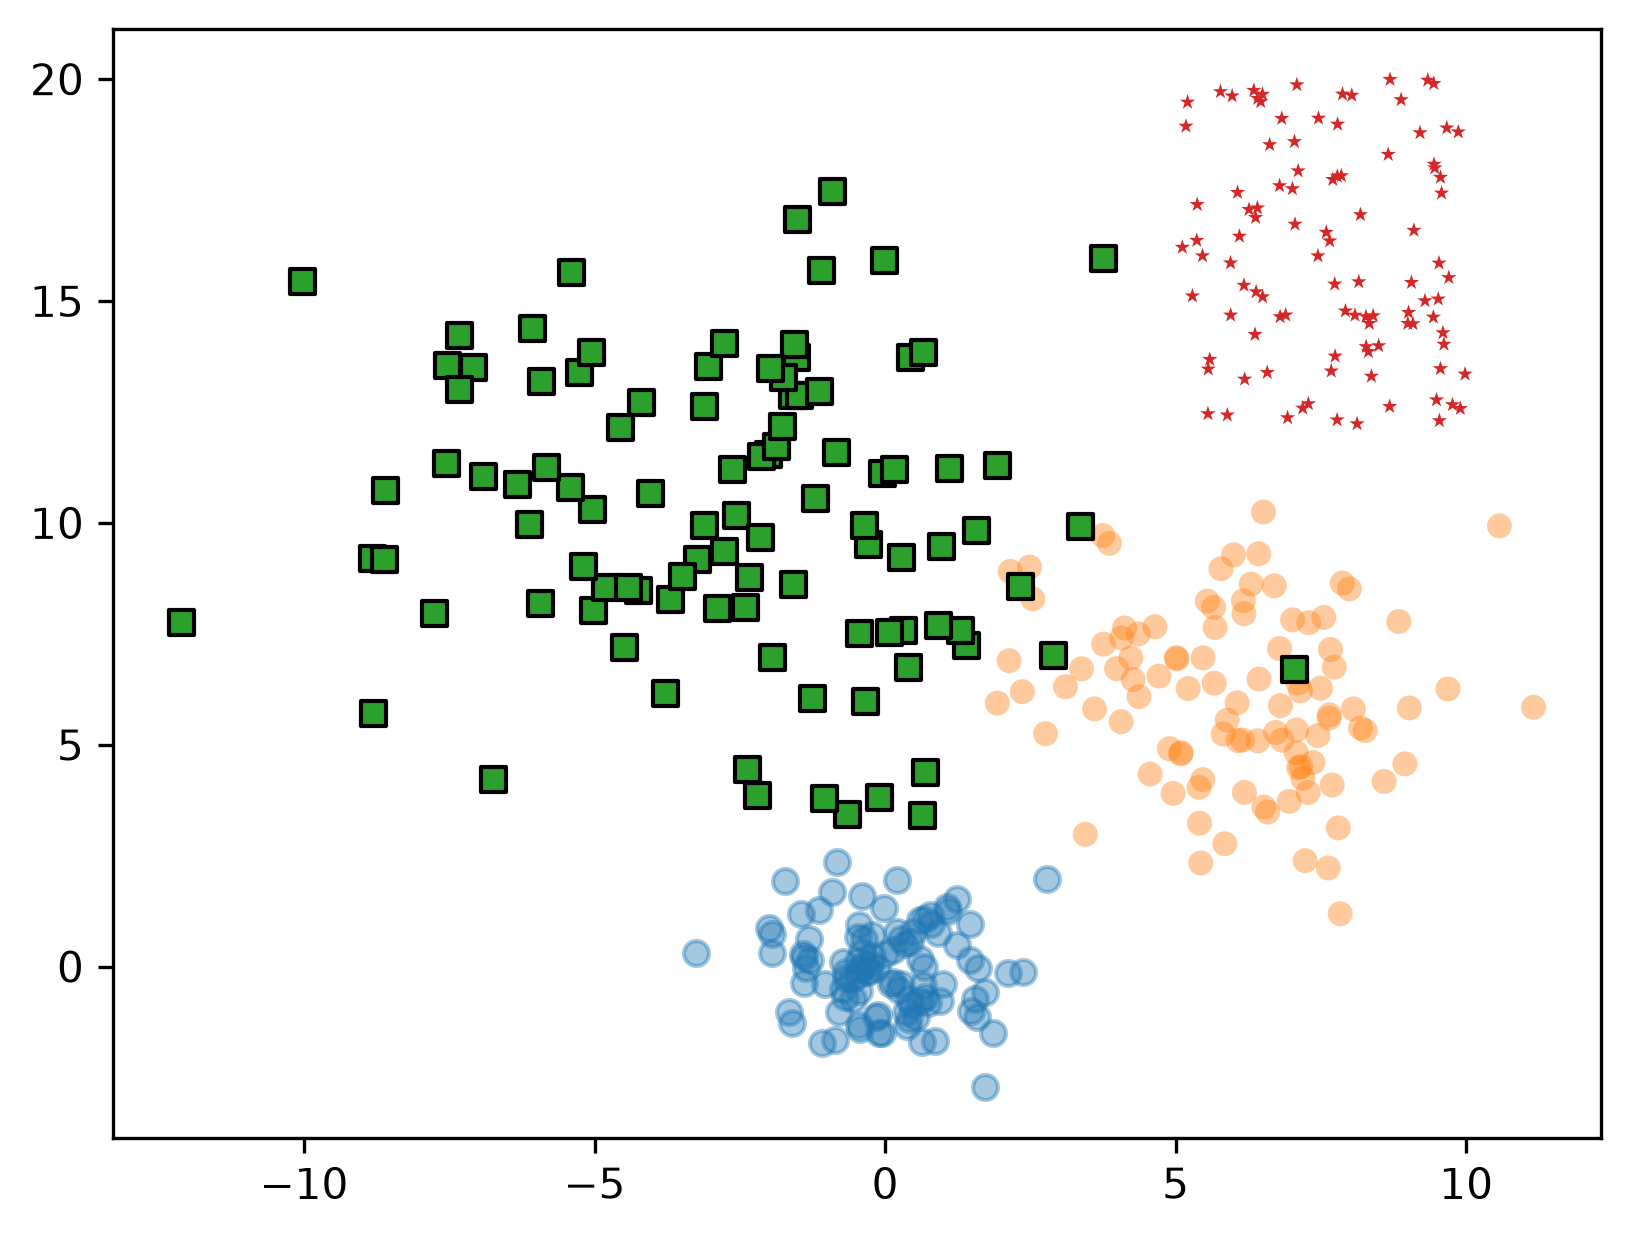

In [726]:
plt.scatter(xy1[:, 0], xy1[:, 1], 
            alpha=0.4)            # reducing alpha (making transparent)
plt.scatter(xy2[:, 0], xy2[:, 1], 
            alpha=0.4, ec="none") # reducing alpha and removing edge
plt.scatter(x3, y3, marker='s', 
            ec='k')               # making edge black
plt.scatter(x4, y4, marker='*', 
            ec="none", s=15);     # making markers smaller

Notice how the green markers are plotted **over** the orange ones. This is because we plotted the green markers **after** the orange ones. New plots will usually be drawn on top of old ones. To change the order on the plot, you could simply plot your data in a different order. You could also change the `zorder` argument, but it's a very finicky thing. 

### Fancy scatter plots

Scatter plots are really powerful because `scatter()` allows us to control the face color, edge color, size, and other features of each data point individually!

Let's start simple by only modifying marker size. This can be done with the `s` argument, which can be set to either a single number, which will draw the markers such that they are all of that same size), or an array of the same length as `x` and `y`, which will assign a "personalized" size for each marker. 

In the example below, I set the size argument, `s`, to equal the `y` data, so data points with greater `y` values will also be drawn proportionally bigger. To make the difference more obvious, I also multiply the sizes by 4:

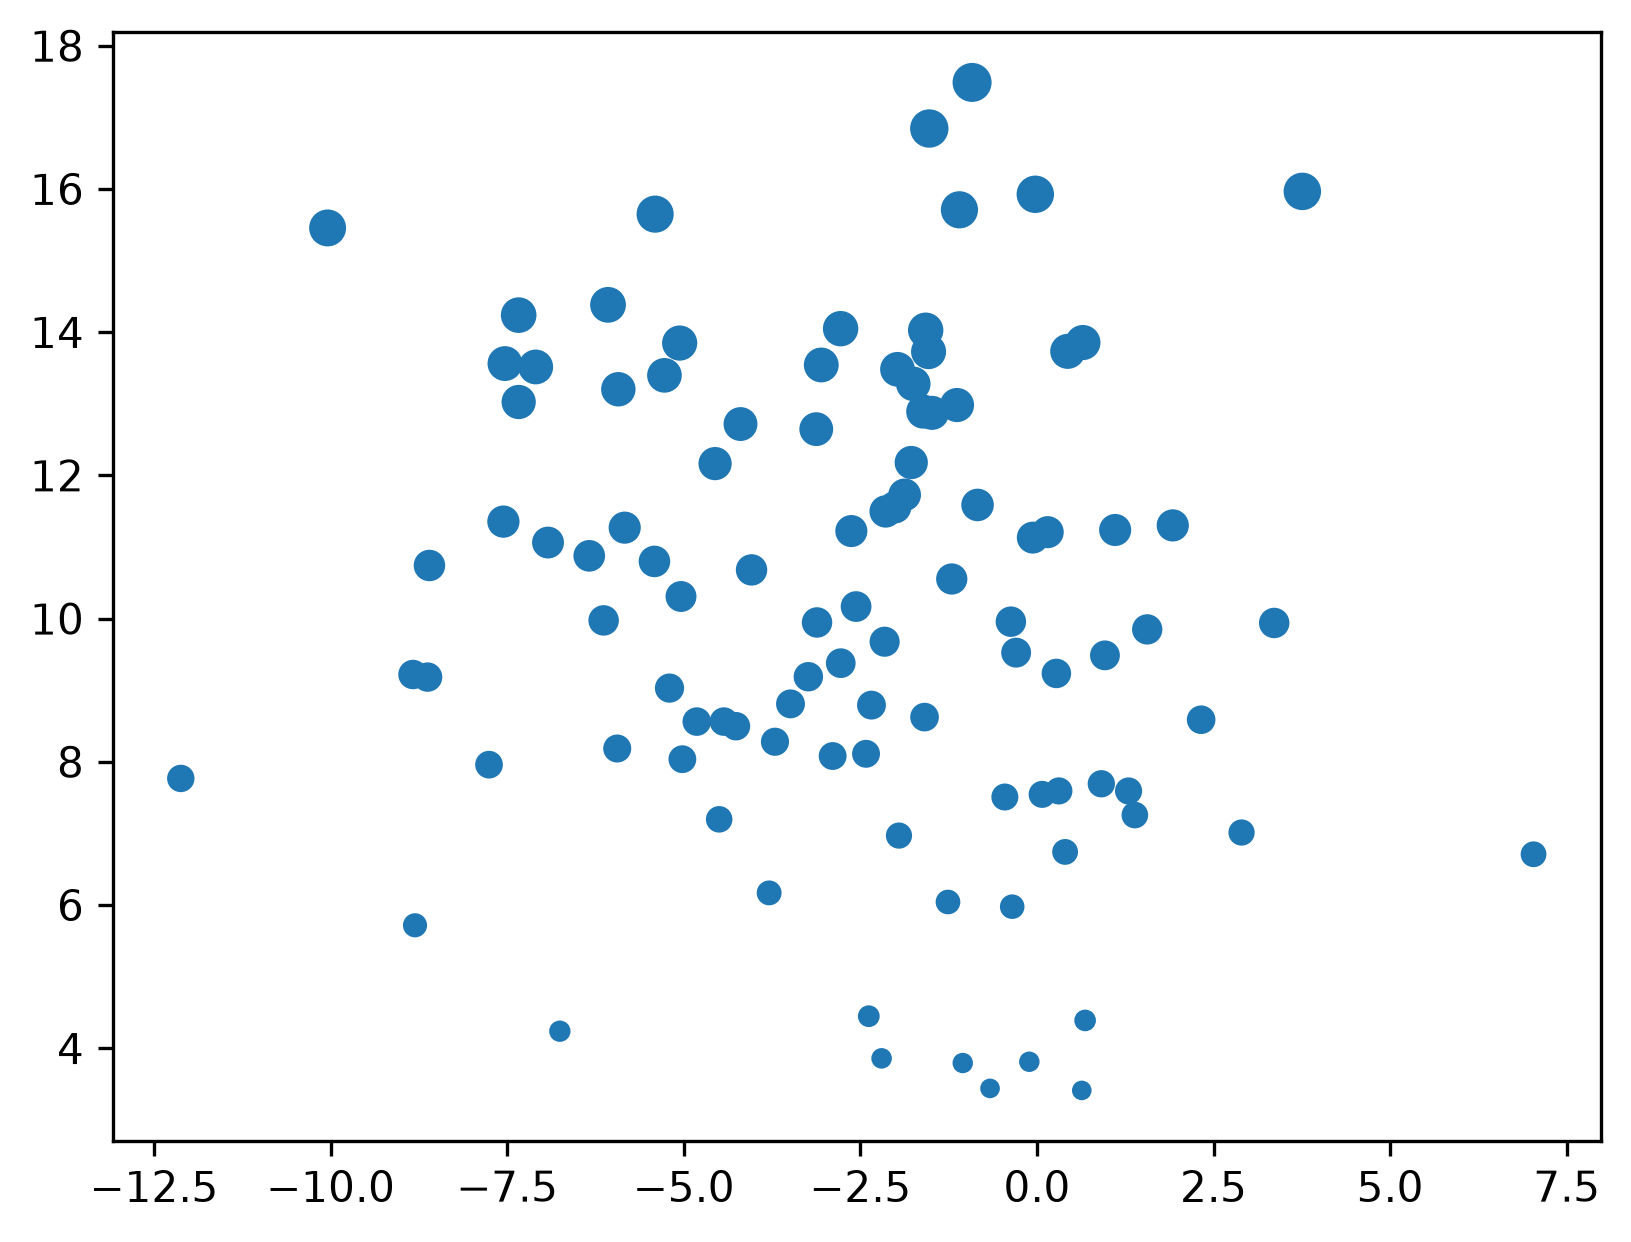

In [768]:
plt.scatter(x3, y3, s=y3*4);

Of course, the size data could be something else entirely, like a third variable you wish to visualize in addition to the 2 dimensions already plotted ($x$ and $y$).

Now let's get a even fancier. Scatter plots allow for full control of the color of each individual marker using the argument `c` (or `color`), which can be set to one of many things:
1. A single color, for all the points 
2. A list of colors of the same length as the data (i.e. `['r', 'g', 'b', 'k', 'tab:orange', 'xkcd:lavender', (0.2,0.3,0.8), ...]`)
3. A 2D array in which each row is an RGB or RGBA value (the A in RGBA stands for alpha, the opacity/transparency)
4. Coolest of all, a sequence of numbers as long as the data, which automatically get mapped to colors using a value-to-color map (aka a **color map**).

We already know how to do (1), (4) deserves its own section, so let's first try (2) and (3).

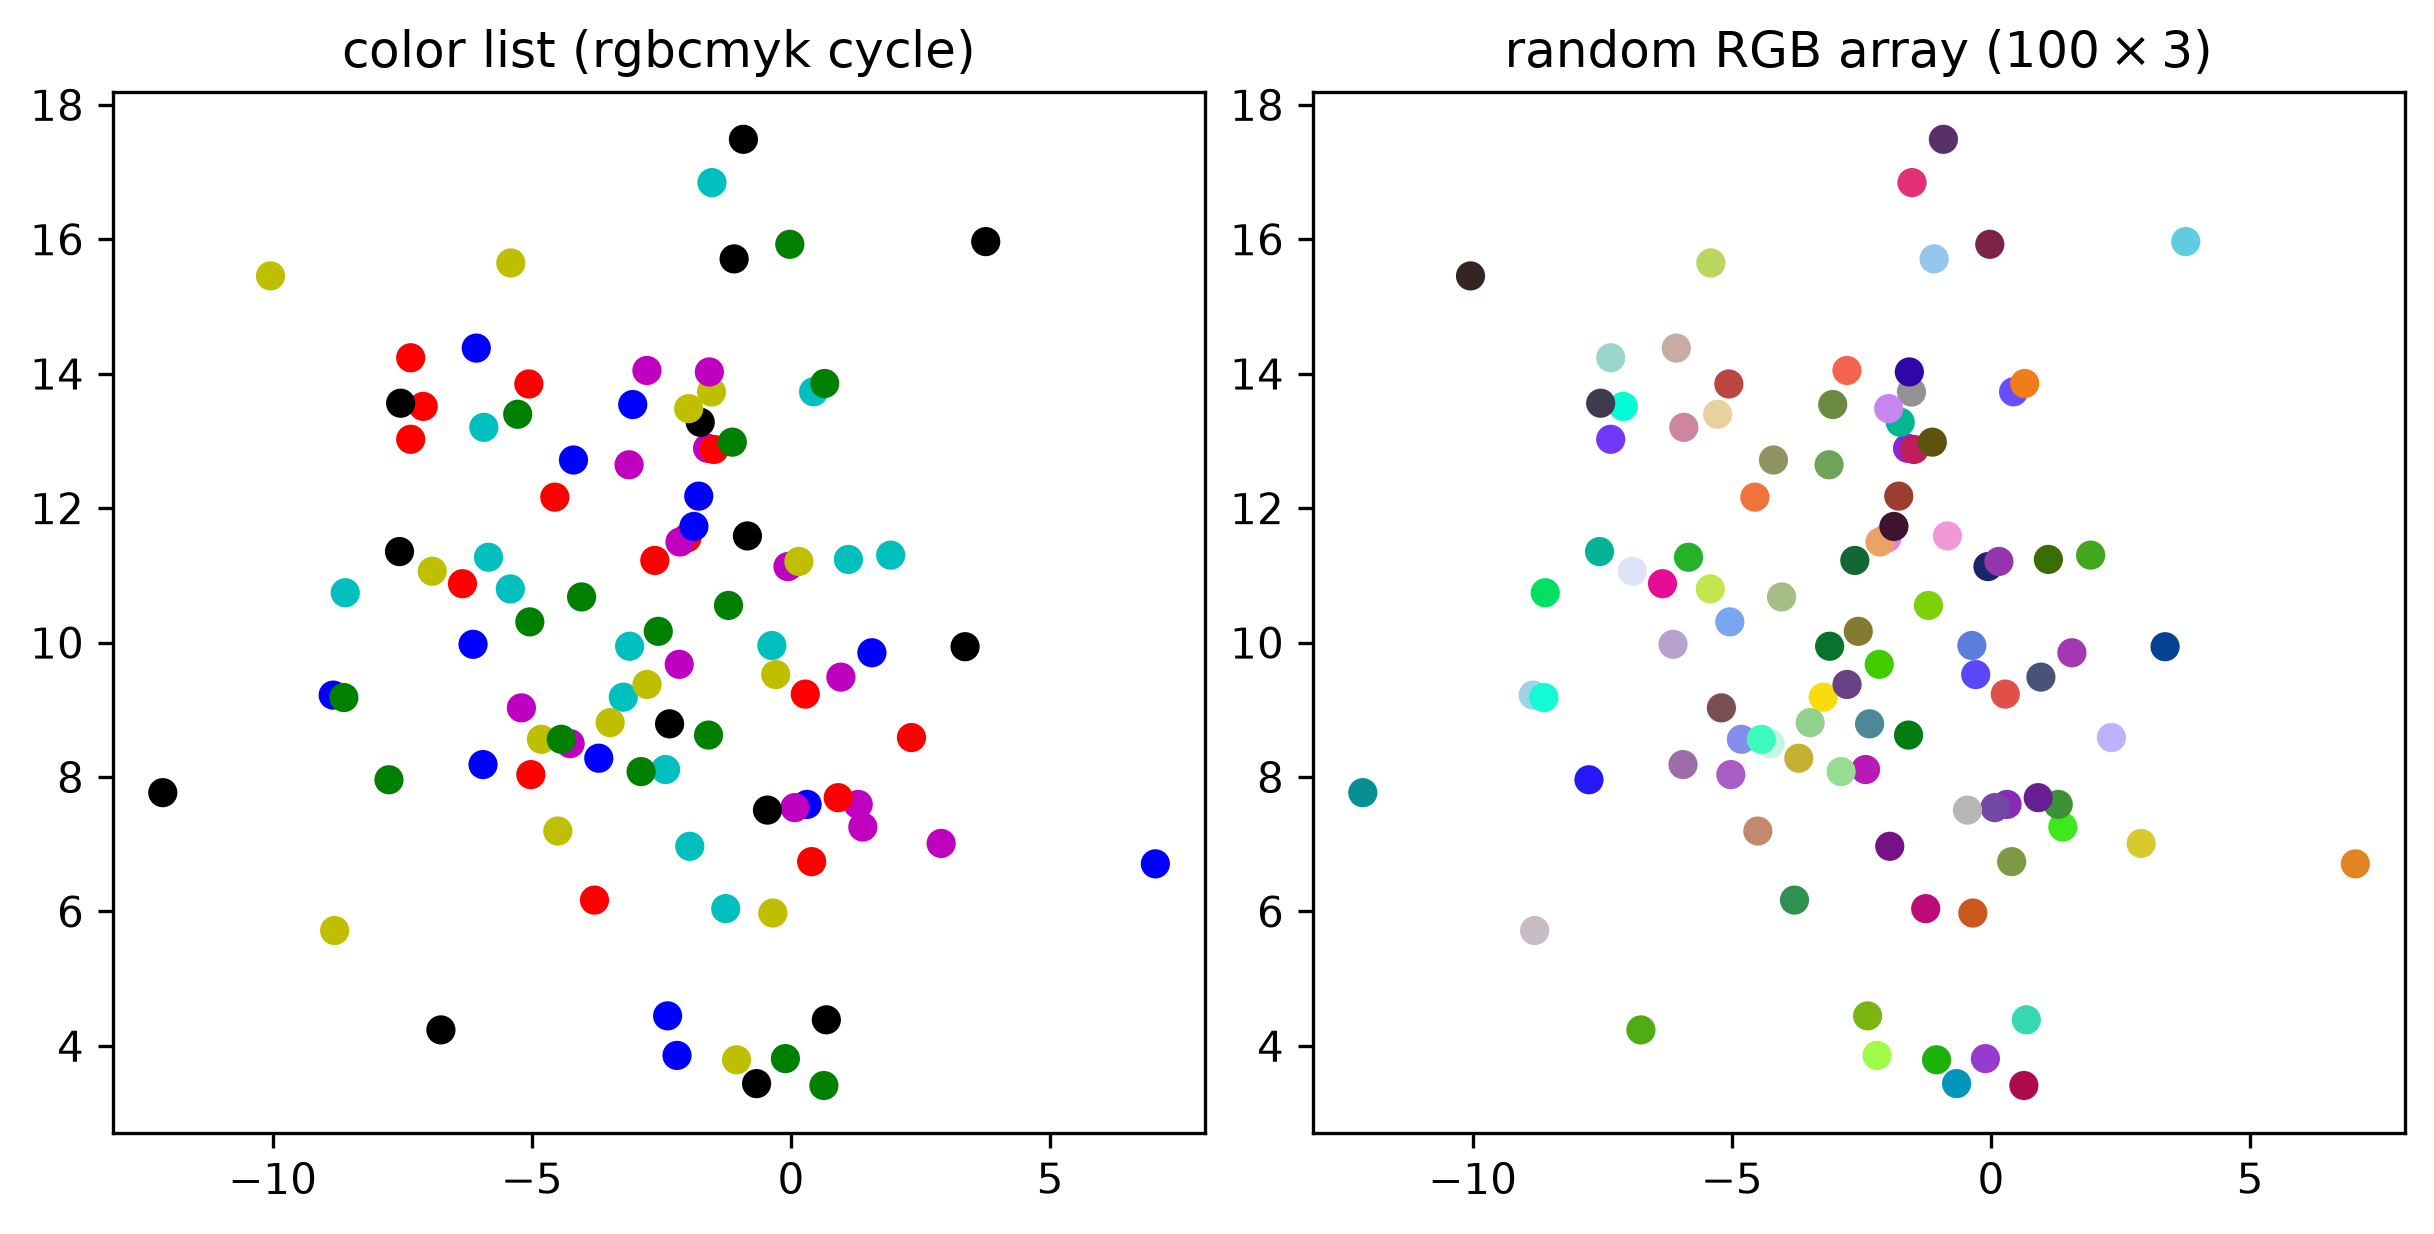

In [729]:
color_list = list('rgbcmyk') * 15 # list has 105 colors 
rgb_array = rng.uniform(0, 1, (100, 3))

fig, axes = plt.subplots(1,2, figsize=(8,4), layout='constrained')
axes[0].scatter(x3, y3, c=color_list[:100]) # select only first 100 colors in the list
axes[0].set_title('color list (rgbcmyk cycle)');
axes[1].scatter(x3, y3, c=rgb_array)
axes[1].set_title(r'random RGB array $(100 \times 3)$');

### Color maps and colorbars

Say you wanted to color the markers according to a third variable (other than x and y). For instance, really low values would be represented with a dark purple while really high values would be represented with a bright yellow, and everything in between would fall on the spectrum bounded by these two extremes. This called a **color map**, which takes a scalar value and maps it to the color that corresponds it.

Matplotlib makes color maps easy to handle. In the context of a scatter plot, all you need to do is provide (1) the data to be color mapped (with argument `c`) and, optionally, (2) the name of the color map (via the argument `cmap`). If the latter is not provided, the default is "viridis". A comprehensive list of Matplotlib color maps can be found [here, in the docs](https://matplotlib.org/stable/users/explain/colors/colormap-manipulation.html). These include sequential maps, diverging maps, cycling maps, and qualitative maps (used for qualitative data that does not have a mathematical order, like categories).

A color map almost always requires a **colorbar** to display the value meaning of the colors plotted. To add a colorbar, you can either call `fig.colorbar()` or `plt.colorbar()`. In either case you will usually need to define at least two things:
1) The object that is returned by the plotting function you just used, as this object contains the color map information that `colorbar()` needs (e.g. the color map itself, minumum value, and maximum value)
2) The `Axes` object to which the colorbar should be added. Other optional aesthetic arguments such as `location`, `orientation`, `shrink`, `label`, among others.  

In the example below, I simply set `c` to the y values `y3`, so the color map will be based on that data. But before we look at it, let's talk about th

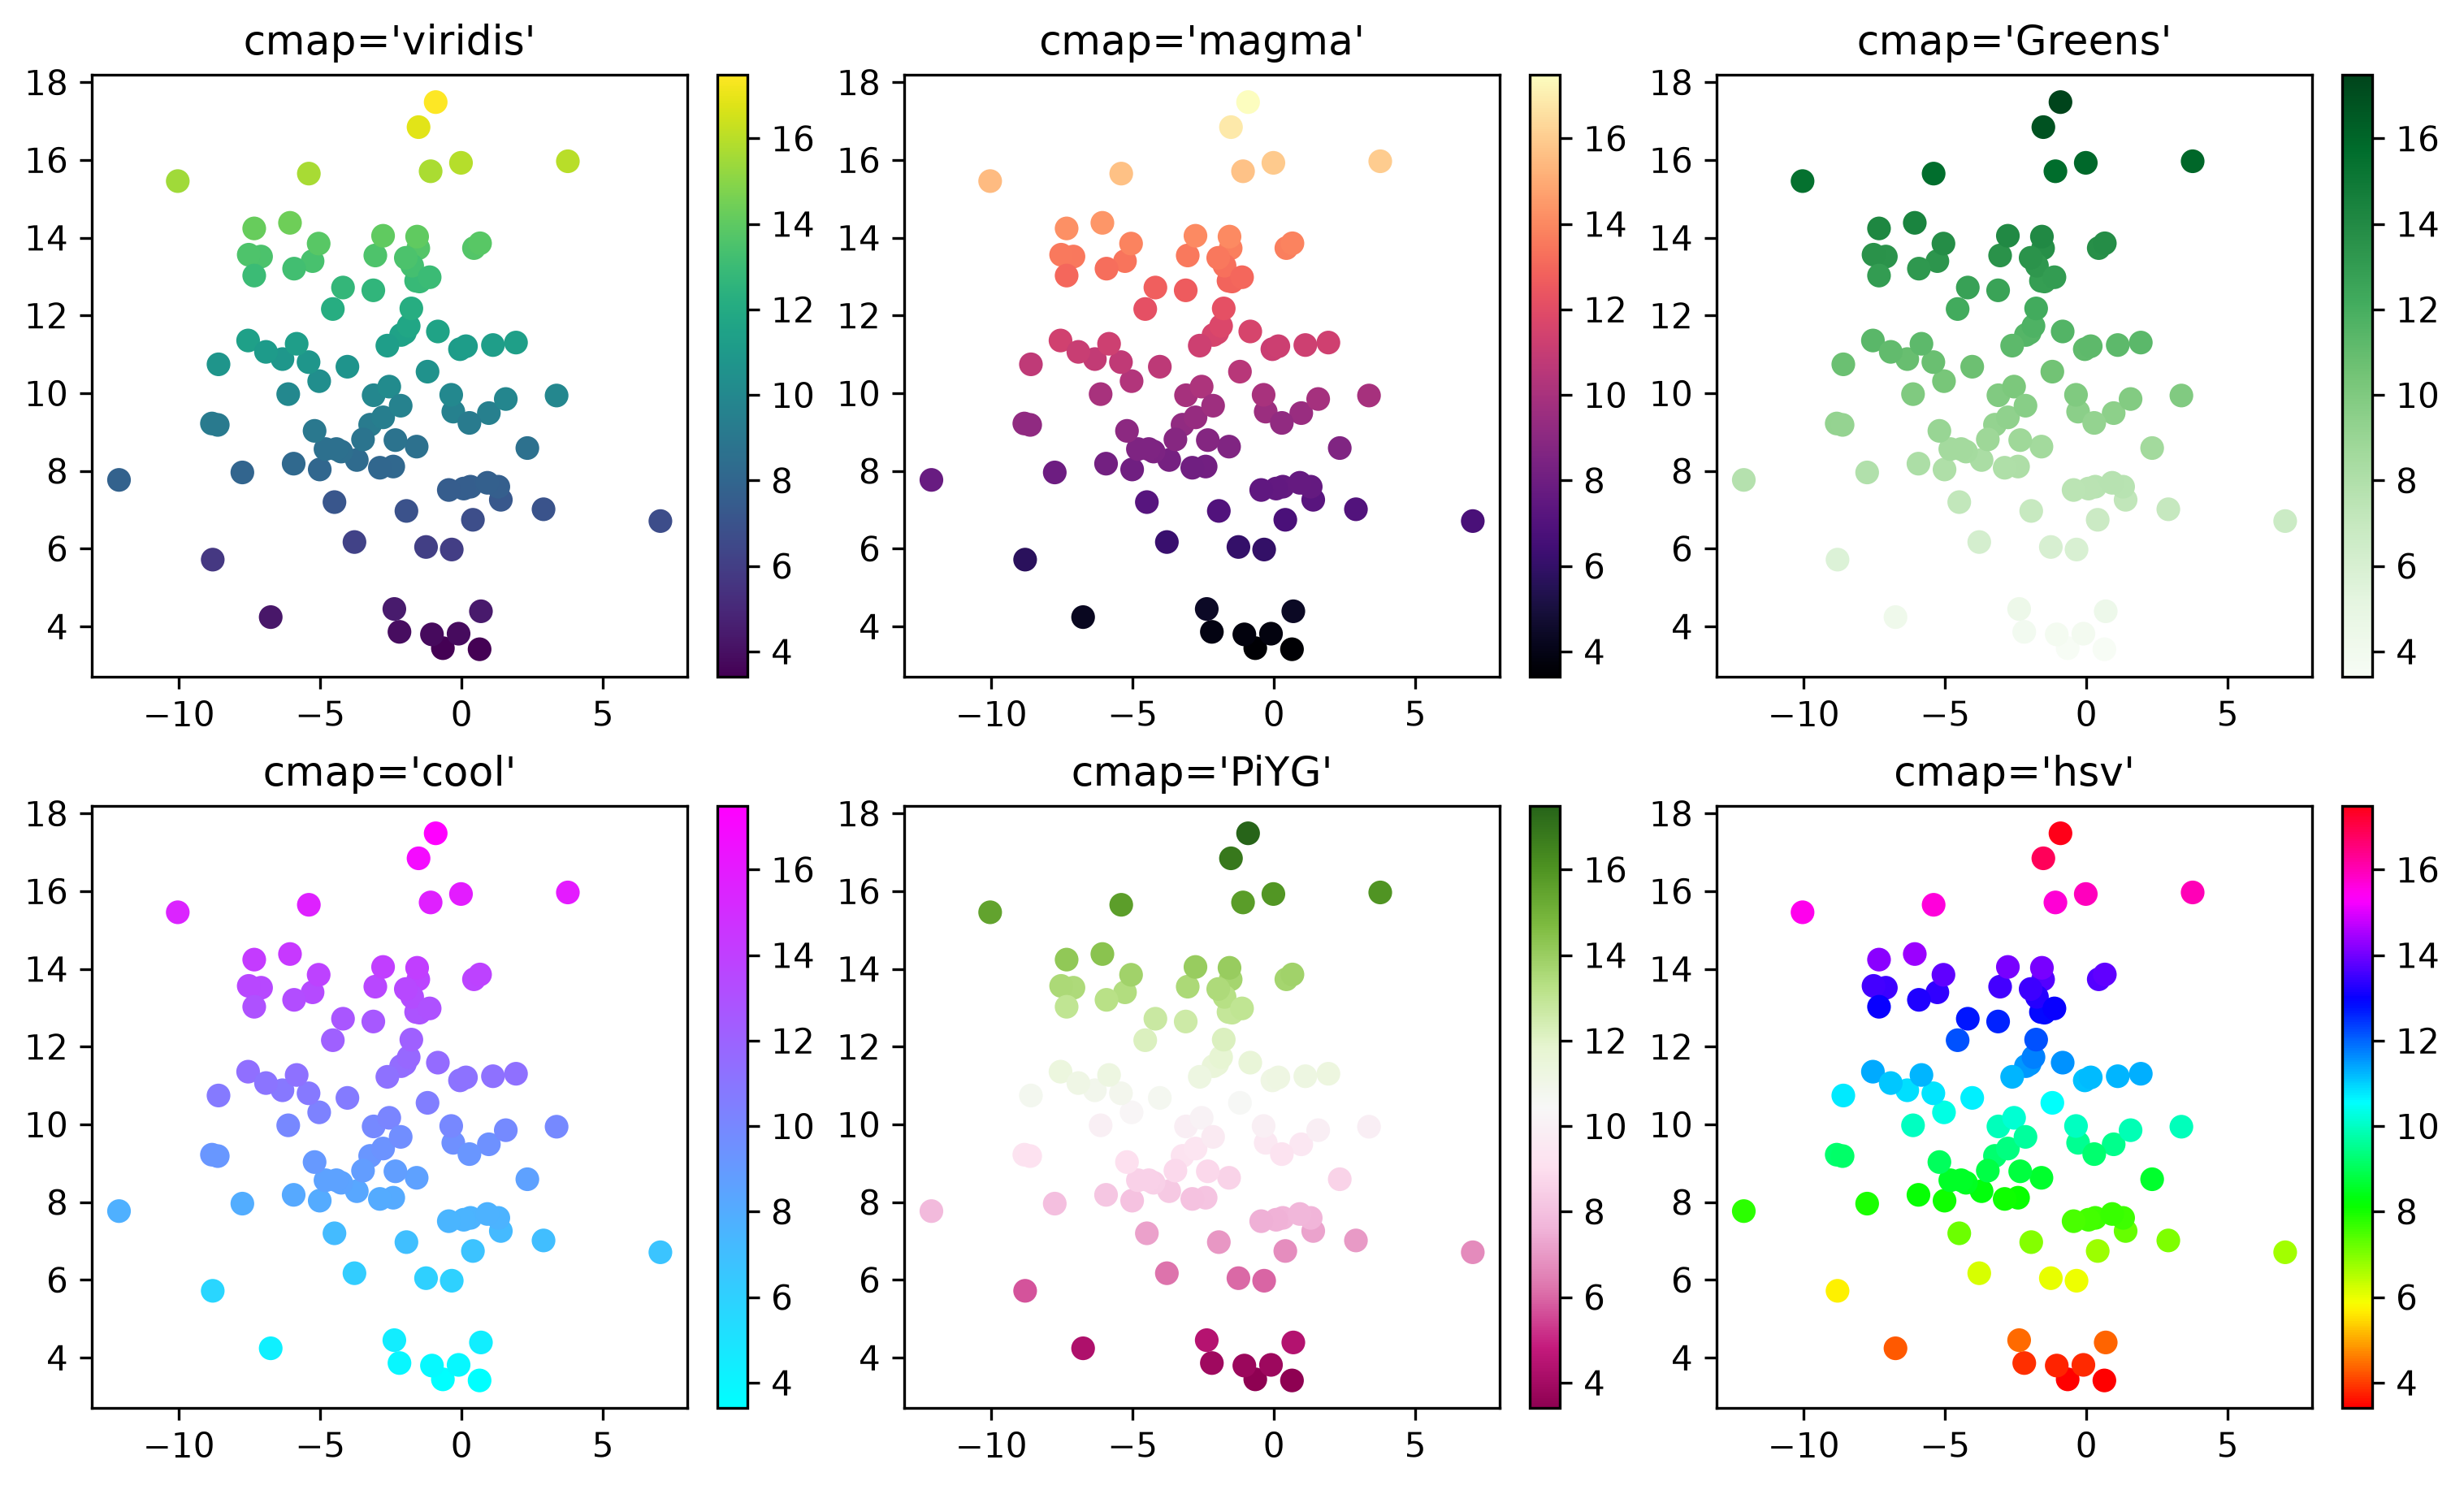

In [794]:
cmaps = ['viridis', 'magma', 'Greens', 'cool', 'PiYG', 'hsv']

fig, axes = plt.subplots(2,3,figsize=(10,6),layout='constrained')

for cmap, ax in zip(cmaps, axes.ravel()): # ravel() and flatten() turn axes from 2D to 1D flat array
    
    # make scatter plot and save the returned object for the colorbar
    scatterplot = ax.scatter(x3, y3, c=y3, cmap=cmap)

    # add the colorbar
    plt.colorbar(scatterplot, ax = ax, location='right')
    
    ax.set_title(f"cmap='{cmap}'")

### Legends

Not the storied myths, but close. When you plot more than one thing on the same graph, say with different colors or markers, a lengend allows you to clarify which color or markers represent which data sets.

One of the simplest ways to create a legend is to individually label each object you are plotting using the `label` argument, and then simply call `plt.legend()` or `ax.legend()`. There are many arguments that can be passed to legend to further customize its appearance, such as `loc` to specify its location (default is 'best', optimized by an algorithm to minimize overlap with data), `fontsize`, `facecolor`, `edgecolo`, `frameon`, `title`, `alignment`, and many, many more, all of which can be found in the `legend()` [docs here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html#matplotlib.pyplot.legend).

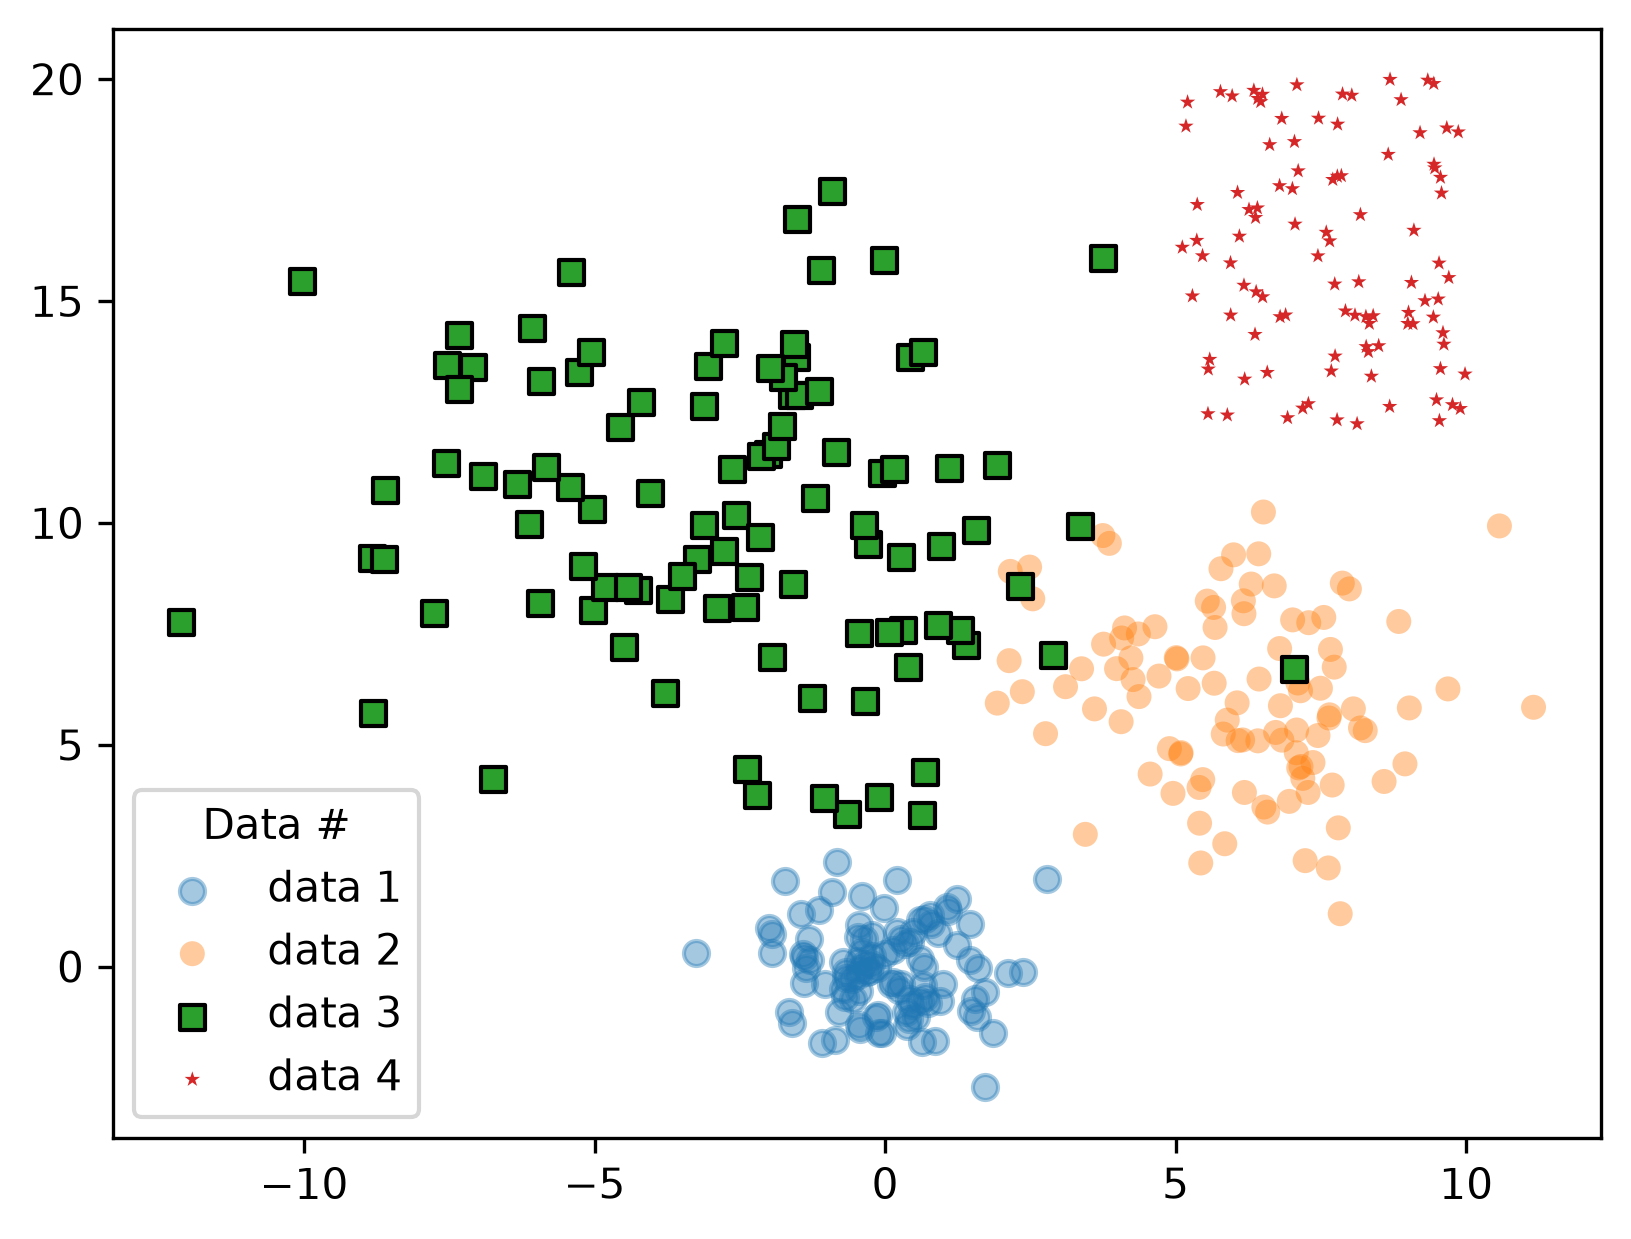

In [802]:
plt.scatter(xy1[:, 0], xy1[:, 1], alpha=0.4, label = "data 1")            
plt.scatter(xy2[:, 0], xy2[:, 1], alpha=0.4, ec="none", label = "data 2") 
plt.scatter(x3, y3, marker='s', ec='k', label = "data 3")               
plt.scatter(x4, y4, marker='*', ec="none", s=15, label = "data 4");

plt.legend(loc='lower left', title='Data #');

### Axis scales

Data can often come distributed in ways that make it hard to visualize it all on a simple linear scale. For instance, if plotting a dose-response curve where the doses are at different orders of magnitude, the smallest doses will be so close to each other they will appear indistinguishable from one another. Another very common example in immunology is flow cytometry signals: the spectrum from positive to negative expression can span multiple orders of magnitude!

To visualize this, let's generate samples from a log-normal distribution, which is a distribution which becomes normal when you take its natural log. To generate it, we simply generate Normal-distributed samples $X_i$ and compute $e^{X_i}$ (thus, when taking the natural log of $e^{X_i}$, we get $X_i$ back!):

In [1285]:
x = np.vstack([
    rng.multivariate_normal([0,0], np.eye(2), 300),    # double negative population
    rng.multivariate_normal([10,10], np.eye(2)*3, 300) # double positive population
])
ex = np.exp(x)

Now let's make a scatter plot:

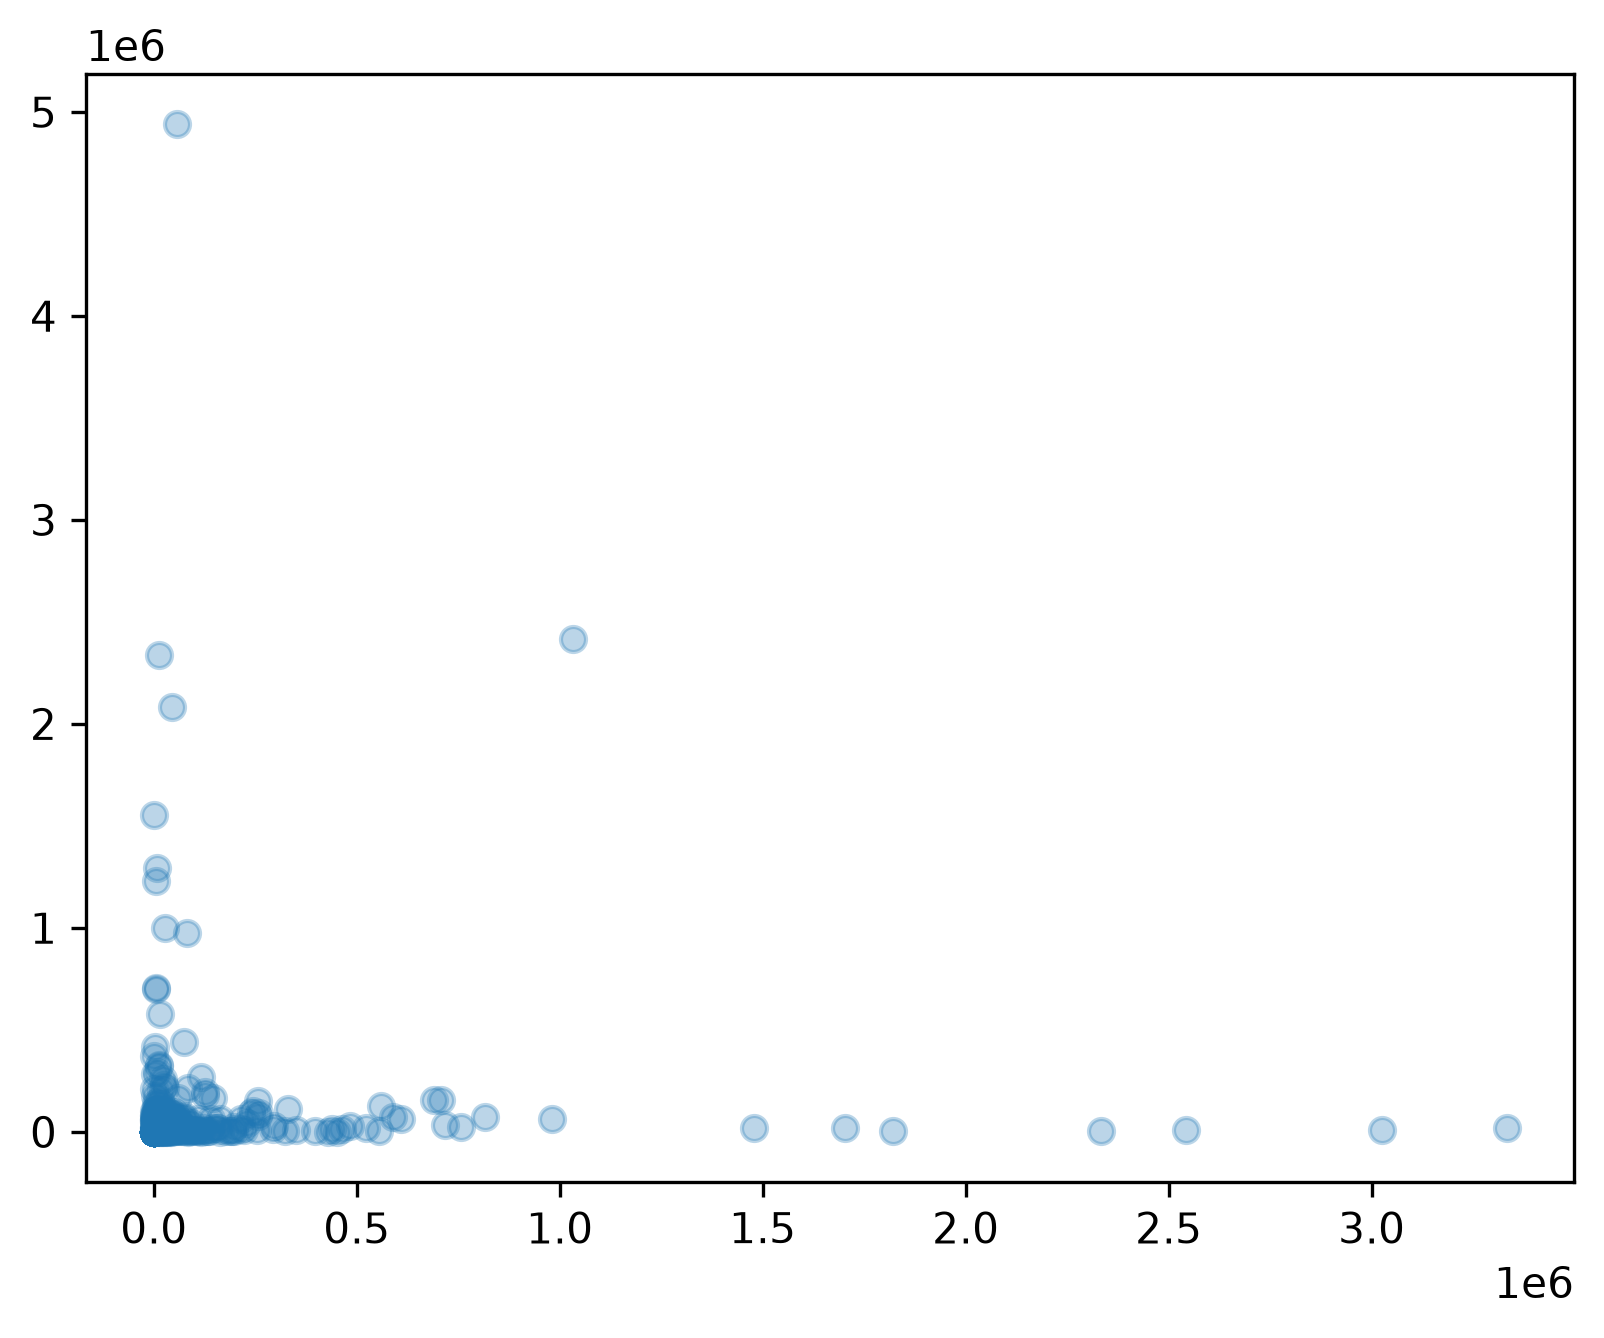

In [1289]:
plt.scatter(ex[:, 0], ex[:, 1], alpha=0.3);

Wow.. there really isn't much to see here. Now let's set both x and y scales as logarithmic:

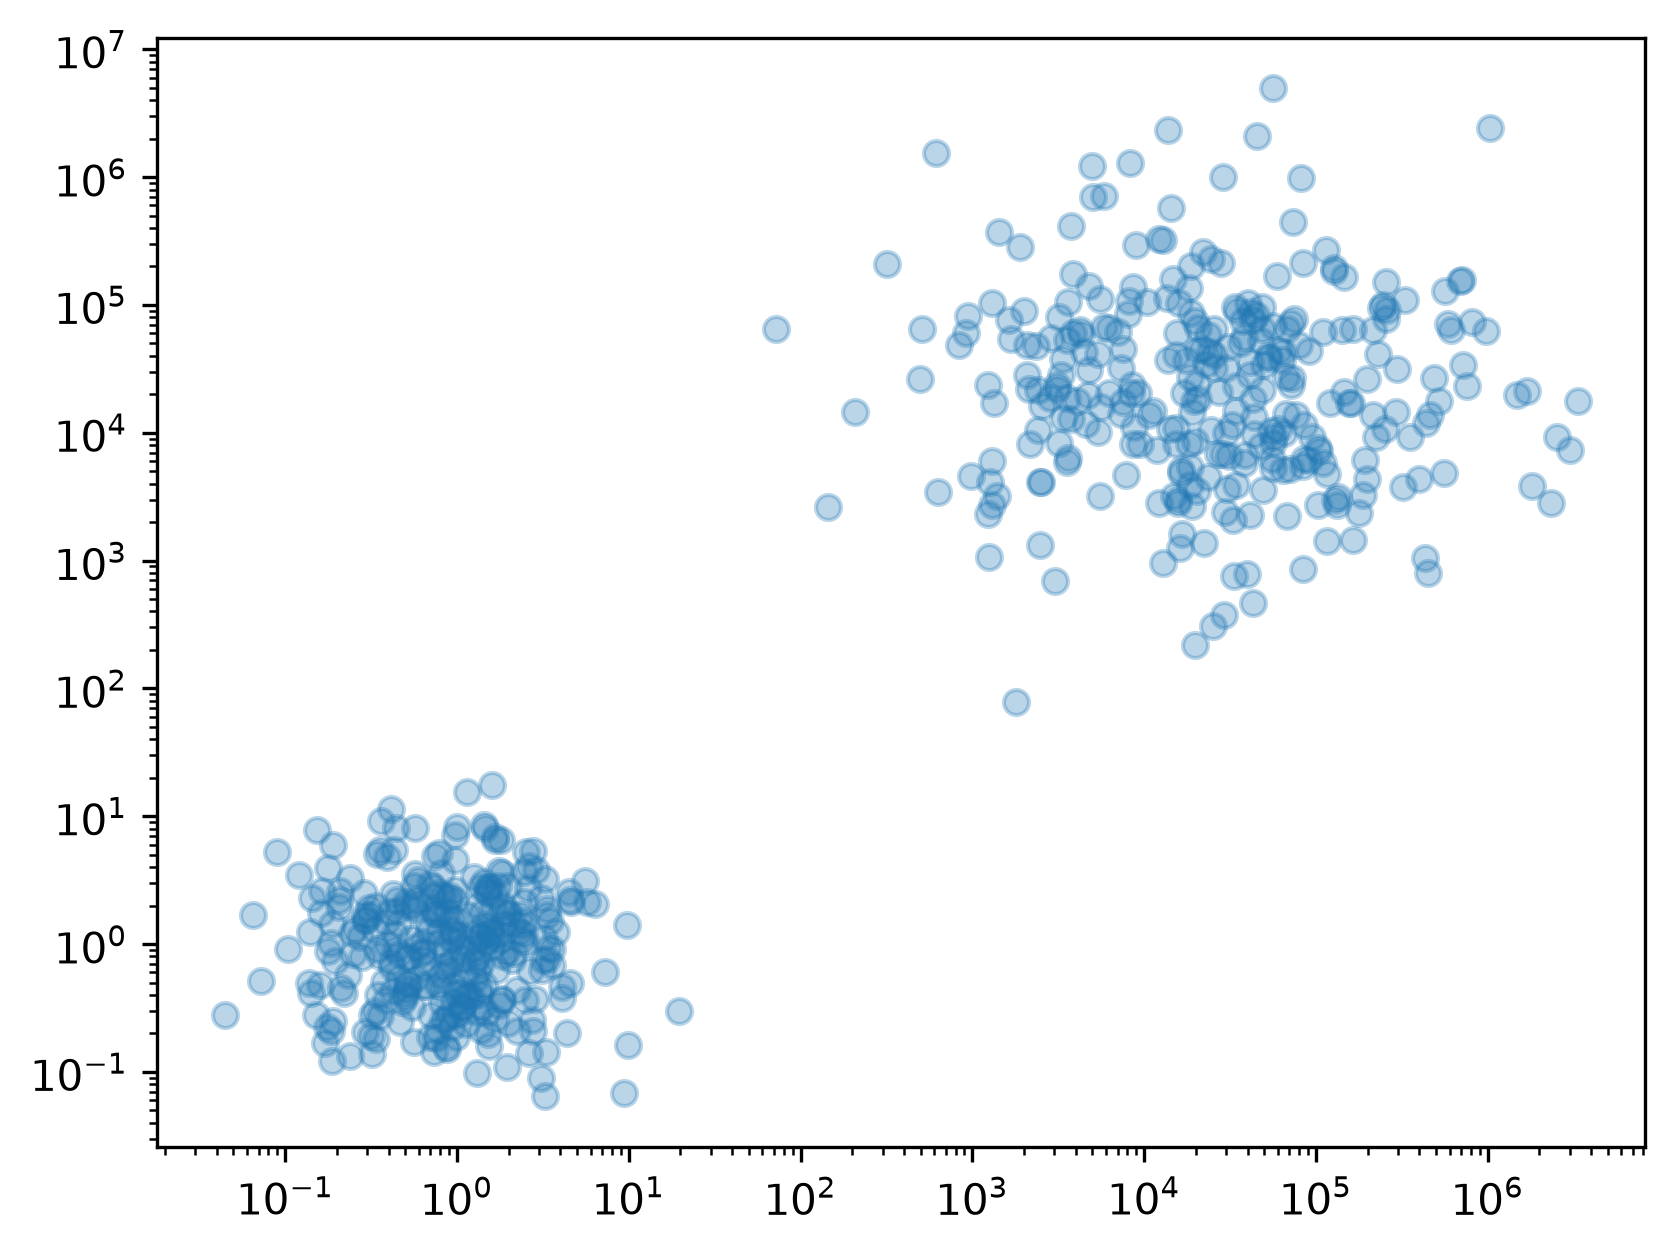

In [1291]:
plt.scatter(ex[:, 0], ex[:, 1], alpha=0.3)
plt.xscale('log')
plt.yscale('log');

Wow! Now the two population are so much clearer to see! Notice how the default base of the log is 10, but that can be easily changed to any base of your choice.

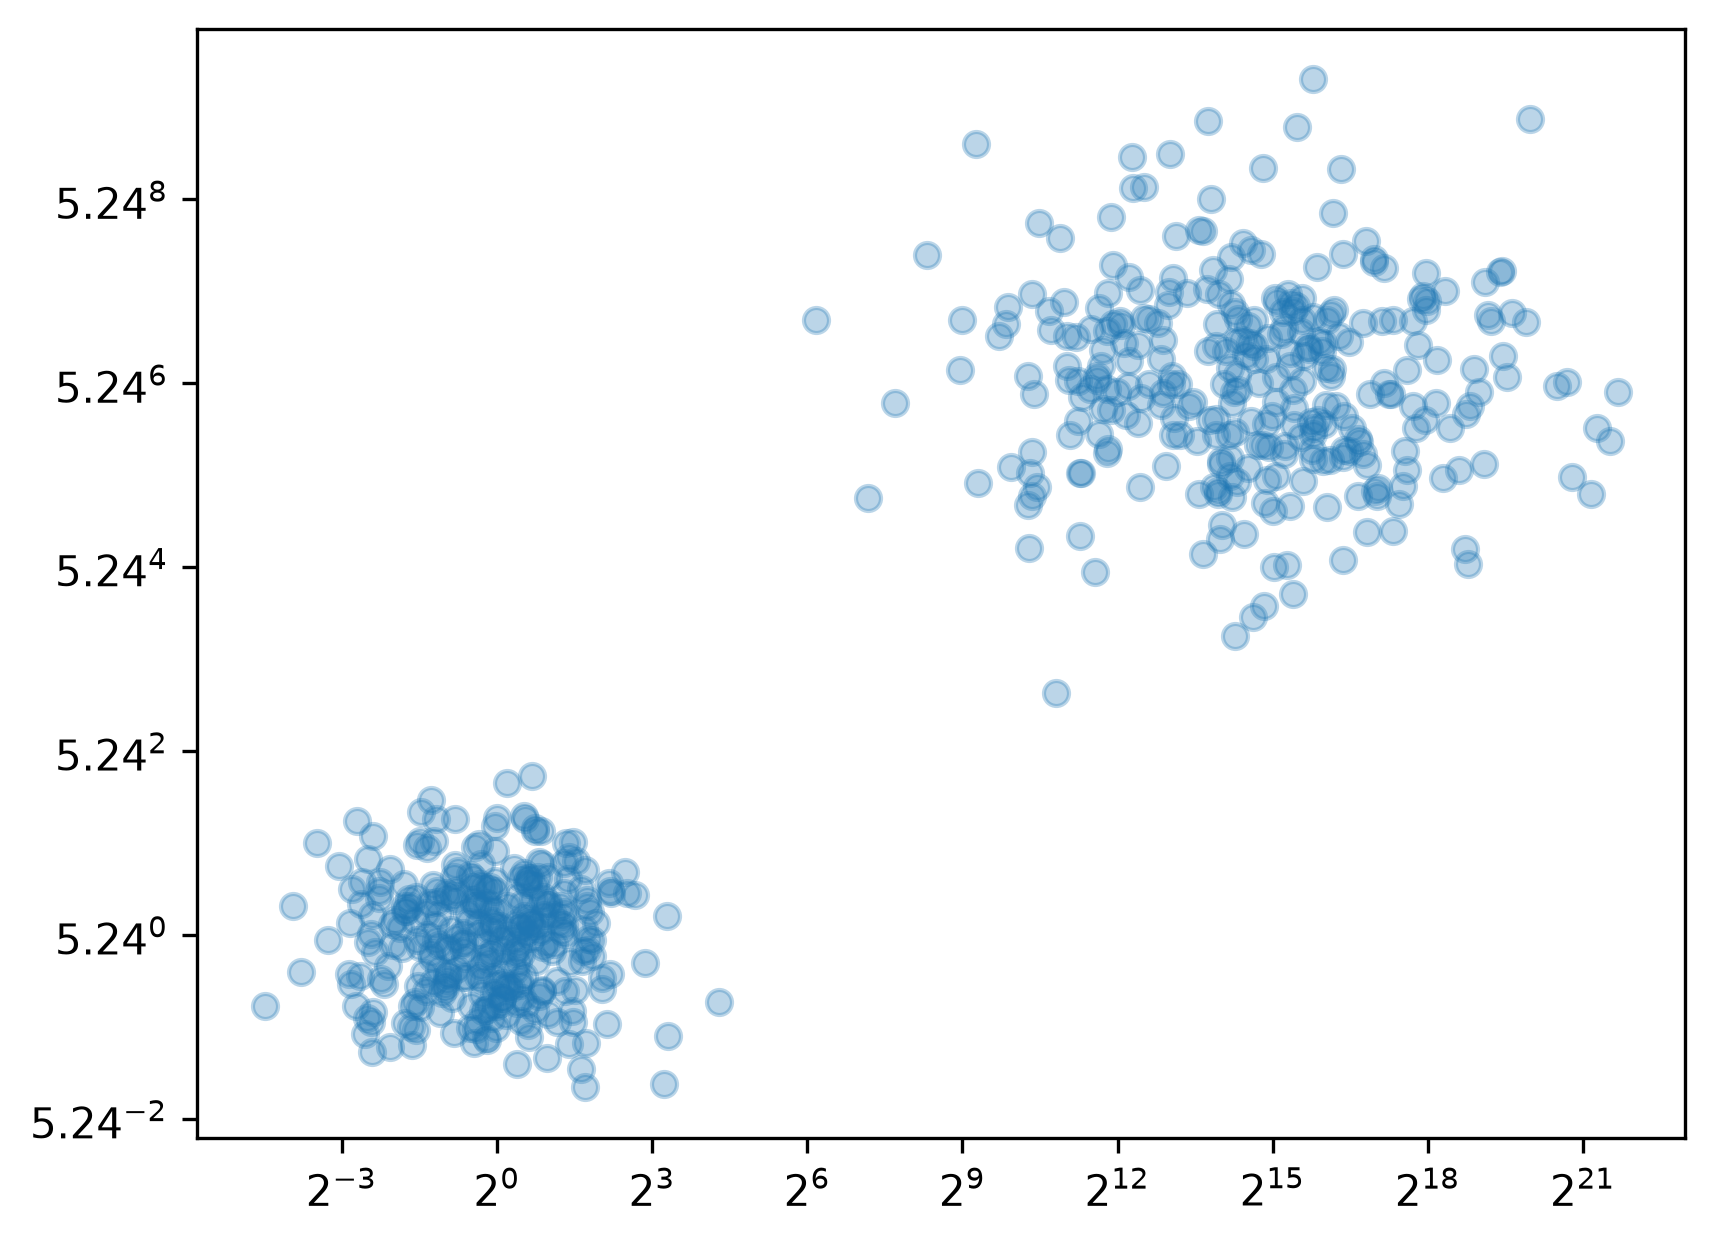

In [1301]:
plt.scatter(ex[:, 0], ex[:, 1], alpha=0.3)
plt.xscale('log', base=2)
plt.yscale('log', base=5.24);

Although it will change the look of the axes affected, it will not change the data or the shape of the distribution.

Please note that `plt.xscale()` and `plt.yscale()` become `ax.set_xscale()` and `ax.set_yscale()` in the object-oriented coding style. Since these functions are very popular, Matplotlib also offers some very convenient helper functions like `semilogx()`, `semilogy()`, and `loglog()`:

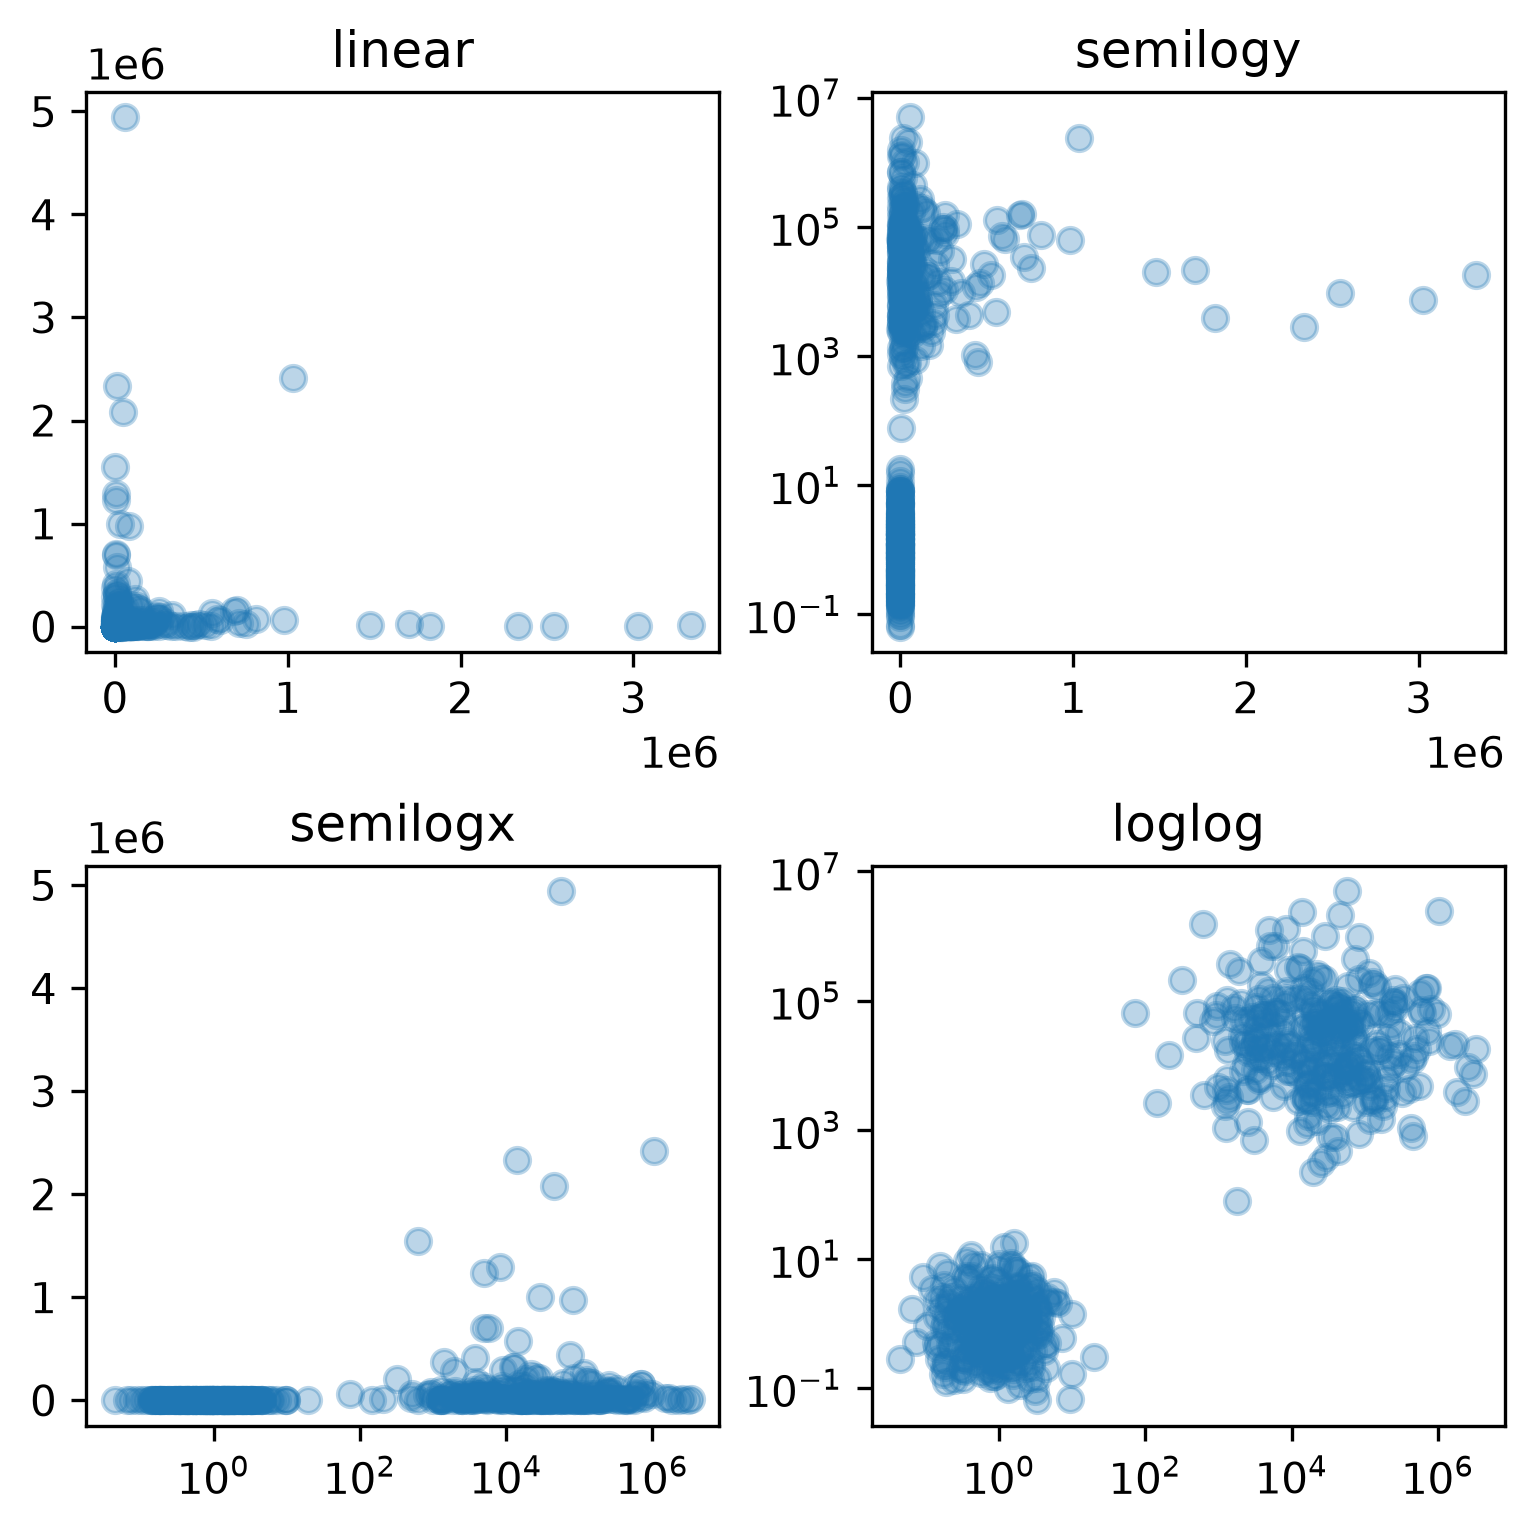

In [1304]:
fig, axs = plt.subplots(2,2, figsize=(5,5), layout='constrained')
scales = [None, 'semilogy', 'semilogx', 'loglog']

for ax, scale in zip(axs.ravel(), scales):
    ax.scatter(ex[:, 0], ex[:, 1], alpha=0.3)
    if scale:
        set_scale = getattr(ax, scale)
        set_scale()
        ax.set_title(scale)
    else:
        ax.set_title('linear')

### Bar charts

Plotting bar charts is easily done with `plt.bar()` or `ax.bar()`, which take the following arguments:
- `x`: can either be a list of numbers each representing the position of a bar on the x axis, or eeve more conveniently, the list of category names corresponding to each bar (Matplotlib will automatically assign them spots on the x axis)
- `height`: the heights of the bars.

And optionally:
- `width`: the width of the bars (default 0.8, so 80% of the space between two integers)
- `bottom`: the bottom of the bars (default 0)
- `align`: how to align the bars and x positions; either `center` (the default value) or `edge` (the left edge of the bar aligns with the x position).

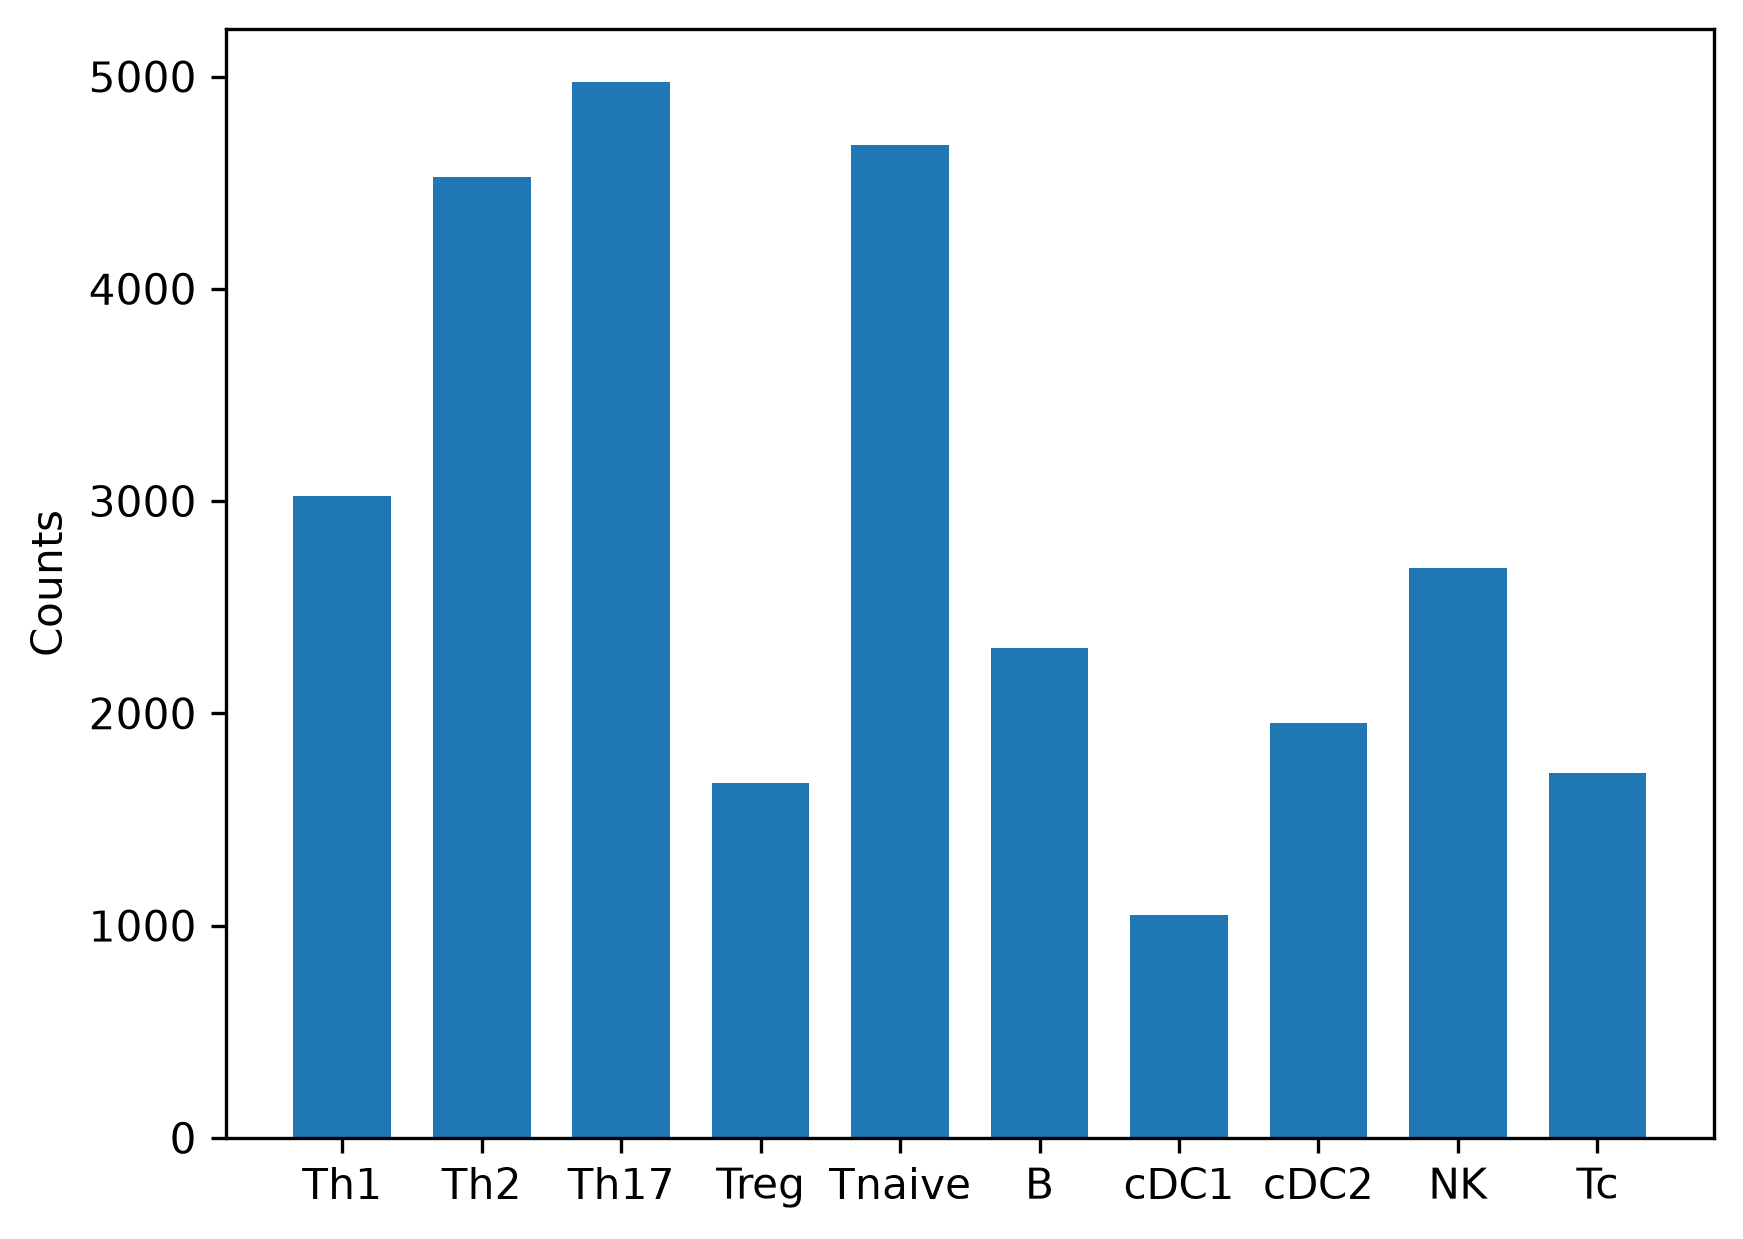

In [854]:
cells = ['Th1', 'Th2', 'Th17', 'Treg', 'Tnaive', 'B', 'cDC1', 'cDC2', 'NK', 'Tc']
counts = rng.uniform(100, 5000, size=10).round()

plt.bar(cells, counts, width=0.7, align='center')
plt.ylabel('Counts');

### Stacked bar charts

Bar charts can be easily stacked by changing the `bottom` parameter of each stacked bar to match the `height` paramter of the bars underneath.

In this example, each bar represents a sample and each sample is a stack of bars that each represent a cell type.

In [896]:
samples = [f"sample_{i}" for i in range(7)]
cell_types = ['Th', 'Tc', 'B', 'NK']

# generate counts randomly: 4 rows (cell types), 7 columns (samples)
counts = rng.uniform(200, 5000, size=(4,7)).round()
counts

array([[1830., 1285., 4274., 3184., 1013.,  764., 4295.],
       [1192., 1286., 4977., 3225.,  371., 4051., 2746.],
       [2797., 3279., 4314., 3682.,  502., 2587., 4374.],
       [3058., 2397., 1617.,  613.,  793., 2735., 4410.]])

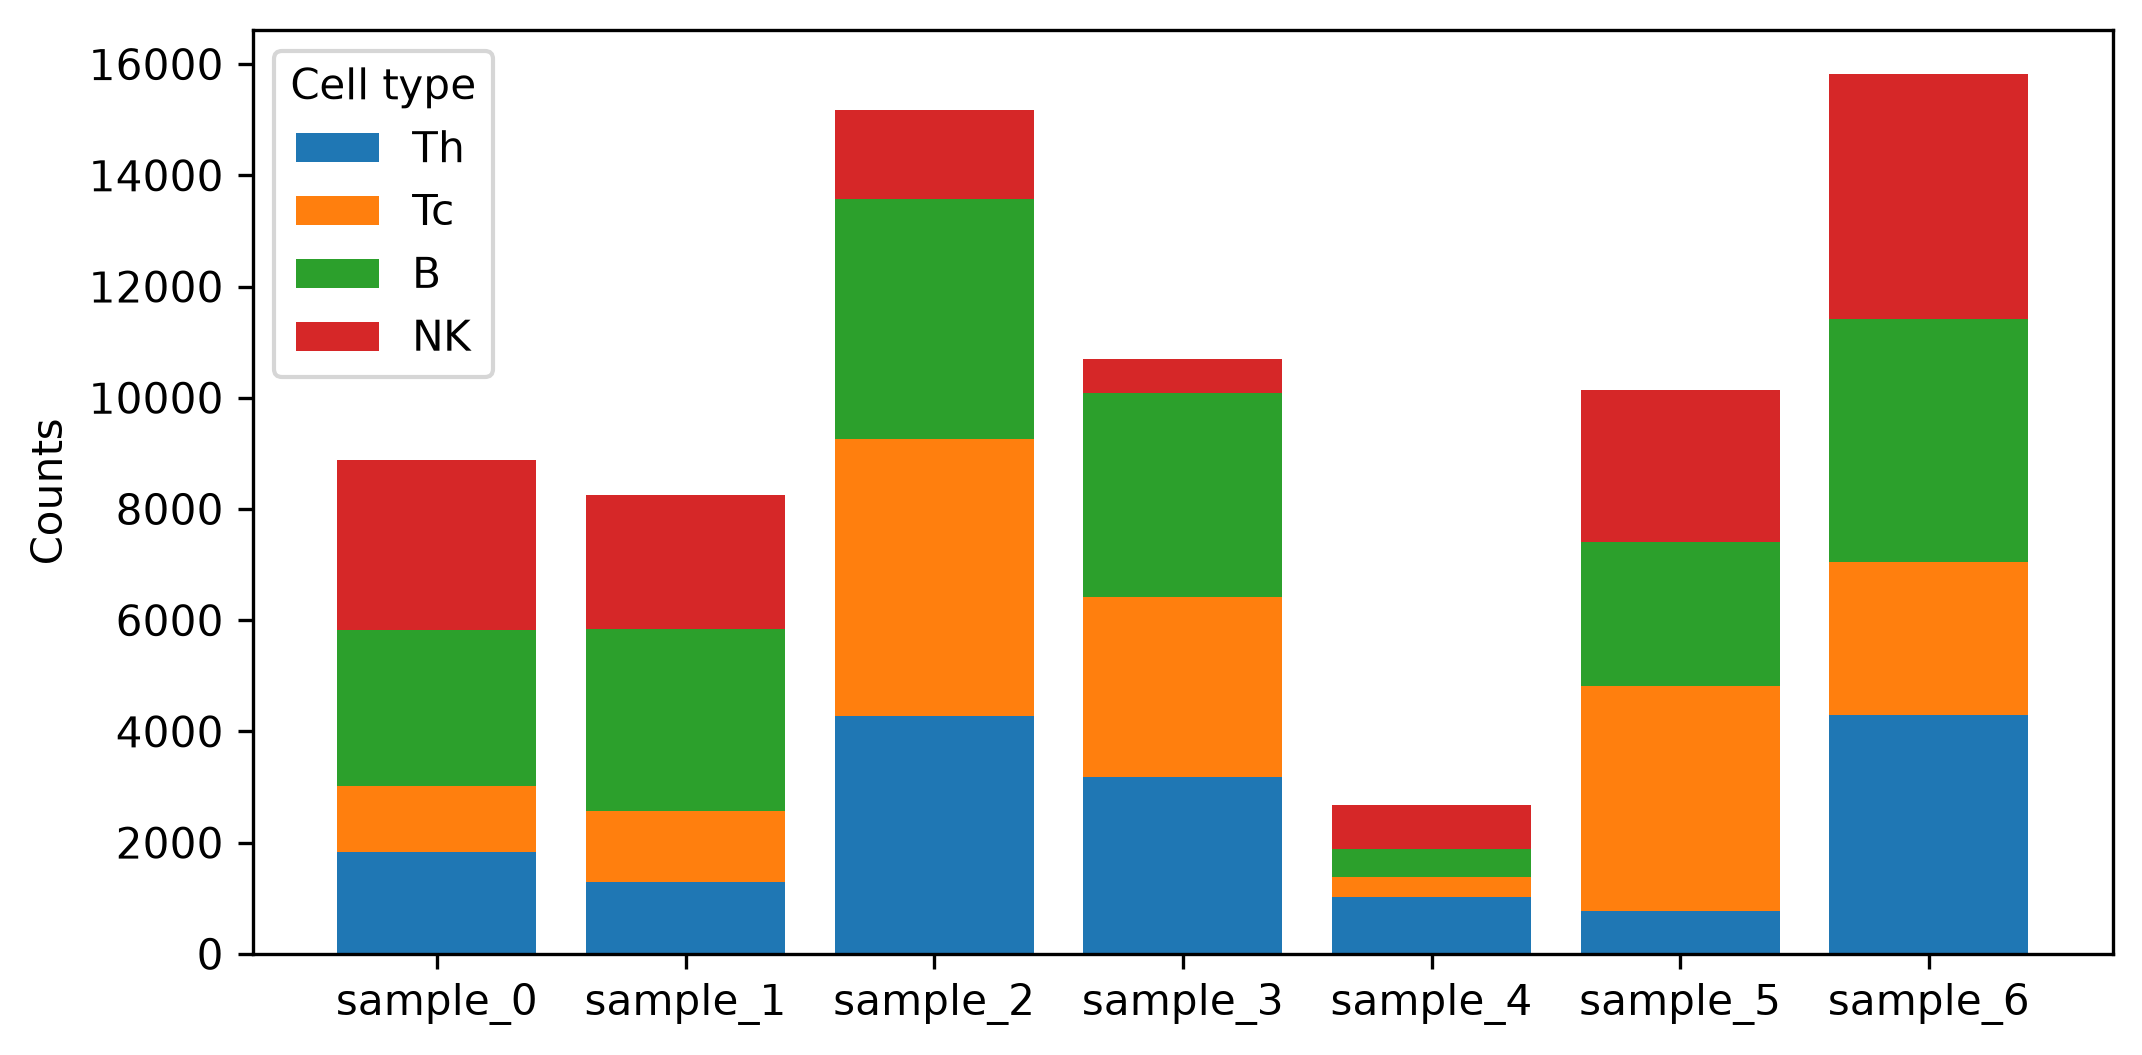

In [897]:
# first, set the bottoms to 0
bottoms = np.zeros(7)

plt.figure(figsize=(8,4))
for row, cell in zip(counts, cell_types):
    # plot the current row of counts
    plt.bar(samples, height=row, bottom=bottoms, label=cell)

    # add the values to the bottoms array so the next round gets drawn on top
    bottoms += row

plt.ylabel('Counts')
plt.legend(title='Cell type');

### Grouped bar charts

Another (potentially more) useful way to visualize the data above would be to use a grouped bar chart. The way in which we do the grouping depends on the question we are asking. If we care more about comparing the counts of one cell type across different samples, then we group according to cell type, but if instead we care abouot comparing the counts of different cell types within each sample, then we group according to sample.

To avoid confusion, let's call the clusters **categories** and the bars within each cluster **data set**. This means each data set consists of different categories, and we are comparing the data sets within each cateegory. 

Matplotlib's function for group bar charts is `grouped_bar()`. Because we are essentially visualizing 2D data (in the example above one dimension is the sample IDs and the other is the cell types), `grouped_bar()` accepts a few ways to represent 2D data:
1) A list of lists, where each sublist corresponds to one data set, and values in a sublist represent the categories:

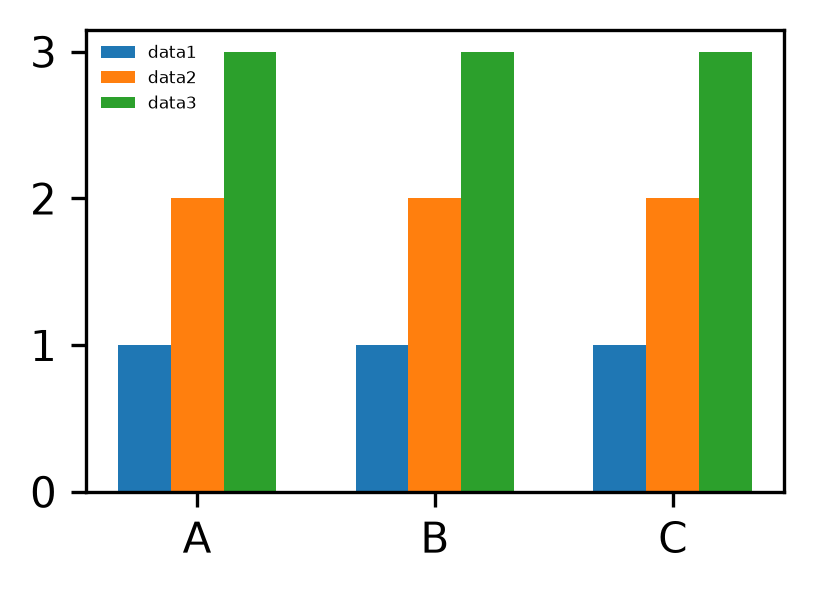

In [929]:
#        A B C
data = [[1,1,1], # data1
        [2,2,2], # data2
        [3,3,3]] # data3

plt.figure(figsize=(3,2))

plt.grouped_bar(
    data, 
    labels=['data1', 'data2', 'data3'], # data set labels for the legend
    tick_labels=list('ABC')             # category labels for the x ticks
)

plt.legend(loc='upper left', fontsize=4, frameon=False);

2) A dictionary, where each `key:value` pair represents a label:data set pair (since the dictionary already provides the data set name, no need to use the `label` argument, but we still need to name the categories)

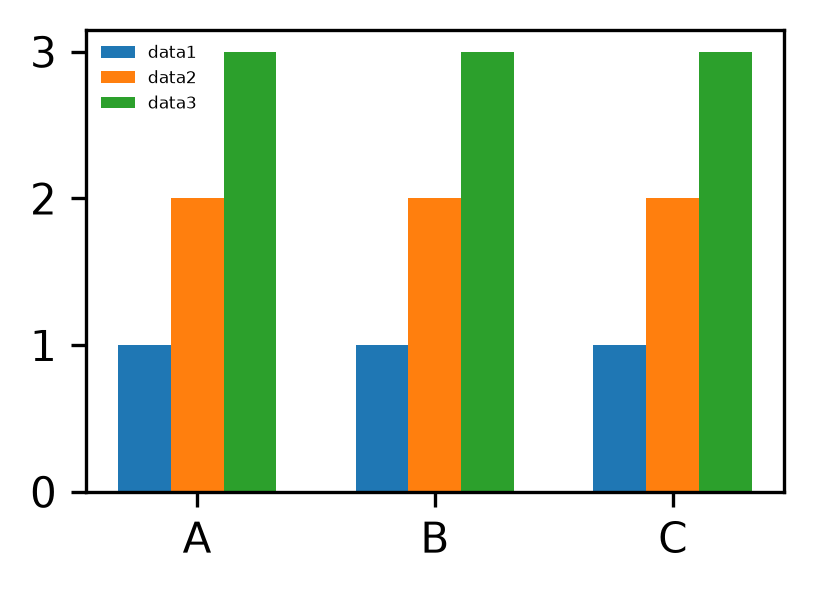

In [927]:
data = {
#             A B C
    'data1': [1,1,1],
    'data2': [2,2,2],
    'data3': [3,3,3]
}

plt.figure(figsize=(3,2))

plt.grouped_bar(
    data, 
    tick_labels=list('ABC')    # category labels for the x ticks
)

plt.legend(loc='upper left', fontsize=4, frameon=False);

3) A 2D NumPy array: in this case, each column is a data set, and each row is a category:

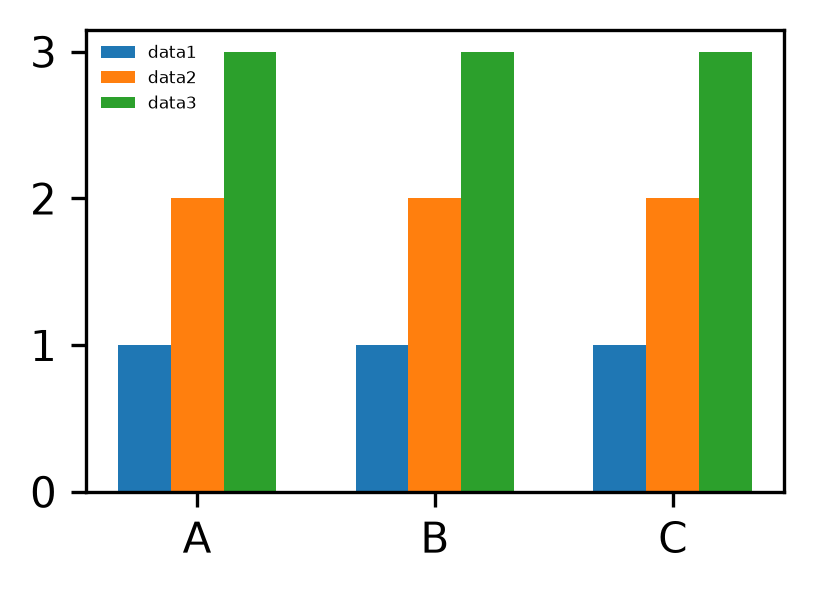

In [930]:
data = np.array([
    [1,2,3], # A
    [1,2,3], # B
    [1,2,3]  # C
])

plt.figure(figsize=(3,2))

plt.grouped_bar(
    data, 
    labels=['data1', 'data2', 'data3'], # data set labels for the legend
    tick_labels=list('ABC')             # category labels for the x ticks
)

plt.legend(loc='upper left', fontsize=4, frameon=False);

4. A Pandas DataFrame, where each row (index) is a category, and each column is a data set:

In [934]:
data = pd.DataFrame({
    'data1': [1,1,1],
    'data2': [2,2,2],
    'data3': [3,3,3]
}, index = list('ABC'))
data

,data1,data2,data3
A,1,2,3
B,1,2,3
C,1,2,3


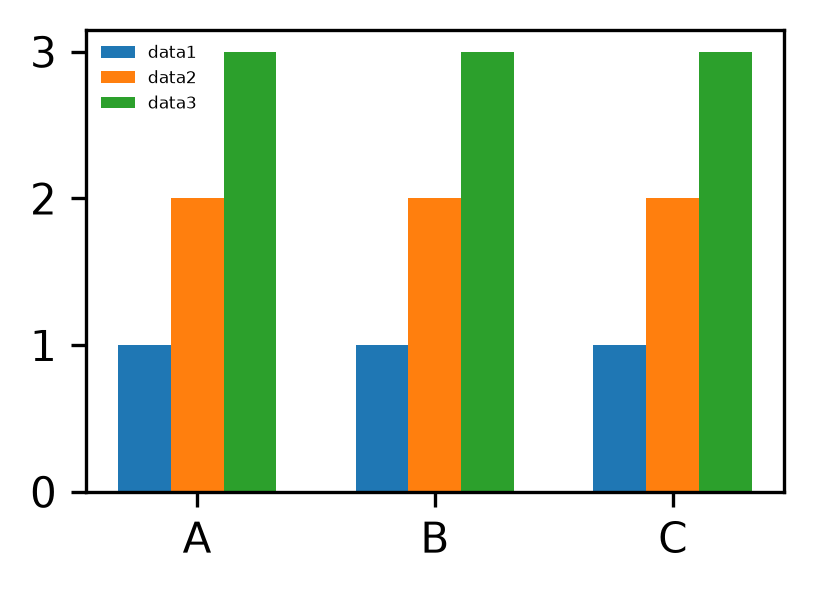

In [936]:
plt.figure(figsize=(3,2))
plt.grouped_bar(data)
plt.legend(loc='upper left', fontsize=4, frameon=False);

Since our cell counts data is already in a 2D NumPy array, we can now easily plot the grouped bar chart. As is, the rows in the counts data represent the 4 cell types, and the columns represent the 7 samples. This means that if we plot it as is, the categories (clusters) will be by cell type:

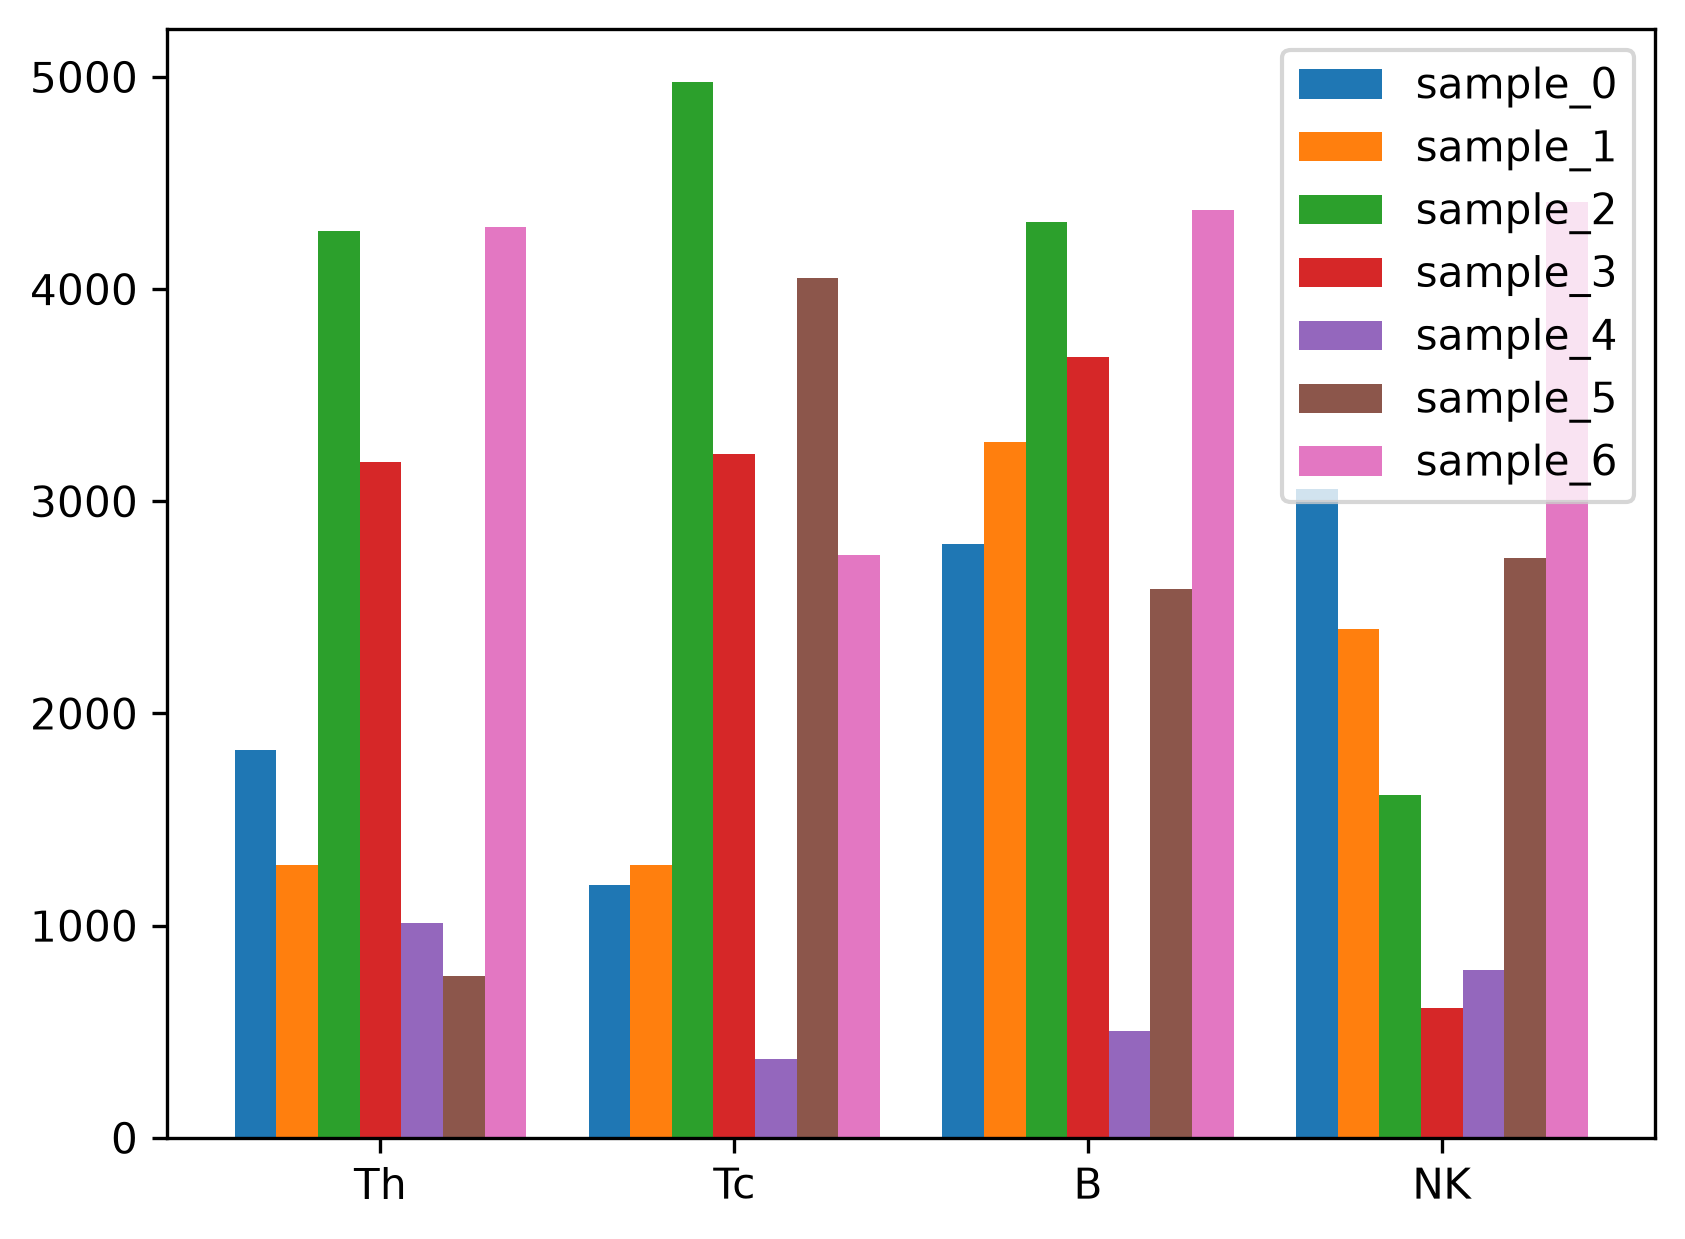

In [945]:
plt.grouped_bar(
    counts,
    labels=samples,
    tick_labels=cell_types
)
plt.legend();

But if we transpose the counts array, the roles will be flipped: the categories will be the samples, and we will be comparing the different cell types within each category:

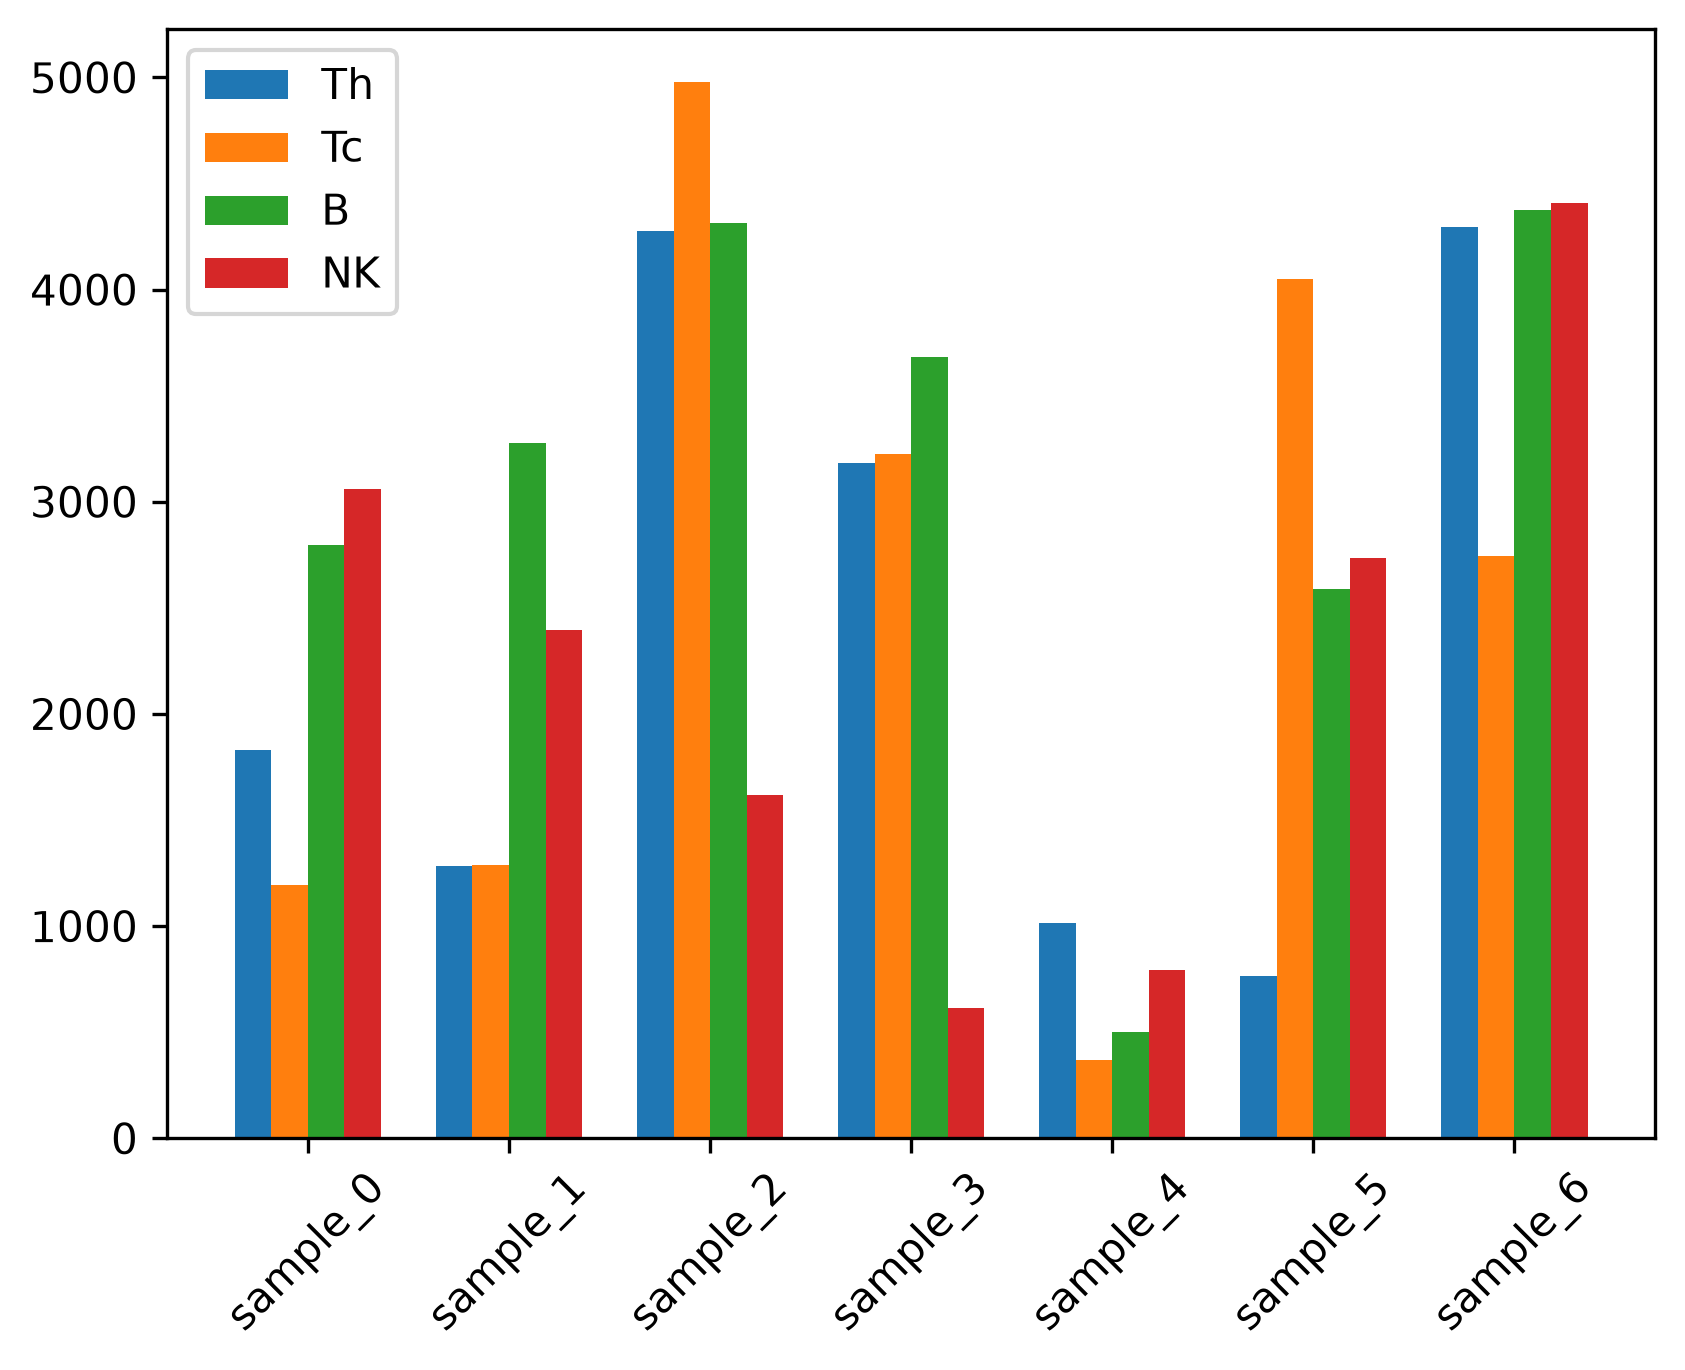

In [955]:
q = plt.grouped_bar(
    counts.T,               # transpose counts array
    labels=cell_types,
    tick_labels=samples
)
plt.xticks(rotation=45) # rotate x labels 45 degrees
plt.legend();

### Heatmaps

Another very popular way of plotting 2D data is with a heatmap. Matplotlib's function for that is `imshow()`. The reason it's called that way is because it can also be used to show images, which are also 2D data! Some important inputs that `imshow()` takes include:
- `x` (the only required input): the image data as a 2D array
- `cmap`: the color map to be used (default is `'viridis'`)
- `vmin` and `vmax`: the minimum and maximum values to be represented by the colormap
- `aspect`: the aspect ratio of the axes, either `square` or `auto`.

And many more! Now, let's try it with some toy data:

In [962]:
d = np.arange(30).reshape((5,6))
d

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29]])

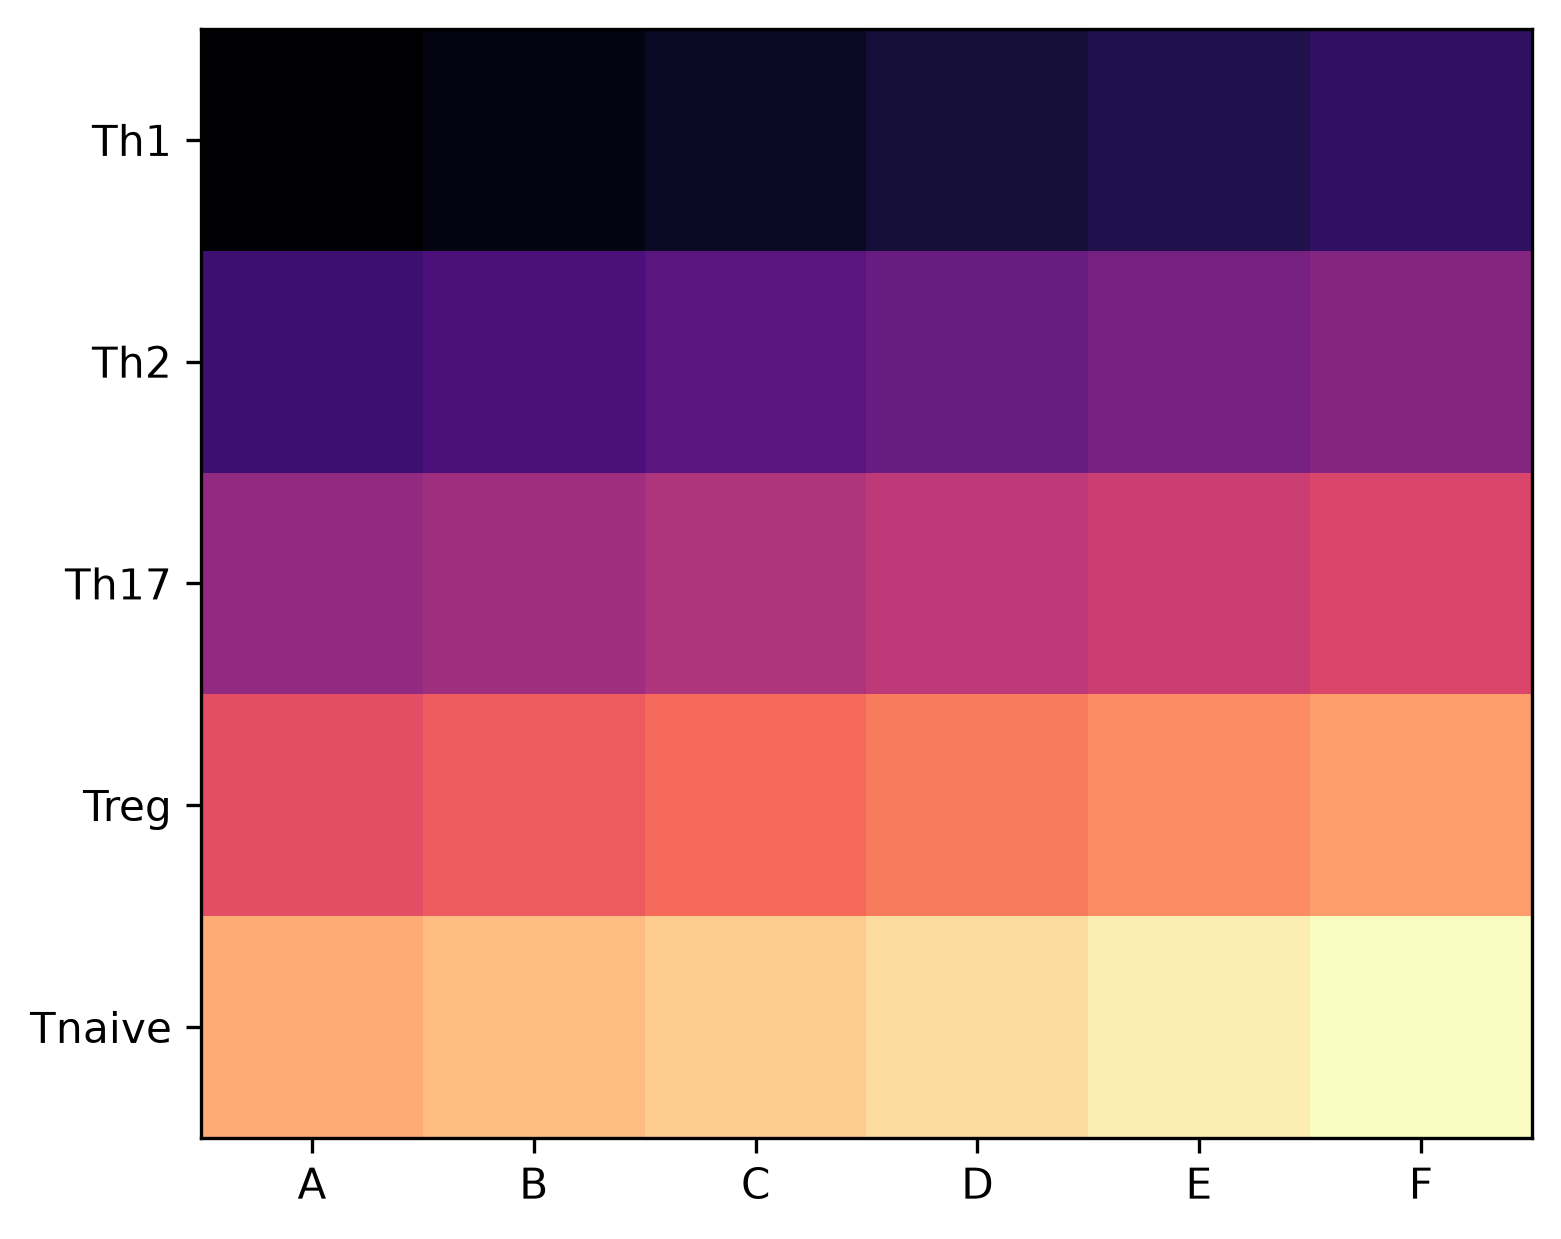

In [984]:
plt.imshow(d, vmin=0, vmax=29, aspect='equal', cmap='magma')

# plotting ticks and tick labels
plt.xticks(ticks=range(6), labels=list('ABCDEF'))
plt.yticks(ticks=range(5), labels=['Th1', 'Th2', 'Th17', 'Treg', 'Tnaive']);

### Seaborn: heatmaps and much more

Matplotlib's heatmap is great, but it's not very customizable. What if we wanted to annotate the heatmap by writing into each square the value it represents? What if we wanted to separate the squares and make them look prettier? Enter **Seaborn**, Matplotlib's more sophisticated child. Seaborn is built on top of Matplotlib to make it easier to plot more complex graphs for which Matplotlib doesn't have convenient and intuitive functions. You can look at the pretty graphs Seaborn allows you to draw [in their docs' gallery](https://seaborn.pydata.org/examples/index.html).

We don't have enough time to delve into all of them, alas. But we have time to look at their heatmaps. 

Using Seaborn feels a lot like using Matplotlib (because it is based on it), except that they have more plot functions, and their functions tend to have extra customizability. Now see how a lot of the functionality that Matplotlib's `imshow()` doesn't offer is easily provided by Seaborn's `heatmap()`.

In [988]:
import seaborn as sns
sns.__version__

'0.13.2'

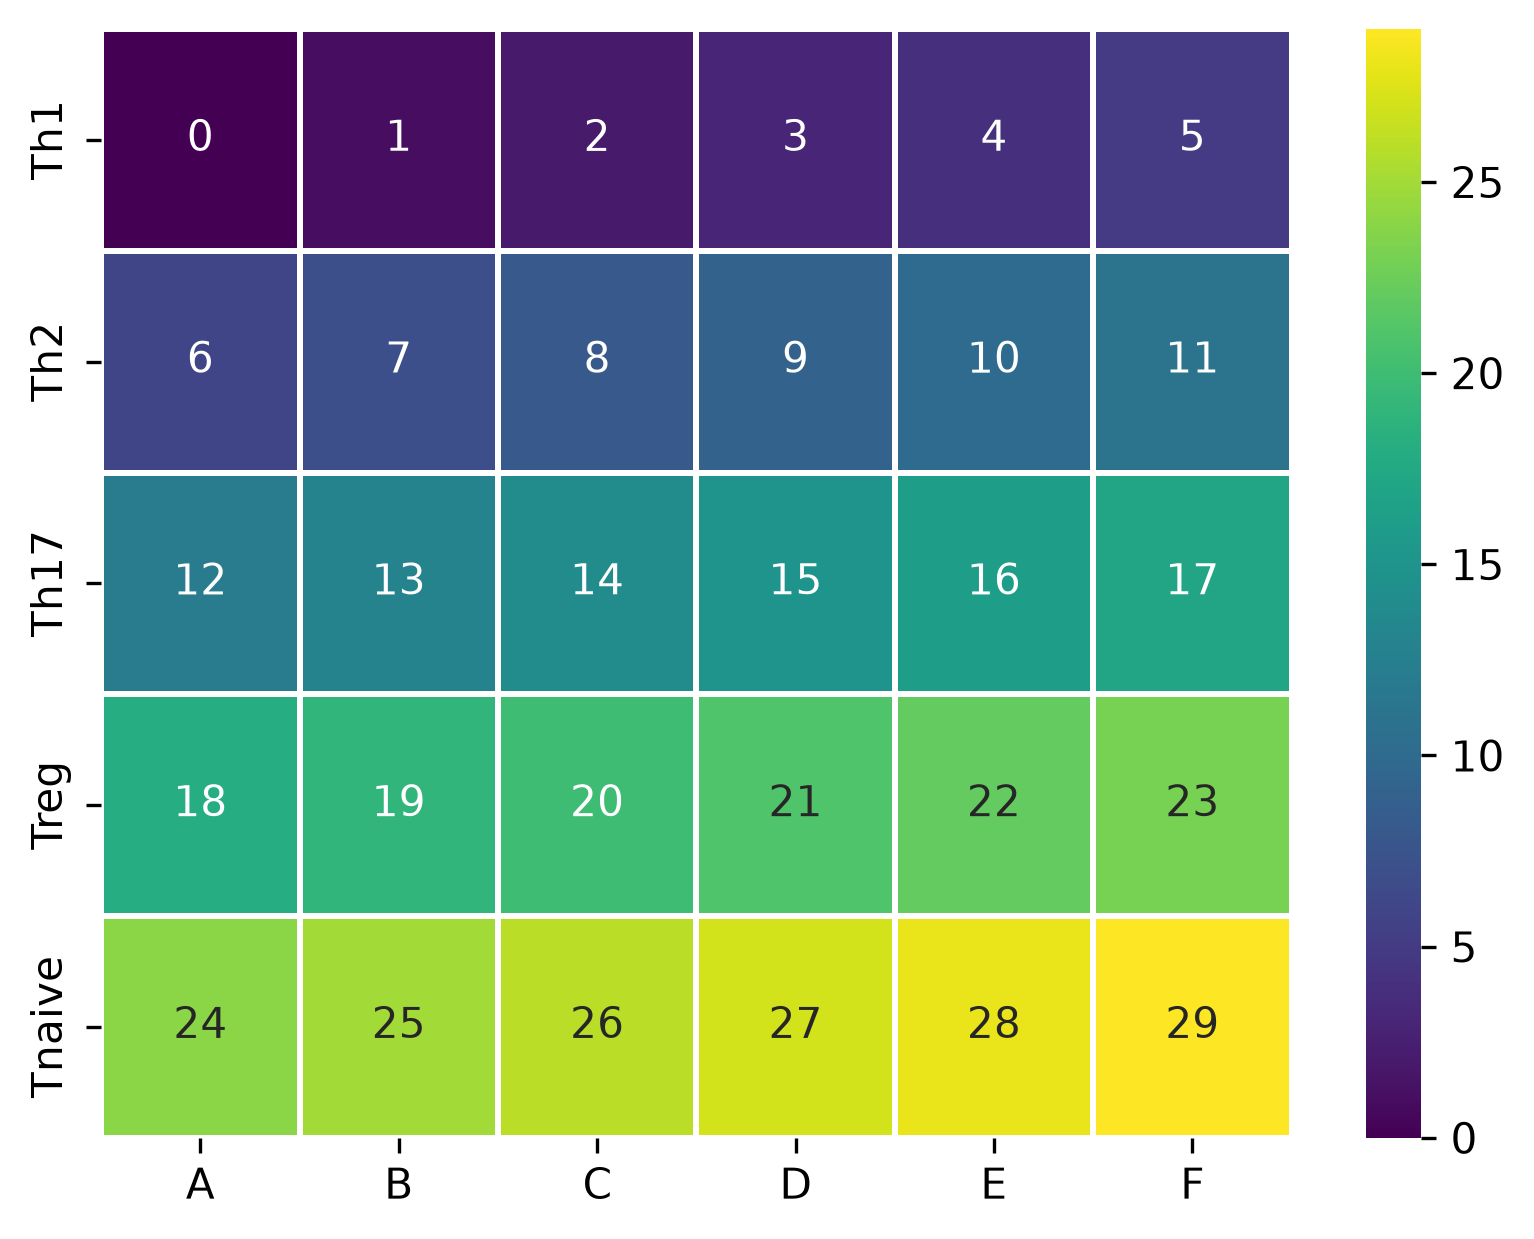

In [993]:
sns.heatmap(
    data = d,
    cmap = 'viridis',
    annot = True,
    linewidths = 1,
    xticklabels = list('ABCDEF'),
    yticklabels = ['Th1', 'Th2', 'Th17', 'Treg', 'Tnaive']
);

So easy! But please note that **Seaborn** is not the end-all-be-all of Python plotting. It does not offer the near-infinite customization that Matplotlib offers; it just makes some of it more convenient to code in. If you want to further customize a Seaborn plot, you might have to deal with the Matplotlib infrastructure that underlies it. 

For instance, if you don't like that the y tick lables are vertical, Seaborn can't do anything about it. You'll have to call in Matplotlib:

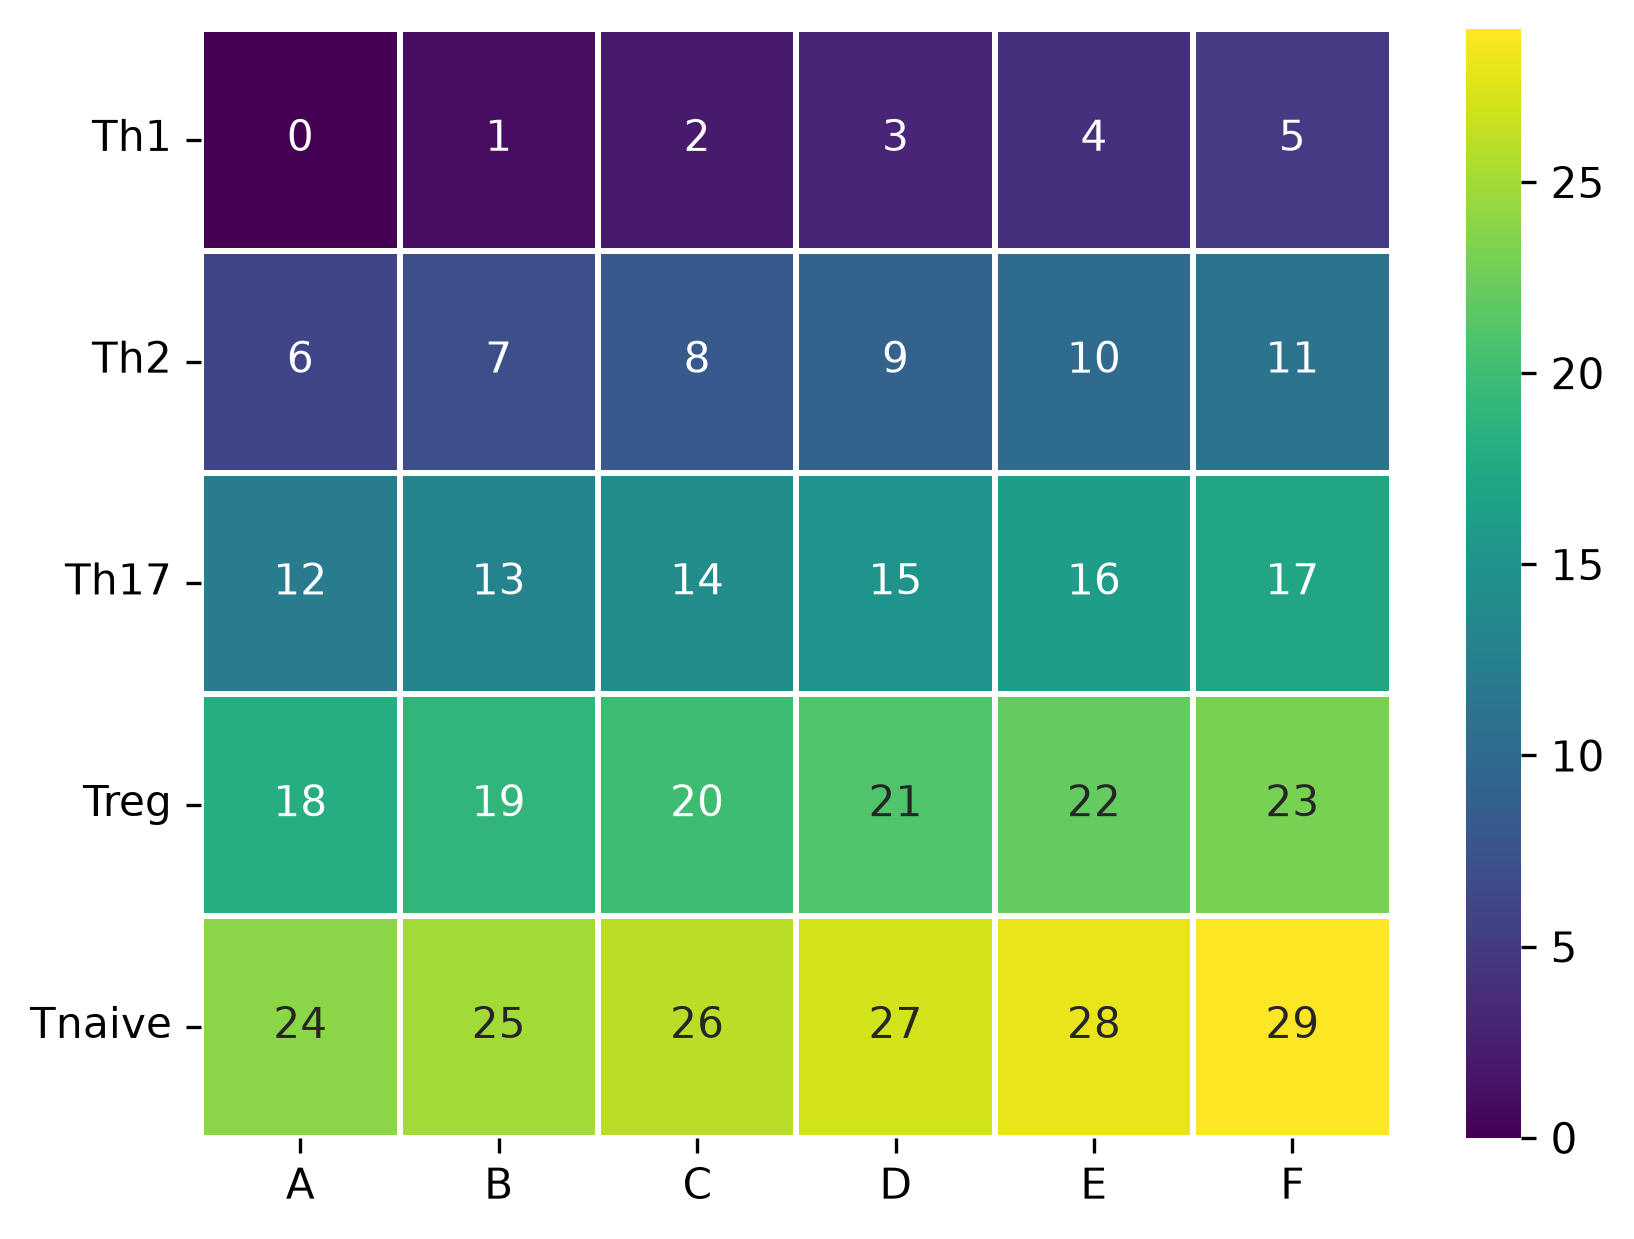

In [997]:
sns.heatmap(
    data = d,
    cmap = 'viridis',
    annot = True,
    linewidths = 1,
    xticklabels = list('ABCDEF'),
    yticklabels = ['Th1', 'Th2', 'Th17', 'Treg', 'Tnaive']
);

plt.yticks(rotation=0); # invoking the Matplotlib infrastructure!

### On plotting distributions

Plotting distributions, be they simulated or measured in the real world, is essential in scientific computing and communication. One can plot distributions with histograms, box plots, violin plots, event plots, and other types of plots, including even scatter plots! 

Please keep in mind that some plots are absolutely not intended to show distributions. For instance, do not be tempted to represent distributions using a pie char, a spider plot, or even one of the bar charts we looked at earlier — even if you add in error bars. Bar charts are **not** for distributions. Even if the replicates are few and far between. Instead, you could use any of the plots shown below — and more that we do not have enough time to cover.

### Histograms

Histograms show a distribution of data points after they have been binned into distinct and non-overlapping bins. Matplotlib's histogram function is simply `hist()`, and it takes the following inputs, among many:
- `x`: the data as an array (the only required input)
- `bins`: if integer, signifies the number of bins; if array, signifies the bin edges
- `density`: if `True`, normalize the histogram and plot a probability density instead of the counts (default `False`)
- `color`: a single color, or a list of colors in case more than one data set is drawn
- `histtype`: either `bar` (default), `barstacked` (if multiple datasets), `step` (just aline), or `stepfilled` (filled step line)
- `bottom`: the bottom of each histogram bar. Default is 0, but can be used to plot many histograms on the same plot.

In [1043]:
# generating Normally distributed data
x = rng.normal(0,1,500)
y = rng.normal(5,2,500)
z = rng.normal(-2,3,500)

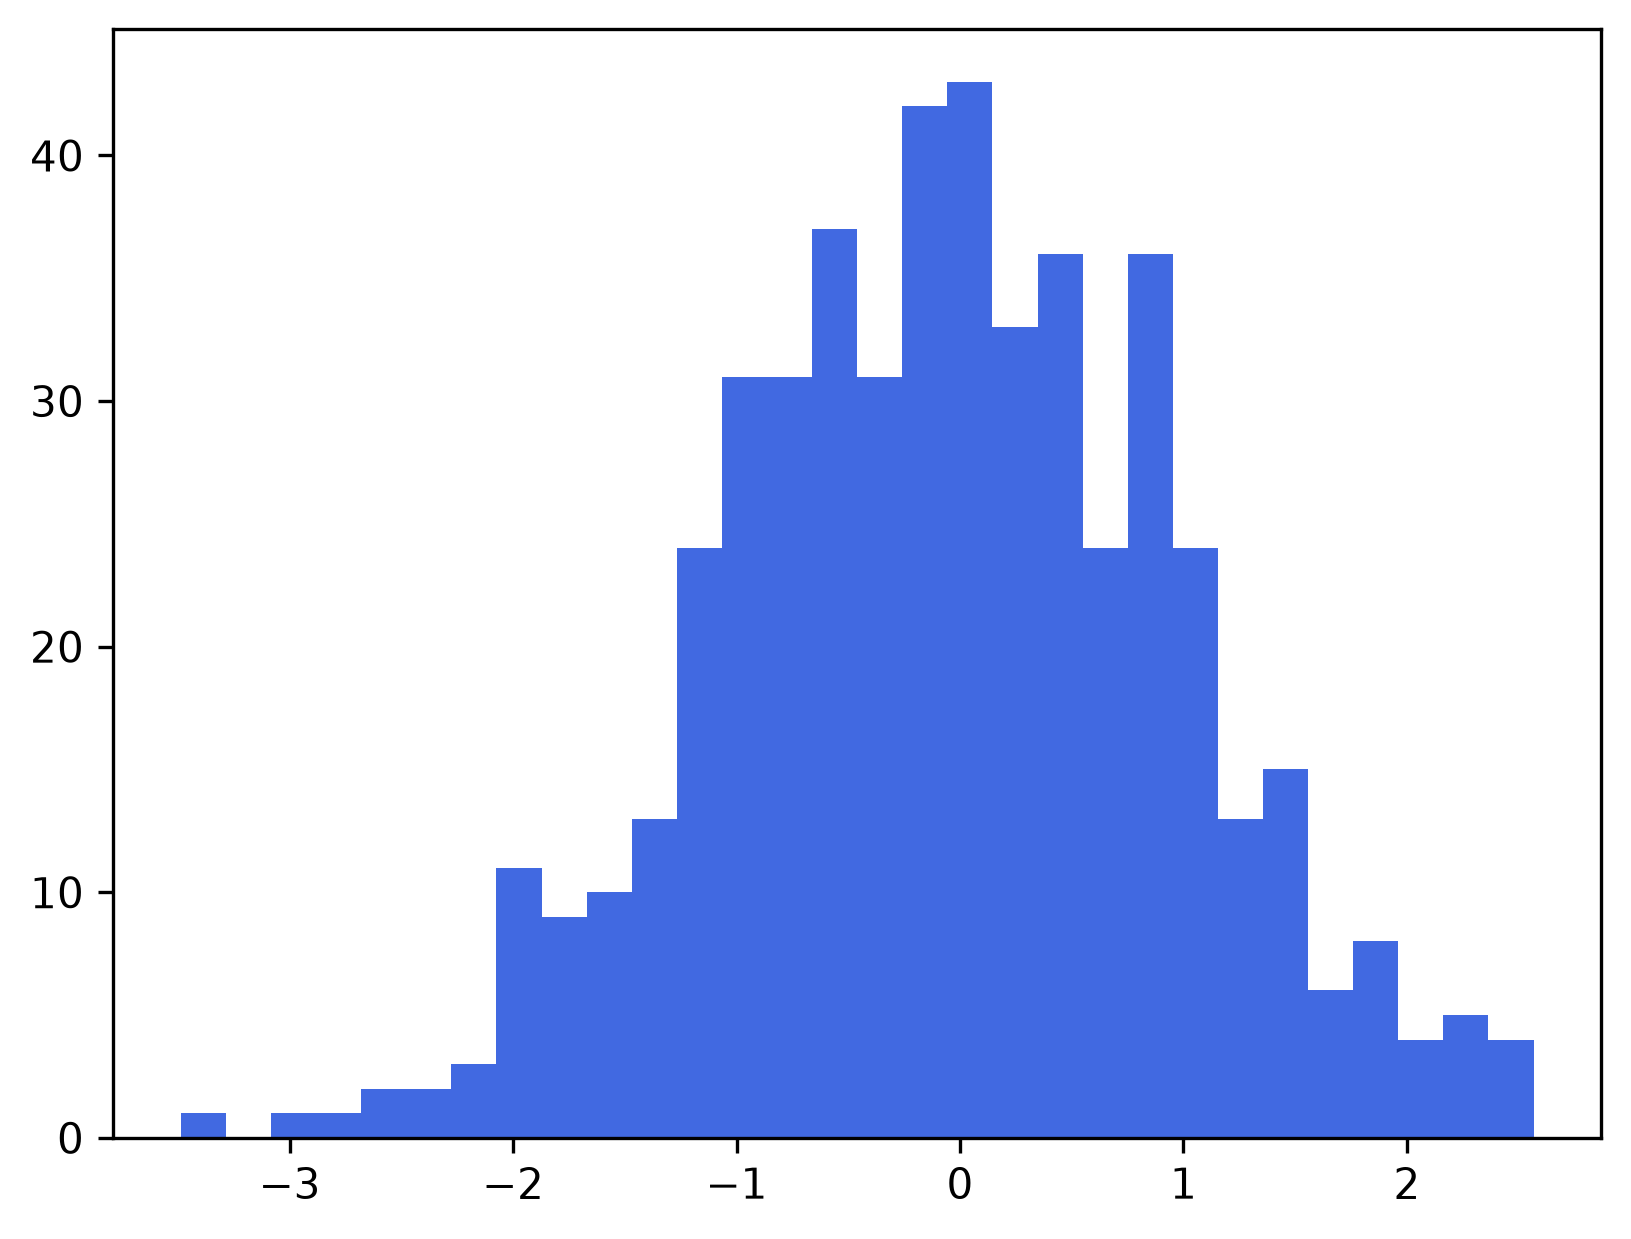

In [1044]:
plt.hist(
    x,
    bins = 30, # try using [-5,-4,-3,-2,-1,0,1,2,3,4,5]
    density = False,
    color = 'royalblue',
    bottom = 0,
    histtype = 'bar'
);

We can also overlay many histograms on top of each other by making them a little transparent using the `alpha` parameter:

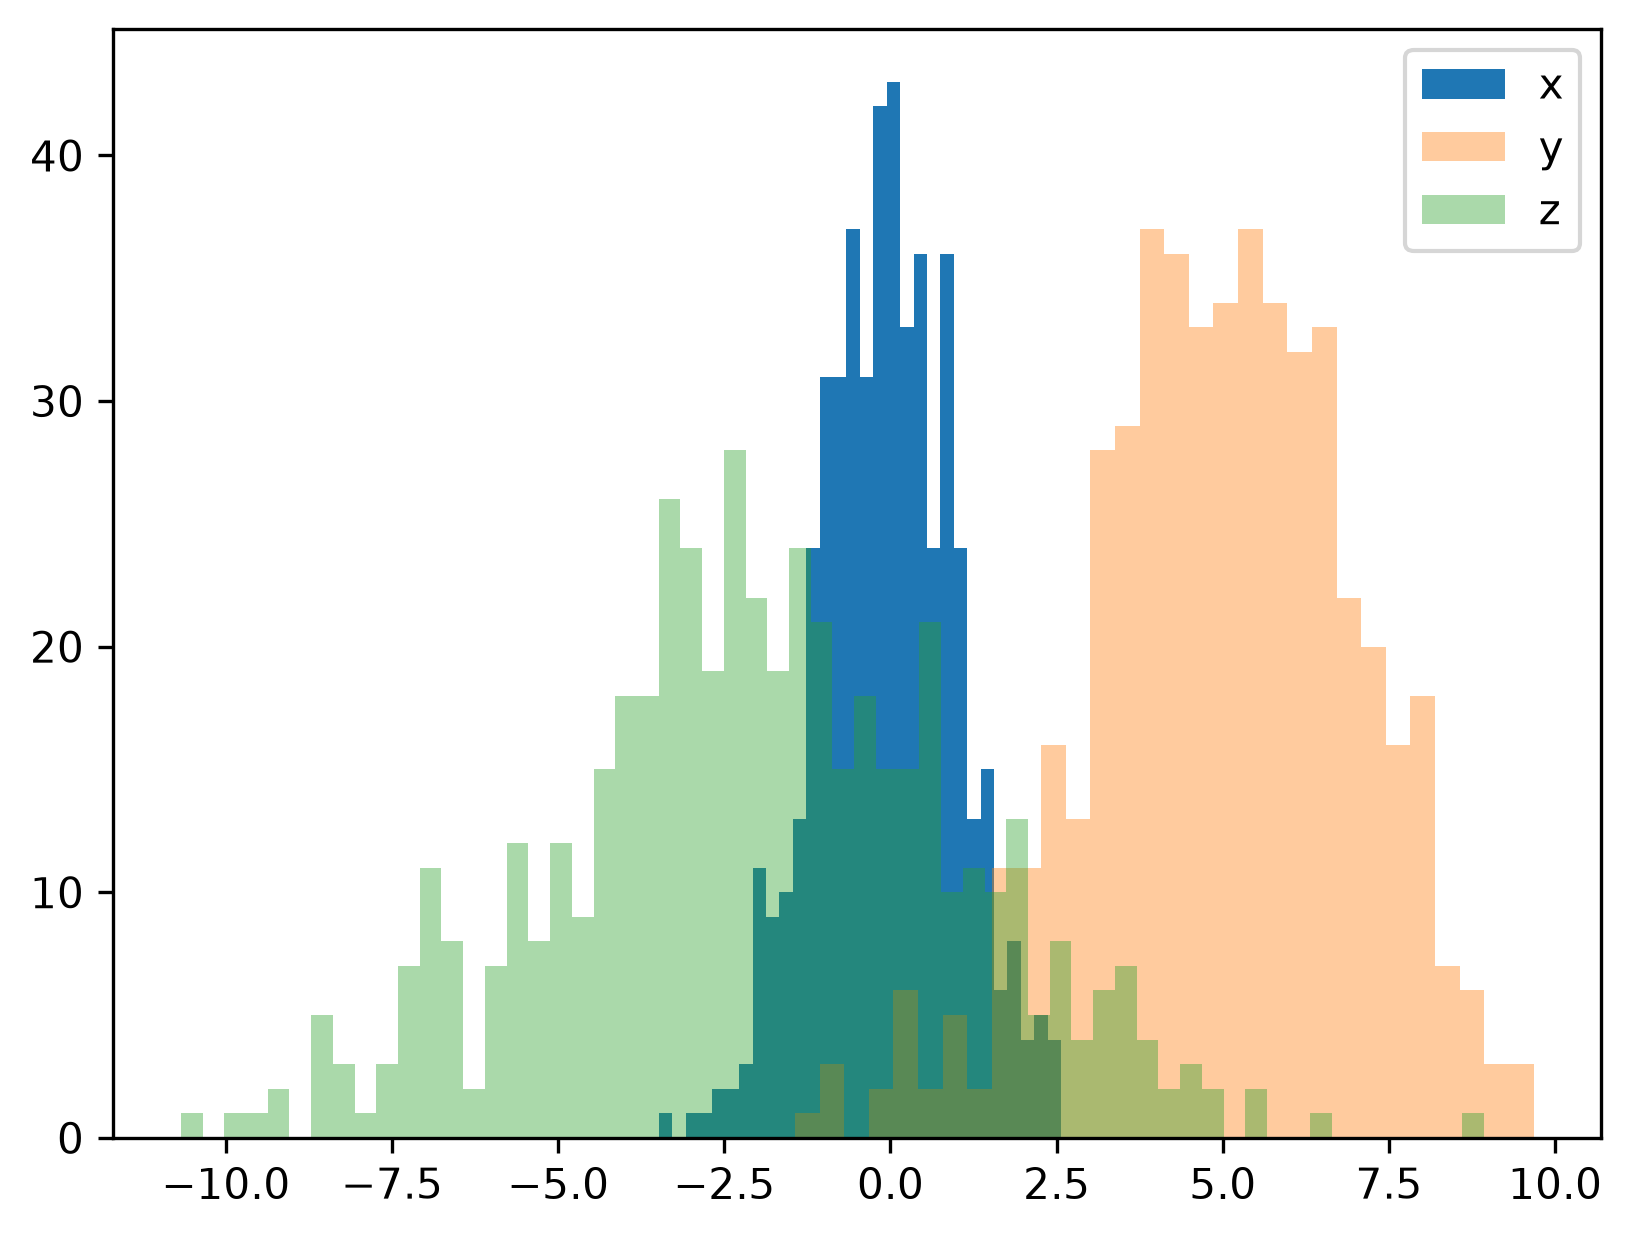

In [1051]:
plt.hist(x, bins=30, label="x")
plt.hist(y, bins=30, alpha=0.4, label='y')
plt.hist(z, bins=60, alpha=0.4, label='z')
plt.legend();

Or by changing the bottom of each historgram:

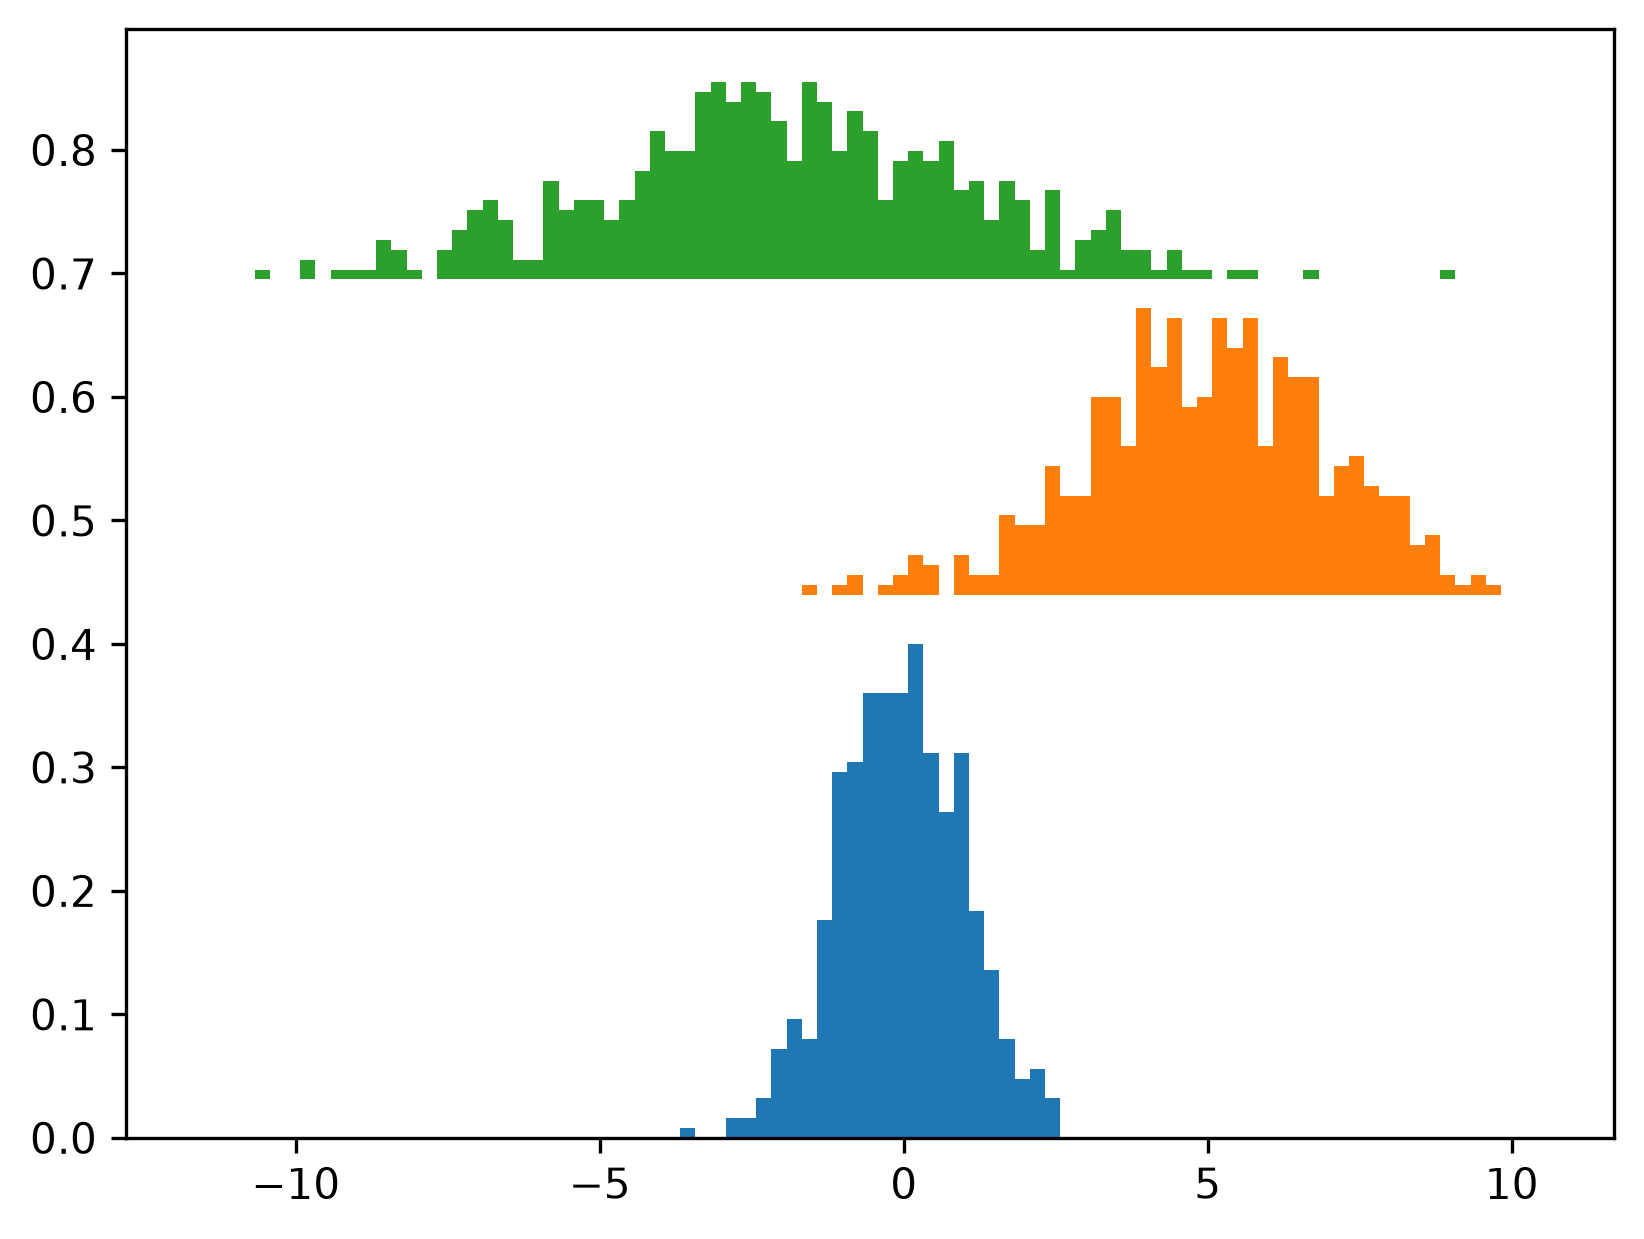

In [1054]:
btm = 0

bins = np.arange(z.min()-1, y.max()+1, 0.25) # try these bins too!
for data in [x,y,z]:
    density, bins, bars = plt.hist(data, bins=bins, density=True, bottom = btm)
    btm += density.max() * 1.1

However, be careful with the example above: the y axis ticks are only helpful with the first (blue) historgrams. It does not reset with each new histogram. That can be fixed by either (ideally) isolating each historgram to its own subplot with its own scales, or (less ideally) adjusting the y ticks and tick labels.

### Box plots

Another very common way to visualize a distribution of samples is to use box plots. Matplotlib's `boxplot()` takes in data (either 1D for one distribution or 2D for multiple distributions) and plots boxes the following way (copied from the [Matplotlib docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#matplotlib.axes.Axes.boxplot)):

```
     Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers
                       IQR
```

So the box extends from Q1 (the 25th percentile) to Q3 (the 75th percentile) of the data, and the whiskers extend to the farthest data point lying within 1.5 the inter-quartile range (IQR). Since the whiskers extend to actual data points, they might appear asymmetric.

`boxplot()` takes the following arguments, among many more:
- `x`: the input data. Could either a single 1D array for a single box and a list of arrays or a 2D array for multiple boxes at the same time. (If 2D array, one box is drawn per column.)
- `notch`: if `True`, draw notches around the median that represent the 95% confidence interval around the median (default is `False`)
- `sym`: the symbol for flier points, if empty string `''`, the fliers are not drawn
- `orientation`: the orientation of the boxes, `horizontal` or `vertical`
- `whis`: the position of the whiskers as a mutliple of the IQR (default 1.5)
- `positions`: the positions of the boxes along the axis, default is just a range of integers (1,2,3,...)
- `tick_labels`: the label for each box plot
- `meanline`: if `True`, show the mean as a line spanning the width of the box (like the median line), default is `False`

And there is a whole lot more customization available for the box, the lines, the whiskers, the caps, everything. Simply check out the docs if you are interested!

For the toy data in this example, instead of concatenating different Normal distributions, let's use the Multivariate Normal distribution, which generates multidimensional samples, where each sample can have a different mean and variance, and the samples can covary with each other. The inputs to `multivariate_normal()` are: (1) an $N$-long array of means, (2) an $N\times N$ square covariance matrix containing the variances along the diagonal and the covariances as the non-diagonal elements): 

In [1133]:
x = rng.multivariate_normal(
    mean=[1,2,4,8,10],    # means array
    cov=np.eye(5),        # covariance matrix is the identity matrix, 
                          # so all variances 1 and no covariances
    size=200              # 100 samples, so output should be (100, 4)
)

In [1134]:
x[:5]

array([[ 0.7944156 ,  0.95952364,  3.2620821 ,  6.0302983 ,  9.66906159],
       [ 2.28876101,  1.88360621,  5.81024068,  8.09577912,  9.5285211 ],
       [ 1.18767319,  3.71483904,  4.35267641,  9.22656945, 11.00095753],
       [ 2.9135583 ,  2.80470954,  2.90210831,  8.20569645, 10.55511849],
       [ 0.04999108,  2.29129425,  2.94774452,  9.31287148, 11.19617719]])

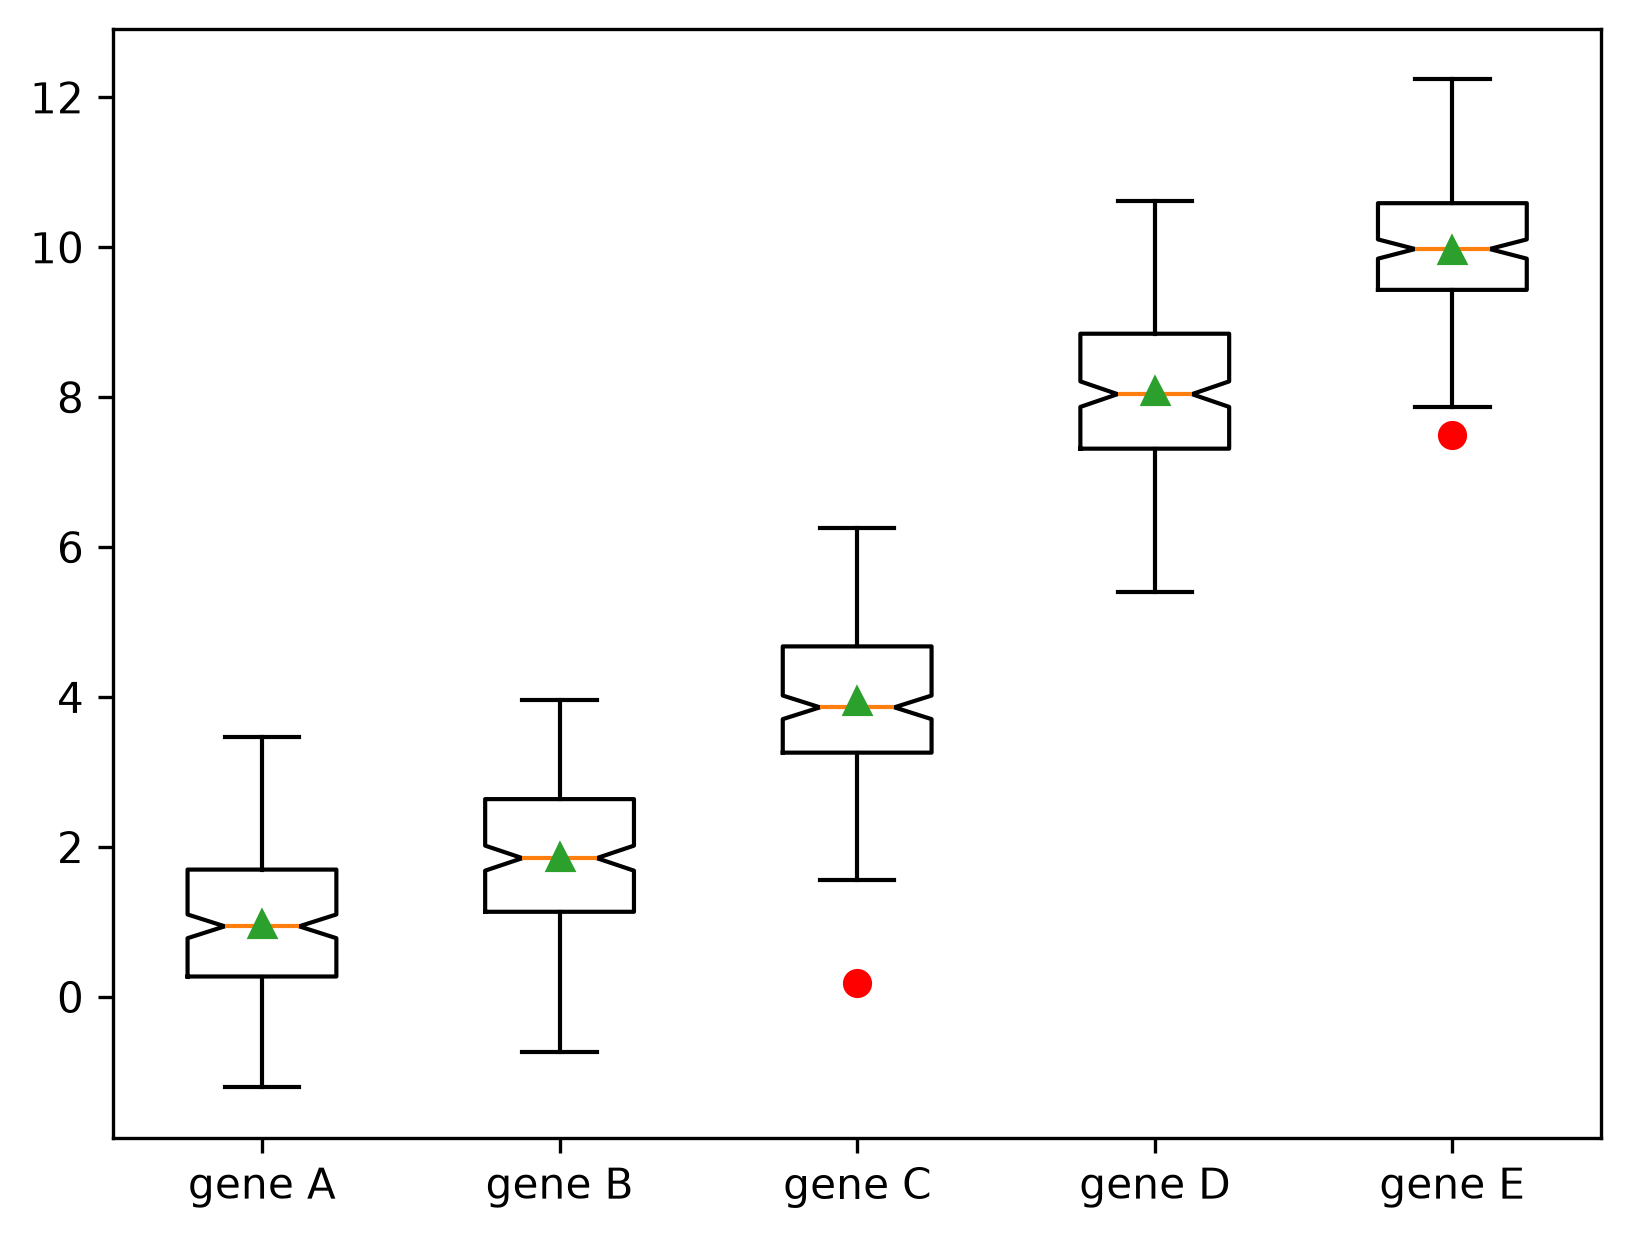

In [1144]:
p = plt.boxplot(
    x, 
    notch=True, 
    sym='ro',
    whis=1.5,
    tick_labels=['gene A', 'gene B', 'gene C', 'gene D', 'gene E'],
    showmeans=True,
)

As a proof of concept that these boxes can indeed be customized, let's change their color with the `boxprops` argument, which stands for box properties and takes as input a dictionary of argument-value pairs that are passed to the box elements. What arguments, you may ask? The boxes are actually drawn with a `Line2D` element, so they accept all the arguments that lines usually take, like color, line width, or style (see the comprehensive list [in the docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.lines.Line2D.html)):

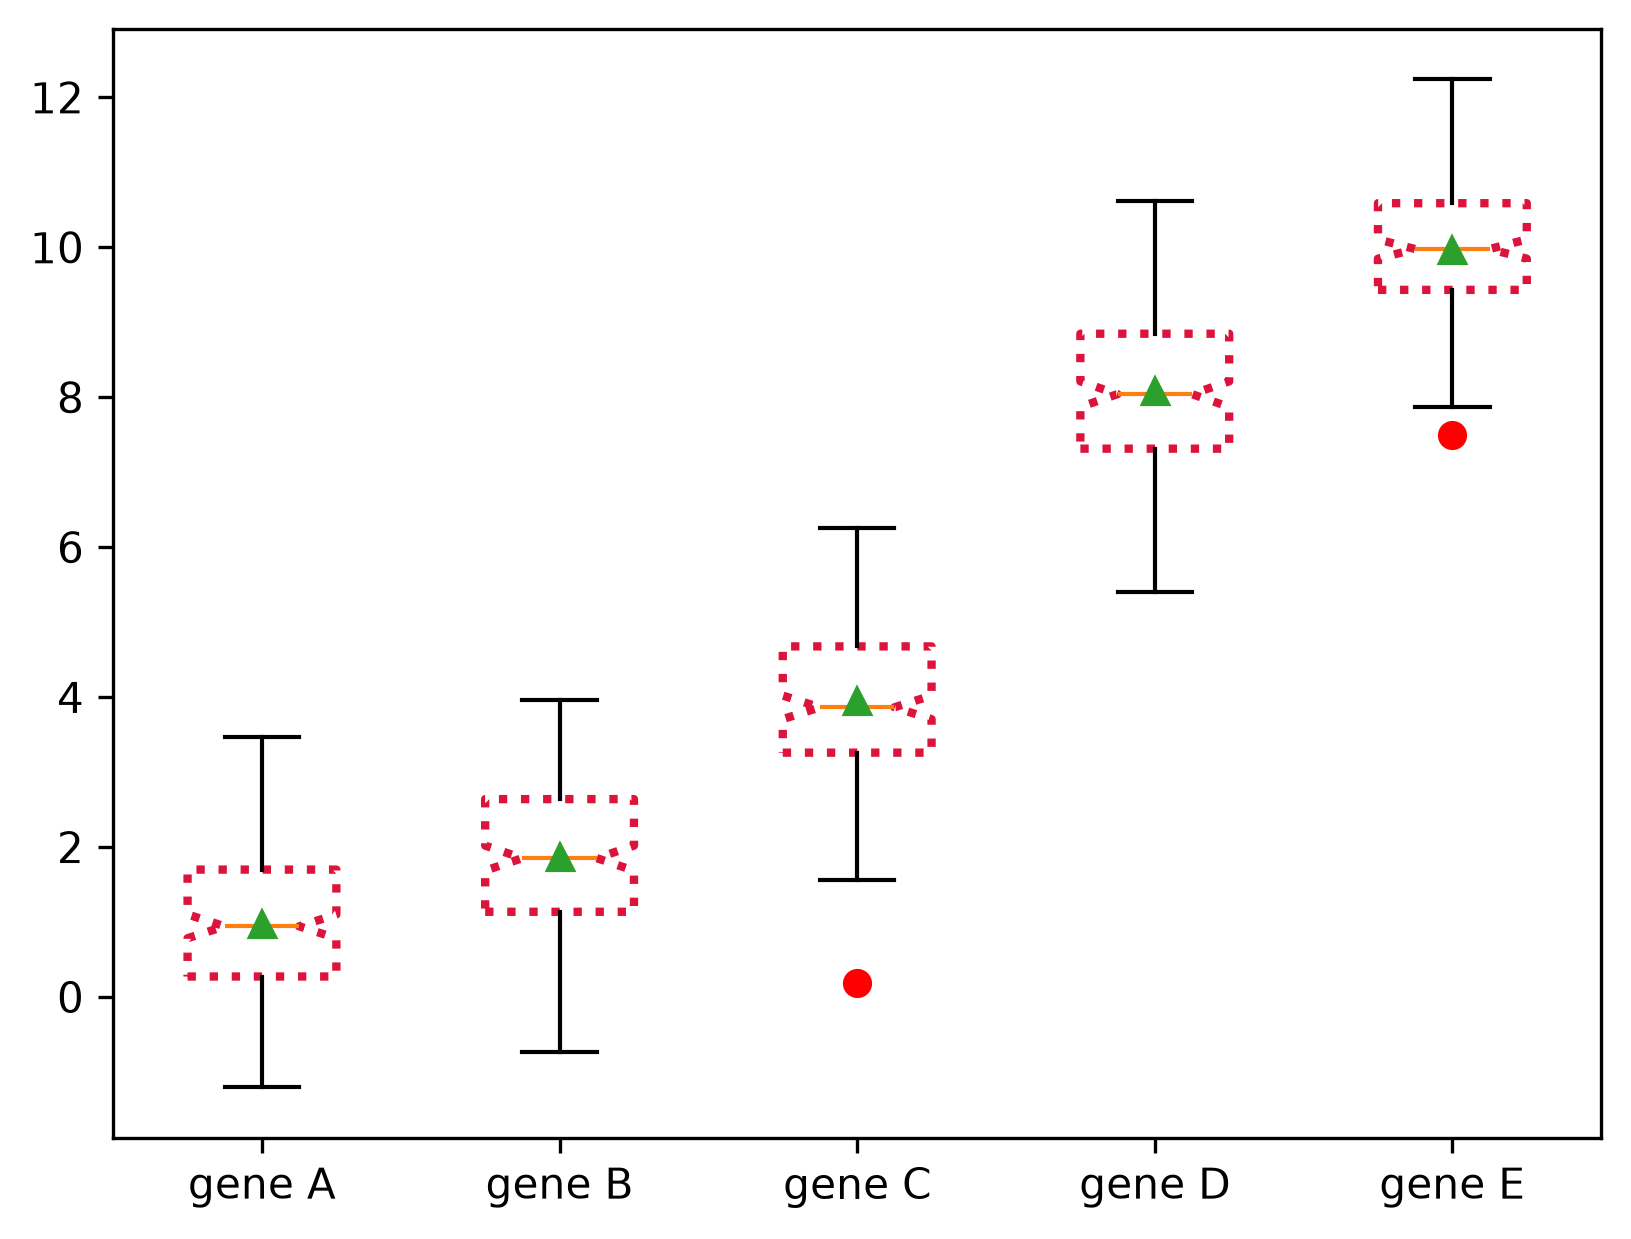

In [1162]:
p = plt.boxplot(
    x, 
    notch=True, 
    sym='or',
    whis=1.5,
    tick_labels=['gene A', 'gene B', 'gene C', 'gene D', 'gene E'],
    showmeans=True,
    boxprops={'color':'crimson', 'linewidth':2, 'linestyle':'dotted'}
)

Way to look like candy cane!

`Line2D` objects alas do not have a fill color. Instead we can use a `Patch` object, which can be filled with a color! (see the comprehensive list of its [properties here](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html)). To draw the boxes as `Patch` objects, simply set the `patch_artist` argument to `True`, and give it the properties you want through `boxprops`: 

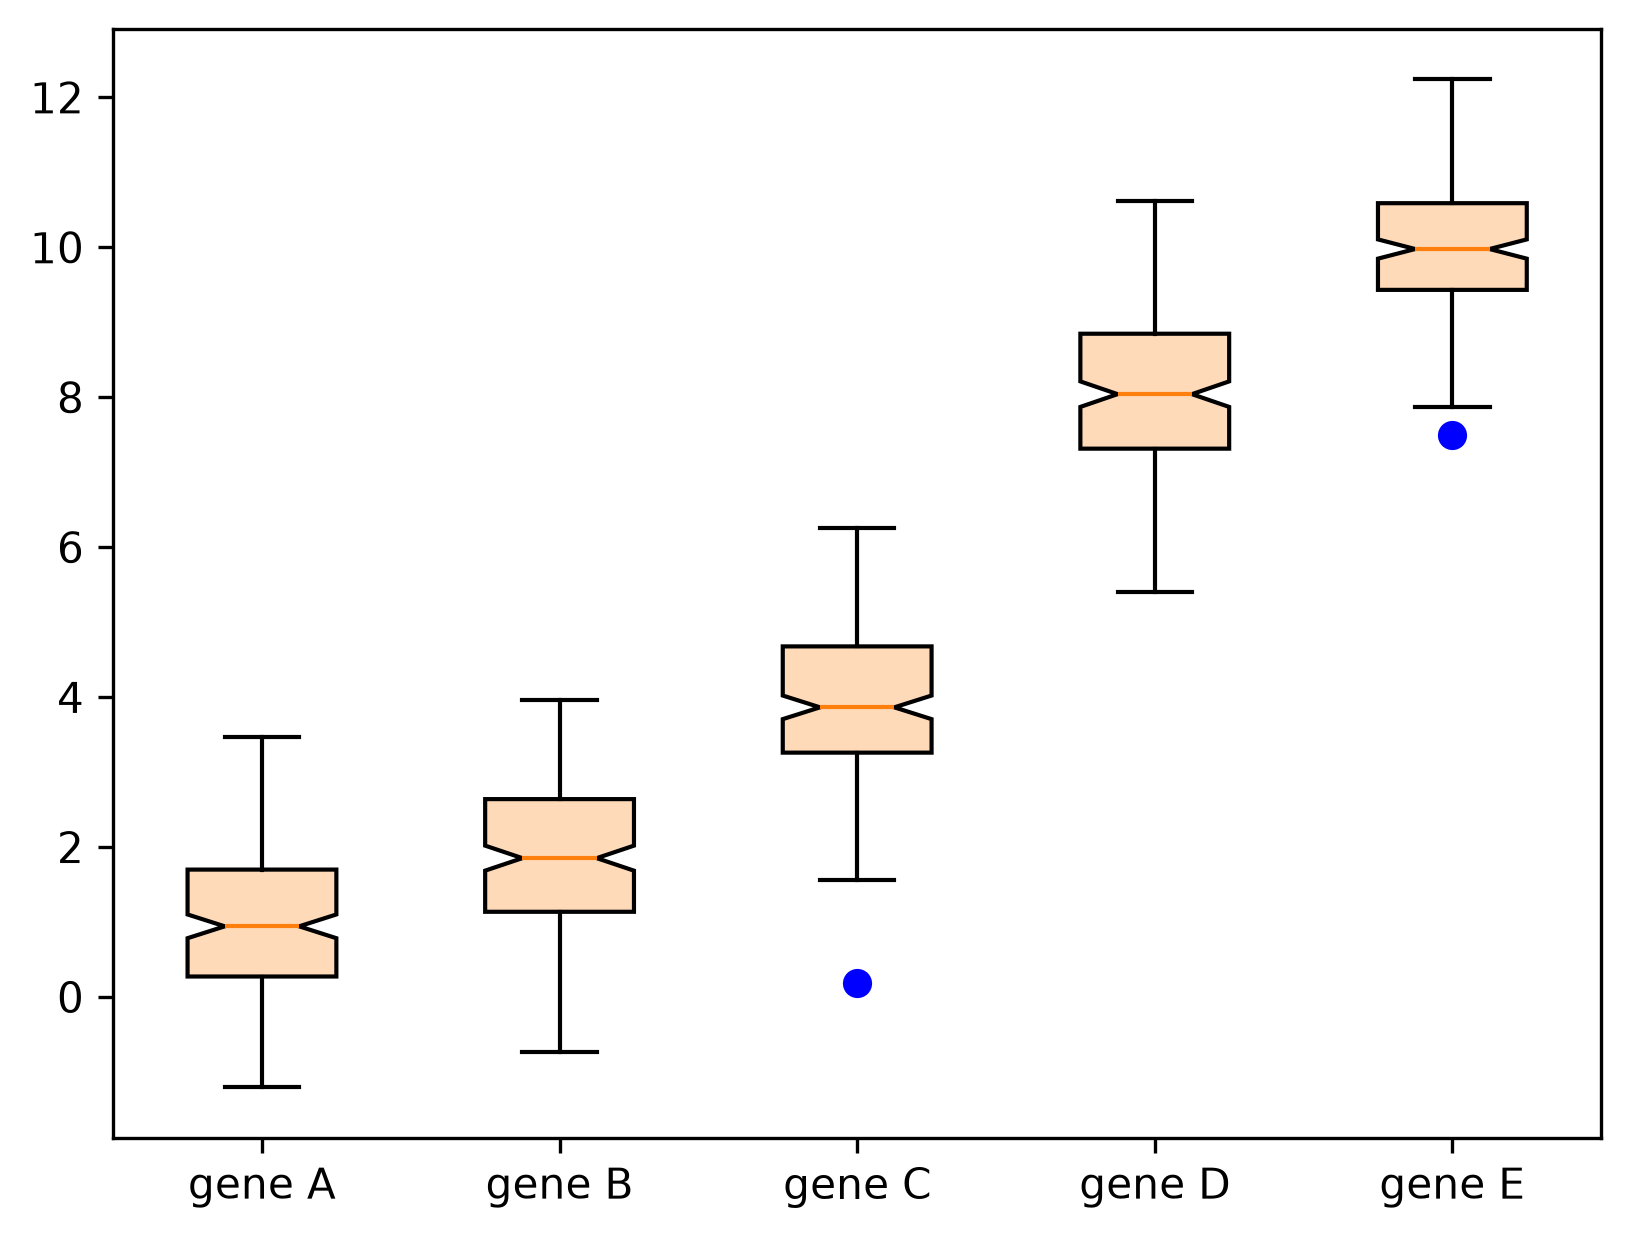

In [1161]:
p = plt.boxplot(
    x, 
    notch=True, 
    sym='ob',
    whis=1.5,
    tick_labels=['gene A', 'gene B', 'gene C', 'gene D', 'gene E'],
    patch_artist=True,
    boxprops={'facecolor':'peachpuff'}
)

### Violin plots

Yet another way to plot distributions which is especially popular in the RNA sequencing world is the violin plot. These plots are essentially vertical histograms usually plotted with their reflections across their vertical base so they look like violins. One big difference between violin plots and vertical histograms is that, while histograms only show the number of samples per bin, violin plots generally show a smooth estimate of the probability density function that explains the data.

Matplotlib's function `violinplot()` easily and conveniently draws them, taking inputs that are very similar to the ones taked by `boxplot()`.

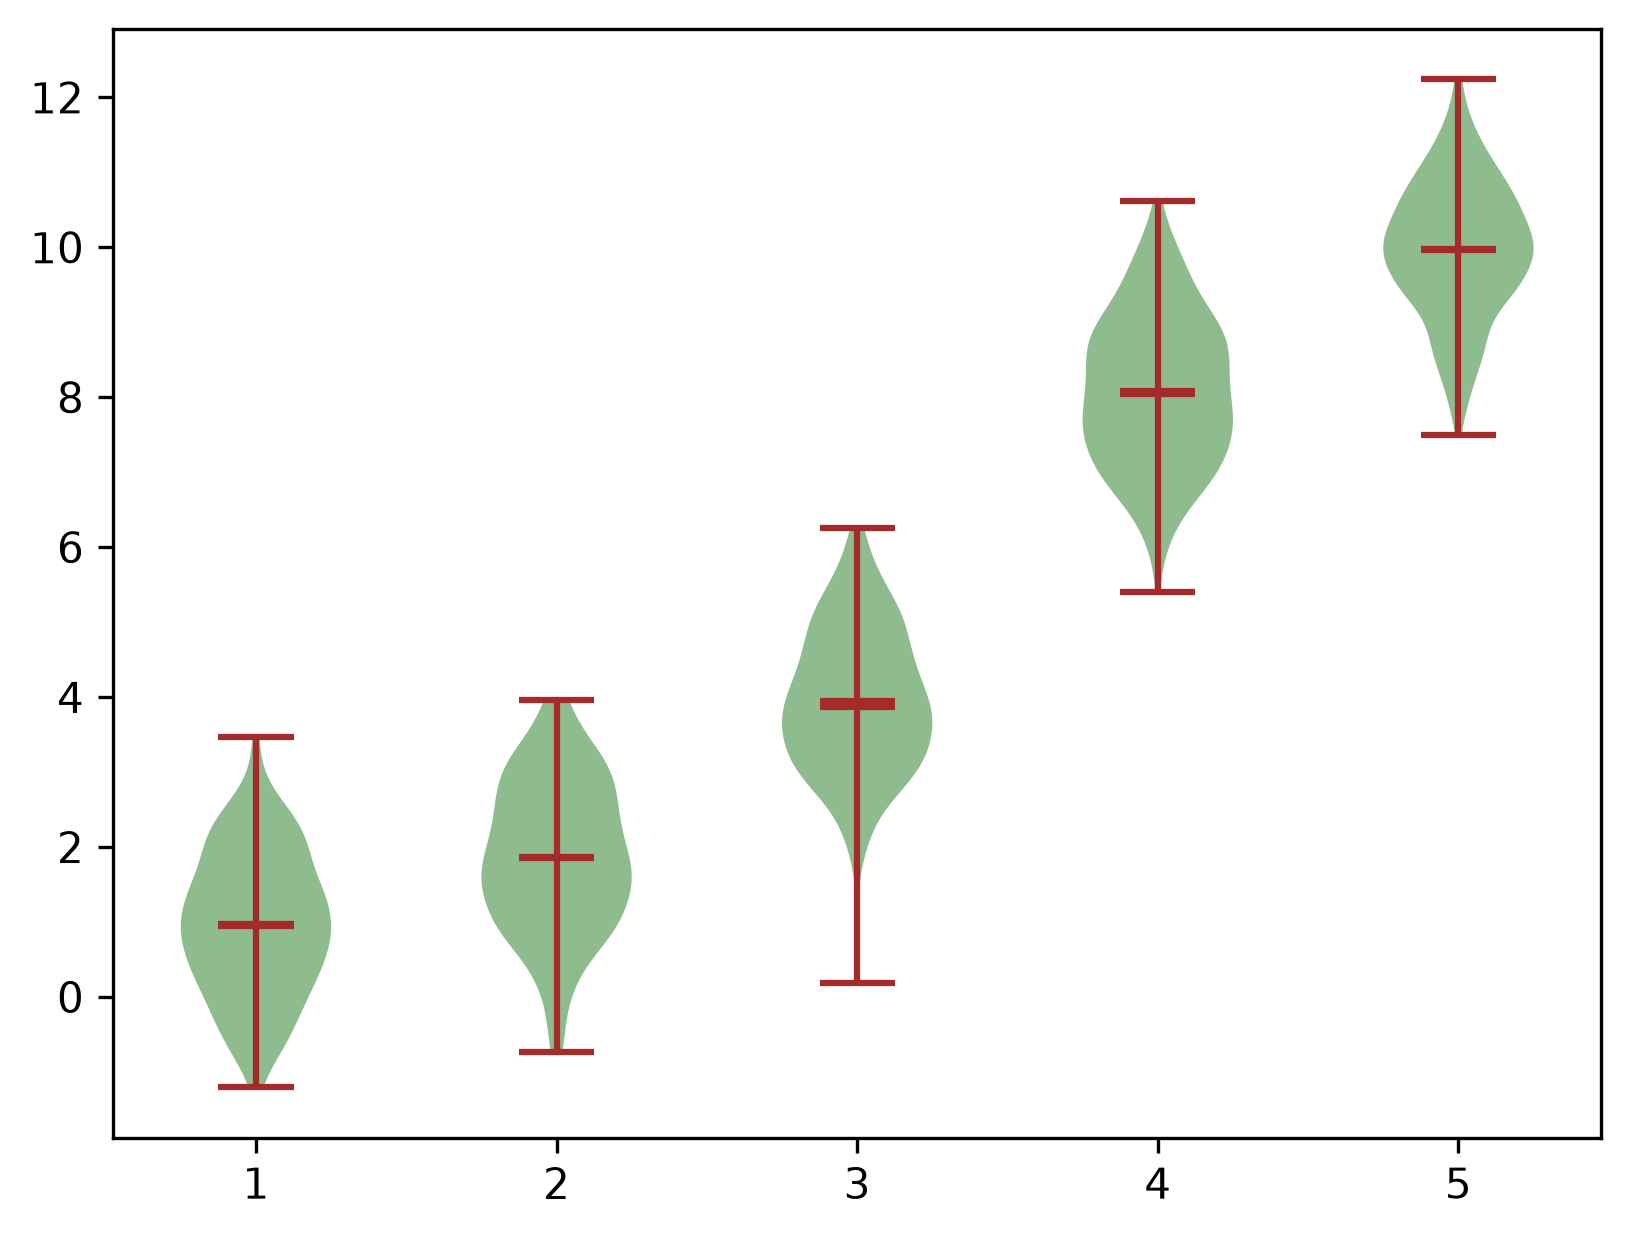

In [1240]:
vp = plt.violinplot(
    x,
    orientation='vertical',
    widths=0.5,
    showmeans=True,
    showmedians=True,
    showextrema=True,
    side='both',
    facecolor='darkseagreen',
    linecolor='brown'
);

A lot more customization can be implemented by accessing the objects returned by `violinplot()`

In [1228]:
vp

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x15a19c190>,
 'cmeans': <matplotlib.collections.LineCollection at 0x15a19c690>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x15a19c550>,
 'cmins': <matplotlib.collections.LineCollection at 0x15a19c410>,
 'cbars': <matplotlib.collections.LineCollection at 0x15a19ca50>,
 'cmedians': <matplotlib.collections.LineCollection at 0x15a19d090>}

Let's make them look like trees

(-3.5, 14.0)

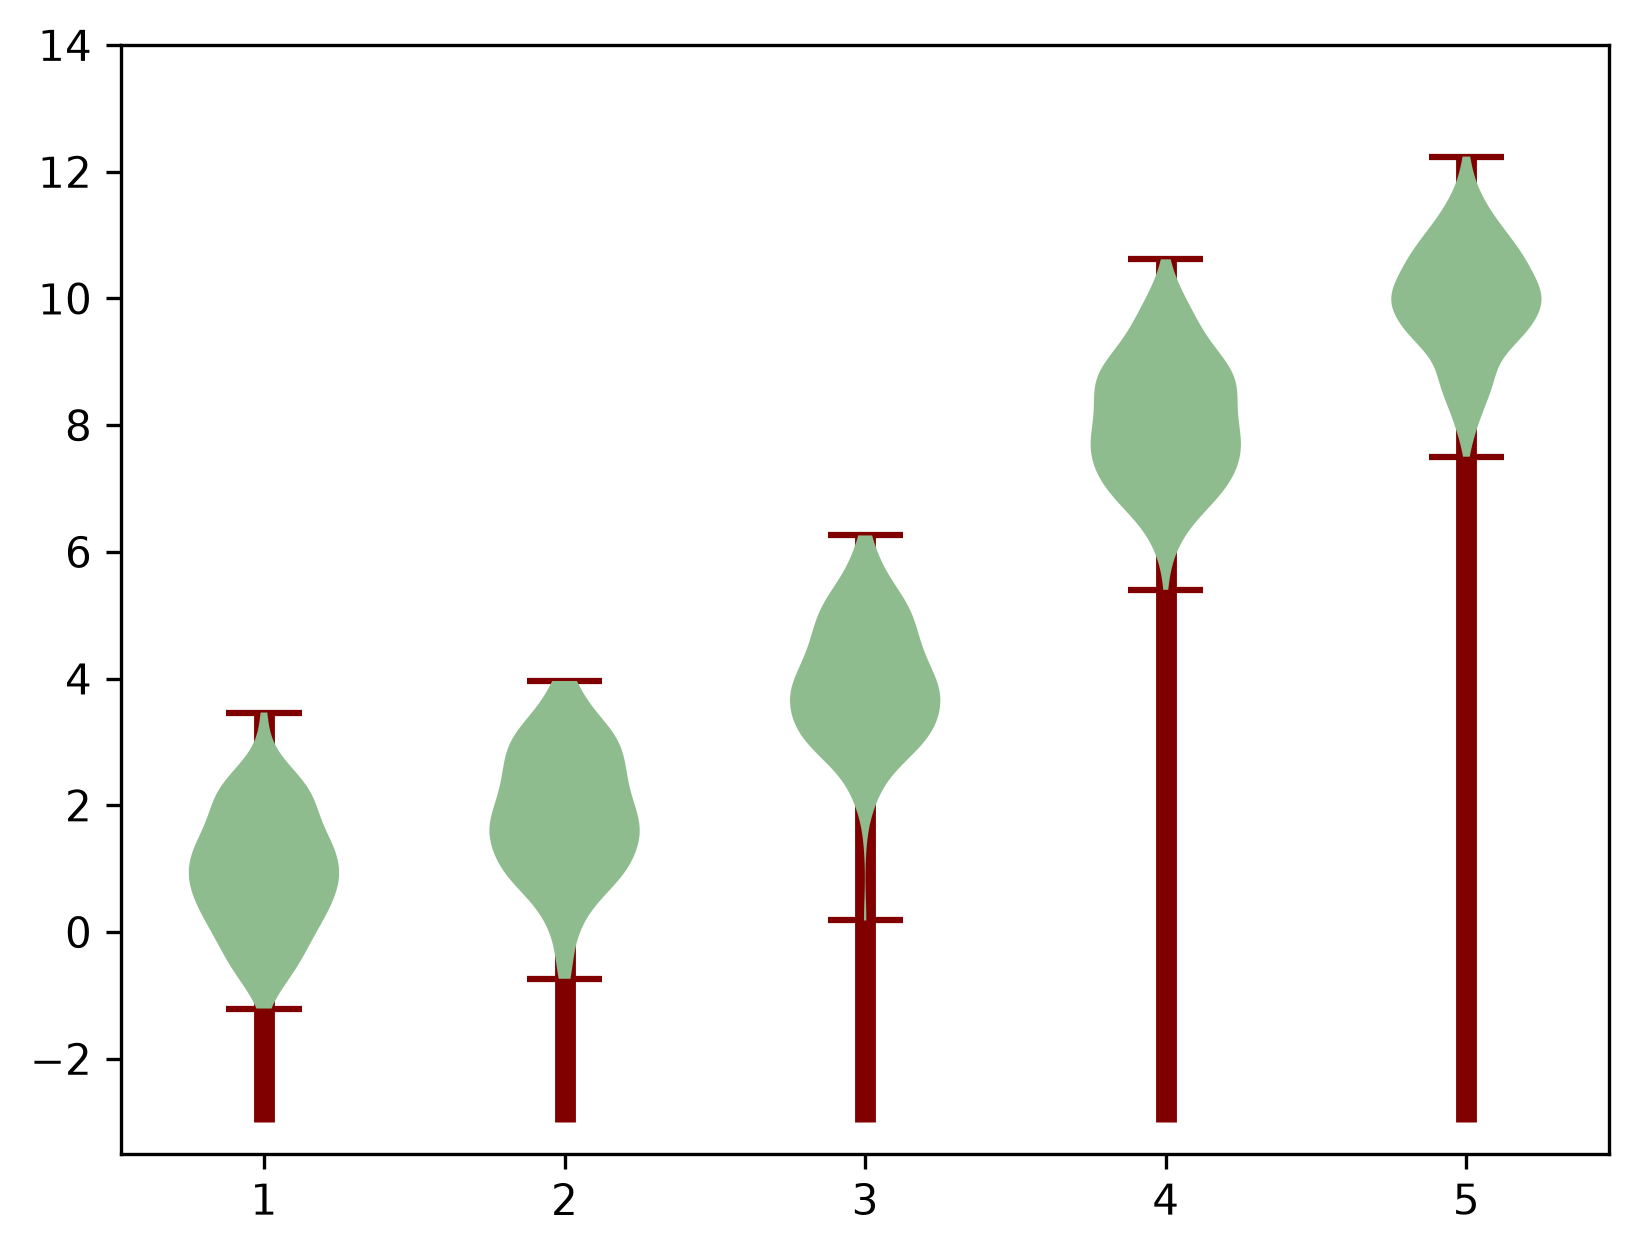

In [1267]:
vp = plt.violinplot(
    x,
    orientation='vertical',
    widths=0.5,
    showmeans=False,
    showmedians=True,
    showextrema=True,
    side='both',
    facecolor='darkseagreen',
    linecolor='maroon'
);

# make the bars wider with lw (linewidth)
vp['cbars'].set_lw(5)

# bring the violin bodies to the front with zorder
for bod in vp['bodies']:
    bod.set_zorder(3)

# bring the bars down to -3 so they look like trunks
segments = vp['cbars'].get_segments()
for bar_seg in segments:
    bar_seg[0,1]=-3
vp['cbars'].set_segments(segments)

plt.ylim(-3.5,14)

Seaborn has some pretty cool violin plots too! You can learn more about them [here, in the docs](https://seaborn.pydata.org/generated/seaborn.violinplot.html).